In [ ]:
!pip install lxml -q

import xml.etree.ElementTree as ET
import pandas as pd
import re
import os
from google.colab import files

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os

print(os.path.exists('/content/drive/MyDrive/cse499B'))

True


In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
test_path = '/content/drive/MyDrive/cse499B/write_test.txt'
with open(test_path, 'w') as f:
    f.write('test')
print("Write succeeded")

Write succeeded


In [ ]:
import os
for root, dirs, files_ in os.walk('/content/drive/MyDrive'):
    for f in files_:
        if 'drug' in f.lower() or f.endswith('.csv') or f.endswith('.xml') or f.endswith('.npy'):
            print(os.path.join(root, f))

/content/drive/MyDrive/Colab Notebooks/MediLens_DrugBank_XML_to_CSV.ipynb
/content/drive/MyDrive/Colab Notebooks/MediLens_DrugBank_XML_to_CSV_FIXED.ipynb
/content/drive/MyDrive/MediLens/drugbank.xml
/content/drive/MyDrive/MediLens/drug_interactions.csv
/content/drive/MyDrive/MediLens/drugbank_full.csv


In [ ]:
import os

target = '/content/drive/MyDrive/cse499B'
for root, dirs, files_ in os.walk(target):
    for f in files_:
        print(os.path.join(root, f))

/content/drive/MyDrive/cse499B/drugbank.xml
/content/drive/MyDrive/cse499B/merged_drug_interactions.csv
/content/drive/MyDrive/cse499B/merged_drug_interactions_cleaned.csv
/content/drive/MyDrive/cse499B/drugs_consolidated_clean.csv
/content/drive/MyDrive/cse499B/drug_interactions_edgelist.csv
/content/drive/MyDrive/cse499B/embedding_id_map.csv
/content/drive/MyDrive/cse499B/baseline_embeddings.npy


In [3]:
import pandas as pd
import numpy as np

CSE499B_DIR = '/content/drive/MyDrive/cse499B'

# Load the cleaned drug dataframe (already filtered for usable text_blob)
drugs_df = pd.read_csv(f'{CSE499B_DIR}/drugs_consolidated_clean.csv')
drugs_df = drugs_df.dropna(subset=['text_blob']).reset_index(drop=True)
print(f"Loaded drugs_df: {drugs_df.shape}")

# Load the existing baseline embeddings + id map (for later comparison — not needed for MLM training itself)
baseline_embeddings = np.load(f'{CSE499B_DIR}/baseline_embeddings.npy')
embedding_id_map = pd.read_csv(f'{CSE499B_DIR}/embedding_id_map.csv')
print(f"Loaded baseline_embeddings: {baseline_embeddings.shape}")
print(f"Loaded embedding_id_map: {embedding_id_map.shape}")

Loaded drugs_df: (12742, 13)
Loaded baseline_embeddings: (12742, 768)
Loaded embedding_id_map: (12742, 3)


In [ ]:
!pip install transformers torch -q

import torch
from transformers import AutoTokenizer, AutoModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

MODEL_NAME = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.to(device)
model.eval()

Using device: cuda


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  440MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
import transformers
print(transformers.__version__)

5.13.1


In [ ]:
from transformers import TrainingArguments
help(TrainingArguments.__init__)

Help on function __init__ in module transformers.training_args:

__init__(self, output_dir: str | None = None, per_device_train_batch_size: int = 8, num_train_epochs: float = 3.0, max_steps: int = -1, learning_rate: float = 5e-05, lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear', lr_scheduler_kwargs: dict | str | None = None, warmup_steps: float = 0, optim: transformers.training_args.OptimizerNames | str = 'adamw_torch_fused', optim_args: str | None = None, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, optim_target_modules: None | str | list[str] = None, gradient_accumulation_steps: int = 1, average_tokens_across_devices: bool = True, max_grad_norm: float = 1.0, label_smoothing_factor: float = 0.0, bf16: bool = False, fp16: bool = False, bf16_full_eval: bool = False, fp16_full_eval: bool = False, tf32: bool | None = None, gradient_checkpointing: bool = False, gradient_checkpointing_kwargs: dict[st

In [ ]:
# ==================================================
# FINE-TUNE PubMedBERT ON DRUGBANK TEXT via MLM -> ModiBERT
# ==================================================
!pip install datasets accelerate -q

from transformers import (
    AutoModelForMaskedLM,
    DataCollatorForLanguageModeling,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset

CSE499B_DIR = '/content/drive/MyDrive/cse499B'

# ---- 1. Build a HF Dataset from text_blob ----
mlm_texts = drugs_df['text_blob'].tolist()
raw_dataset = Dataset.from_dict({'text': mlm_texts})

split_dataset = raw_dataset.train_test_split(test_size=0.1, seed=42)
print(f"Train rows: {len(split_dataset['train'])}")
print(f"Eval rows:  {len(split_dataset['test'])}")

# ---- 2. Tokenize ----
MAX_LENGTH = 512

def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding='max_length',
    )

tokenized_dataset = split_dataset.map(
    tokenize_fn,
    batched=True,
    remove_columns=['text'],
)

# ---- 3. Load PubMedBERT WITH its MLM head ----
mlm_model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME)
mlm_model.to(device)

# ---- 4. Data collator handles random masking (15%) ----
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15,
)

# ---- 5. Training arguments ----
# save_total_limit=1 + save_only_model=True keeps Drive usage to
# roughly one ~440MB checkpoint + the final ~440MB save = under 1GB total,
# well inside your 4GB budget with room to spare.
training_args = TrainingArguments(
    output_dir=f'{CSE499B_DIR}/modibert_checkpoint',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.06,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=1,
    save_only_model=True,
    logging_steps=50,
    fp16=(device.type == 'cuda'),
    report_to='none',
)

trainer = Trainer(
    model=mlm_model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['test'],
    data_collator=data_collator,
)

# ---- 6. Train ----
train_result = trainer.train()
print(train_result)

# ---- 7. Save final ModiBERT to Drive ----
MODIBERT_DIR = f'{CSE499B_DIR}/modibert_final'
trainer.save_model(MODIBERT_DIR)
tokenizer.save_pretrained(MODIBERT_DIR)
print(f"ModiBERT saved to {MODIBERT_DIR}")

# ---- 8. Eval loss / perplexity for your report ----
import math
eval_metrics = trainer.evaluate()
print(f"Final eval loss: {eval_metrics['eval_loss']:.4f}")
print(f"Final eval perplexity: {math.exp(eval_metrics['eval_loss']):.2f}")

Train rows: 11467
Eval rows:  1275


Map:   0%|          | 0/11467 [00:00<?, ? examples/s]

Map:   0%|          | 0/1275 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

TrainOutput(global_step=2151, training_loss=1.894684846763664, metrics={'train_runtime': 1276.7842, 'train_samples_per_second': 26.943, 'train_steps_per_second': 1.685, 'total_flos': 9054508765132800.0, 'train_loss': 1.894684846763664, 'epoch': 3.0})


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

ModiBERT saved to /content/drive/MyDrive/cse499B/modibert_final


Training Loss,Validation Loss,Epoch
1.740972,0.850485,3


Final eval loss: 0.8505
Final eval perplexity: 2.34


In [ ]:
# ==================================================
# GENERATE MODIBERT EMBEDDINGS (token -> row representation)
# Same method as baseline (mean pooling), so the ONLY difference
# between baseline_embeddings.npy and this file is the model weights.
# ==================================================
import torch
import numpy as np
import pandas as pd
from transformers import AutoModel
from tqdm.auto import tqdm

MODIBERT_DIR = f'{CSE499B_DIR}/modibert_final'

# ---- 1. Load ModiBERT as a plain encoder (no MLM head needed anymore) ----
modibert = AutoModel.from_pretrained(MODIBERT_DIR)
modibert.to(device)
modibert.eval()
print("ModiBERT loaded as encoder from:", MODIBERT_DIR)

# ---- 2. Same mean-pooling function used for the PubMedBERT baseline ----
def mean_pool(token_embeddings, attention_mask):
    mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * mask_expanded, dim=1)
    sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
    return sum_embeddings / sum_mask

# ---- 3. Lock in row order explicitly BEFORE generating anything ----
BATCH_SIZE = 32
MAX_LENGTH = 512

ordered_ids = drugs_df['drugbank_id'].tolist()
ordered_names = drugs_df['name'].tolist()
texts = drugs_df['text_blob'].tolist()

assert len(ordered_ids) == len(texts), "Mismatch between IDs and texts before starting!"

# ---- 4. Generate embeddings ----
all_embeddings = []
truncated_count = 0

with torch.no_grad():
    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Generating ModiBERT embeddings"):
        batch_texts = texts[i:i + BATCH_SIZE]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors='pt'
        )

        for text in batch_texts:
            token_count = len(tokenizer.encode(text, truncation=False))
            if token_count > MAX_LENGTH:
                truncated_count += 1

        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type == 'cuda')):
            output = modibert(**encoded)

        batch_embeddings = mean_pool(output.last_hidden_state, encoded['attention_mask'])
        all_embeddings.append(batch_embeddings.cpu().float().numpy())

modibert_embeddings = np.vstack(all_embeddings)

# ---- 5. Sanity checks before saving anything ----
assert modibert_embeddings.shape[0] == len(ordered_ids), \
    f"Row count mismatch! Embeddings: {modibert_embeddings.shape[0]}, IDs: {len(ordered_ids)}"

print(f"\nFinal ModiBERT embedding matrix shape: {modibert_embeddings.shape}")
print(f"Entries truncated at {MAX_LENGTH} tokens: {truncated_count} "
      f"({truncated_count/len(texts)*100:.1f}%)")

# ---- 6. Save embeddings + id map, same pattern as baseline ----
np.save(f'{CSE499B_DIR}/modibert_embeddings.npy', modibert_embeddings)

modibert_id_map = pd.DataFrame({
    'row_index': range(len(ordered_ids)),
    'drugbank_id': ordered_ids,
    'name': ordered_names,
})
modibert_id_map.to_csv(f'{CSE499B_DIR}/modibert_embedding_id_map.csv', index=False)

print("\nSaved to Drive:")
print("  modibert_embeddings.npy          -- shape", modibert_embeddings.shape)
print("  modibert_embedding_id_map.csv    -- maps row_index to drugbank_id/name")

# ---- 7. Cross-check row order against the EXISTING baseline id map ----
# This matters for Day 3: baseline vs ModiBERT comparisons must line up
# on the SAME drug at the SAME row index, or the comparison is meaningless.
if embedding_id_map['drugbank_id'].tolist() == ordered_ids:
    print("\n✅ Row order MATCHES baseline embedding_id_map.csv "
          "-- safe to compare row-by-row in Day 3.")
else:
    print("\n⚠️ WARNING: Row order does NOT match baseline embedding_id_map.csv.")
    print("Join on 'drugbank_id' before comparing baseline vs ModiBERT embeddings.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: /content/drive/MyDrive/cse499B/modibert_final
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ModiBERT loaded as encoder from: /content/drive/MyDrive/cse499B/modibert_final


Generating ModiBERT embeddings:   0%|          | 0/399 [00:00<?, ?it/s]


Final ModiBERT embedding matrix shape: (12742, 768)
Entries truncated at 512 tokens: 1523 (12.0%)

Saved to Drive:
  modibert_embeddings.npy          -- shape (12742, 768)
  modibert_embedding_id_map.csv    -- maps row_index to drugbank_id/name

✅ Row order MATCHES baseline embedding_id_map.csv -- safe to compare row-by-row in Day 3.


In [ ]:
# ============================================================
# STEP 1 — DIAGNOSTIC: Does ModiBERT inherit anisotropy?
# ============================================================

import numpy as np
import pandas as pd
from numpy.linalg import norm

CSE499B_DIR = '/content/drive/MyDrive/cse499B'

# ------------------------------------------------------------
# 1. Load both embedding sets
# ------------------------------------------------------------

baseline_embeddings = np.load(
    f'{CSE499B_DIR}/baseline_embeddings.npy'
)

modibert_embeddings = np.load(
    f'{CSE499B_DIR}/modibert_embeddings.npy'
)

id_map = pd.read_csv(
    f'{CSE499B_DIR}/embedding_id_map.csv'
)

assert baseline_embeddings.shape == modibert_embeddings.shape
assert len(id_map) == baseline_embeddings.shape[0]

print("Embedding shape:", baseline_embeddings.shape)
print("ID-map rows:", len(id_map))


# ------------------------------------------------------------
# 2. Norm distribution
# ------------------------------------------------------------

def report_norm_stats(name, emb):
    norms = norm(emb, axis=1)

    print(f"\n{name}:")
    print(f"  Mean norm = {norms.mean():.4f}")
    print(f"  Std norm  = {norms.std():.4f}")
    print(f"  Min norm  = {norms.min():.4f}")
    print(f"  Max norm  = {norms.max():.4f}")

    return norms


baseline_norms = report_norm_stats(
    "Baseline PubMedBERT",
    baseline_embeddings
)

modibert_norms = report_norm_stats(
    "ModiBERT",
    modibert_embeddings
)


# ------------------------------------------------------------
# 3. Find drug rows safely
# ------------------------------------------------------------

def find_row(name_substring):
    matches = id_map[
        id_map['name'].str.contains(
            name_substring,
            case=False,
            na=False
        )
    ]

    if matches.empty:
        return None

    # Position in the embedding matrix
    return matches.index[0]


# ------------------------------------------------------------
# 4. Cosine similarity
# ------------------------------------------------------------

def pair_cosine(emb, idx_a, idx_b):
    a = emb[idx_a]
    b = emb[idx_b]

    return float(
        a @ b /
        (norm(a) * norm(b) + 1e-9)
    )


# ------------------------------------------------------------
# 5. Known related / unrelated diagnostic pairs
# ------------------------------------------------------------

related_pairs = [
    ("Metformin", "Pioglitazone"),
    ("Aspirin", "Ibuprofen"),
]

unrelated_pairs = [
    ("Metformin", "Amoxicillin"),
    ("Aspirin", "Sertraline"),
]


def run_pair_checks(emb, label):

    print(f"\n========== {label} ==========")

    for a_name, b_name in related_pairs:
        ia = find_row(a_name)
        ib = find_row(b_name)

        if ia is None or ib is None:
            print(f"[SKIP] {a_name} / {b_name}")
            continue

        sim = pair_cosine(emb, ia, ib)

        print(
            f"{a_name:15s} vs "
            f"{b_name:15s} "
            f"(RELATED):   {sim:.4f}"
        )

    for a_name, b_name in unrelated_pairs:
        ia = find_row(a_name)
        ib = find_row(b_name)

        if ia is None or ib is None:
            print(f"[SKIP] {a_name} / {b_name}")
            continue

        sim = pair_cosine(emb, ia, ib)

        print(
            f"{a_name:15s} vs "
            f"{b_name:15s} "
            f"(UNRELATED): {sim:.4f}"
        )


run_pair_checks(
    baseline_embeddings,
    "Baseline PubMedBERT"
)

run_pair_checks(
    modibert_embeddings,
    "ModiBERT"
)


# ------------------------------------------------------------
# 6. Dataset-wide random-pair cosine distribution
# ------------------------------------------------------------

rng = np.random.default_rng(42)

n_samples = 5000
n_drugs = len(id_map)

idx_a = rng.integers(0, n_drugs, n_samples)
idx_b = rng.integers(0, n_drugs, n_samples)

# Prevent self-pairs
same = idx_a == idx_b

while np.any(same):
    idx_b[same] = rng.integers(
        0,
        n_drugs,
        np.sum(same)
    )
    same = idx_a == idx_b


def sampled_sim_distribution(emb, label):

    a_vecs = emb[idx_a]
    b_vecs = emb[idx_b]

    sims = np.sum(
        a_vecs * b_vecs,
        axis=1
    ) / (
        norm(a_vecs, axis=1) *
        norm(b_vecs, axis=1) +
        1e-9
    )

    print(f"\n{label} random-pair cosine similarity:")
    print(f"  Mean = {sims.mean():.4f}")
    print(f"  Std  = {sims.std():.4f}")
    print(f"  Min  = {sims.min():.4f}")
    print(f"  Max  = {sims.max():.4f}")

    return sims


baseline_sims = sampled_sim_distribution(
    baseline_embeddings,
    "Baseline PubMedBERT"
)

modibert_sims = sampled_sim_distribution(
    modibert_embeddings,
    "ModiBERT"
)


# ------------------------------------------------------------
# 7. Simple diagnostic interpretation
# ------------------------------------------------------------

print("\n================ INTERPRETATION ================")

print("""
Do NOT decide on whitening/normalization yet.

First compare:

1. Baseline vs ModiBERT norm distributions
2. Related vs unrelated pair similarities
3. Random-pair similarity distributions

If ModiBERT still has very high random-pair cosine
similarities with very small spread, raw cosine similarity
is likely unsuitable for the similarity graph.

If ModiBERT produces substantially better separation,
we may be able to proceed without additional correction.

The result of THIS CELL determines the next step.
""")

Embedding shape: (12742, 768)
ID-map rows: 12742

Baseline PubMedBERT:
  Mean norm = 13.7929
  Std norm  = 0.1495
  Min norm  = 13.2530
  Max norm  = 14.2873

ModiBERT:
  Mean norm = 13.6914
  Std norm  = 0.1372
  Min norm  = 13.1869
  Max norm  = 14.2770

========== Baseline PubMedBERT ==========
Metformin       vs Pioglitazone    (RELATED):   0.9976
Aspirin         vs Ibuprofen       (RELATED):   0.9723
Metformin       vs Amoxicillin     (UNRELATED): 0.9946
Aspirin         vs Sertraline      (UNRELATED): 0.9691

========== ModiBERT ==========
Metformin       vs Pioglitazone    (RELATED):   0.9982
Aspirin         vs Ibuprofen       (RELATED):   0.9737
Metformin       vs Amoxicillin     (UNRELATED): 0.9955
Aspirin         vs Sertraline      (UNRELATED): 0.9704

Baseline PubMedBERT random-pair cosine similarity:
  Mean = 0.9766
  Std  = 0.0089
  Min  = 0.9096
  Max  = 1.0000

ModiBERT random-pair cosine similarity:
  Mean = 0.9763
  Std  = 0.0100
  Min  = 0.8837
  Max  = 1.0000

=======

In [ ]:
# ============================================================
# STEP 2 — EMBEDDING-SPACE CORRECTION EXPERIMENT
#
# No training.
# No labels.
# No interaction data used.
#
# Compare:
#   1. Raw ModiBERT
#   2. Mean-centered ModiBERT
#   3. Standardized ModiBERT
#   4. Whitened ModiBERT
#
# We do NOT choose the final representation until we inspect
# the similarity diagnostics.
# ============================================================

import numpy as np
from numpy.linalg import norm

# ------------------------------------------------------------
# 1. Correction functions
# ------------------------------------------------------------

def mean_center(emb):
    mu = emb.mean(axis=0, keepdims=True)
    return emb - mu


def standardize(emb):
    mu = emb.mean(axis=0, keepdims=True)
    sigma = emb.std(axis=0, keepdims=True)

    sigma = np.where(
        sigma < 1e-8,
        1.0,
        sigma
    )

    return (emb - mu) / sigma


def whiten(emb, eps=1e-5):
    """
    PCA/ZCA-style whitening.
    No model training and no labels.
    """

    mu = emb.mean(axis=0, keepdims=True)
    centered = emb - mu

    cov = np.cov(
        centered,
        rowvar=False
    )

    U, S, _ = np.linalg.svd(cov)

    W = (
        U
        @ np.diag(1.0 / np.sqrt(S + eps))
        @ U.T
    )

    whitened = centered @ W

    return whitened


# ------------------------------------------------------------
# 2. Generate all candidate representations
# ------------------------------------------------------------

modibert_raw = modibert_embeddings

modibert_centered = mean_center(
    modibert_embeddings
)

modibert_standardized = standardize(
    modibert_embeddings
)

modibert_whitened = whiten(
    modibert_embeddings
)


representations = {
    "Raw": modibert_raw,
    "Mean-centered": modibert_centered,
    "Standardized": modibert_standardized,
    "Whitened": modibert_whitened
}


# ------------------------------------------------------------
# 3. Norm statistics
# ------------------------------------------------------------

print("=" * 65)
print("NORM DISTRIBUTION")
print("=" * 65)

for name, emb in representations.items():

    norms = norm(
        emb,
        axis=1
    )

    print(
        f"{name:18s} | "
        f"mean={norms.mean():.4f} | "
        f"std={norms.std():.4f} | "
        f"min={norms.min():.4f} | "
        f"max={norms.max():.4f}"
    )


# ------------------------------------------------------------
# 4. Known-pair diagnostic
# ------------------------------------------------------------

def pair_cosine(emb, drug_a, drug_b):

    ia = find_row(drug_a)
    ib = find_row(drug_b)

    if ia is None or ib is None:
        return None

    a = emb[ia]
    b = emb[ib]

    return float(
        a @ b /
        (norm(a) * norm(b) + 1e-9)
    )


pairs = [
    ("Metformin", "Pioglitazone", "RELATED"),
    ("Aspirin", "Ibuprofen", "RELATED"),
    ("Metformin", "Amoxicillin", "UNRELATED"),
    ("Aspirin", "Sertraline", "UNRELATED"),
]


print("\n" + "=" * 65)
print("KNOWN-PAIR COSINE SIMILARITY")
print("=" * 65)

for representation_name, emb in representations.items():

    print(f"\n--- {representation_name} ---")

    for drug_a, drug_b, relationship in pairs:

        similarity = pair_cosine(
            emb,
            drug_a,
            drug_b
        )

        if similarity is None:
            print(
                f"{drug_a} vs {drug_b}: SKIPPED"
            )
            continue

        print(
            f"{drug_a:15s} vs "
            f"{drug_b:15s} "
            f"({relationship:9s}) "
            f"{similarity:.4f}"
        )


# ------------------------------------------------------------
# 5. Random-pair cosine distribution
# ------------------------------------------------------------

rng = np.random.default_rng(42)

n_samples = 5000
n_drugs = len(id_map)

idx_a = rng.integers(
    0,
    n_drugs,
    n_samples
)

idx_b = rng.integers(
    0,
    n_drugs,
    n_samples
)

# Prevent self-pairs
same = idx_a == idx_b

while np.any(same):

    idx_b[same] = rng.integers(
        0,
        n_drugs,
        np.sum(same)
    )

    same = idx_a == idx_b


def random_similarity_stats(emb):

    a = emb[idx_a]
    b = emb[idx_b]

    similarities = np.sum(
        a * b,
        axis=1
    ) / (
        norm(a, axis=1)
        * norm(b, axis=1)
        + 1e-9
    )

    return {
        "mean": similarities.mean(),
        "std": similarities.std(),
        "min": similarities.min(),
        "max": similarities.max()
    }


print("\n" + "=" * 65)
print("RANDOM-PAIR COSINE DISTRIBUTION")
print("=" * 65)

random_stats = {}

for name, emb in representations.items():

    stats = random_similarity_stats(
        emb
    )

    random_stats[name] = stats

    print(
        f"{name:18s} | "
        f"mean={stats['mean']:.4f} | "
        f"std={stats['std']:.4f} | "
        f"min={stats['min']:.4f} | "
        f"max={stats['max']:.4f}"
    )


# ------------------------------------------------------------
# 6. Save candidate representations
# ------------------------------------------------------------

np.save(
    f'{CSE499B_DIR}/modibert_embeddings_centered.npy',
    modibert_centered
)

np.save(
    f'{CSE499B_DIR}/modibert_embeddings_standardized.npy',
    modibert_standardized
)

np.save(
    f'{CSE499B_DIR}/modibert_embeddings_whitened.npy',
    modibert_whitened
)

print("\nSaved three candidate corrected representations:")
print("  modibert_embeddings_centered.npy")
print("  modibert_embeddings_standardized.npy")
print("  modibert_embeddings_whitened.npy")

NORM DISTRIBUTION
Raw                | mean=13.6914 | std=0.1372 | min=13.1869 | max=14.2770
Mean-centered      | mean=2.0800 | std=0.4488 | min=1.1311 | max=5.7209
Standardized       | mean=27.0448 | std=6.0480 | min=15.3501 | max=69.9953
Whitened           | mean=25.8126 | std=8.4560 | min=7.3439 | max=91.9951

KNOWN-PAIR COSINE SIMILARITY

--- Raw ---
Metformin       vs Pioglitazone    (RELATED  ) 0.9982
Aspirin         vs Ibuprofen       (RELATED  ) 0.9737
Metformin       vs Amoxicillin     (UNRELATED) 0.9955
Aspirin         vs Sertraline      (UNRELATED) 0.9704

--- Mean-centered ---
Metformin       vs Pioglitazone    (RELATED  ) 0.9034
Aspirin         vs Ibuprofen       (RELATED  ) -0.3203
Metformin       vs Amoxicillin     (UNRELATED) 0.7491
Aspirin         vs Sertraline      (UNRELATED) -0.3567

--- Standardized ---
Metformin       vs Pioglitazone    (RELATED  ) 0.8658
Aspirin         vs Ibuprofen       (RELATED  ) -0.1572
Metformin       vs Amoxicillin     (UNRELATED) 0.6424
A

In [ ]:
XML_PATH = '/content/drive/MyDrive/cse499B/drugbank.xml'

In [ ]:
def get_namespace(xml_path):
    """Peek at the root element to extract the default namespace, e.g.
    '{http://www.drugbank.ca}'"""
    events = ET.iterparse(xml_path, events=['start'])
    _, root = next(events)
    if root.tag.startswith('{'):
        ns_uri = root.tag.split('}')[0].strip('{')
        return {'db': ns_uri}, f'{{{ns_uri}}}'
    return {}, ''

NS, NS_PREFIX = get_namespace(XML_PATH)
print(f"Detected namespace: {NS}")

Detected namespace: {'db': 'http://www.drugbank.ca'}


In [ ]:
def get_text(elem, tag, ns_prefix=NS_PREFIX):
    """Return stripped text of a child tag, or '' if missing/empty.
    Handles None safely -- DrugBank leaves many fields empty rather than
    omitting the tag, so we normalize both cases to ''."""
    child = elem.find(f'{ns_prefix}{tag}')
    if child is not None and child.text:
        return child.text.strip()
    return ''

def clean_text(text):
    """Collapse whitespace/newlines so text_blob fields are clean single strings.
    DrugBank's free-text fields (description, MOA, toxicity) often contain
    embedded newlines and irregular spacing copied from source references."""
    if not text:
        return ''
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def get_primary_id(drug_elem, ns_prefix=NS_PREFIX):
    """A <drug> can have multiple <drugbank-id> tags (primary + secondary/
    deprecated aliases). We want only the one marked primary="true"."""
    for id_elem in drug_elem.findall(f'{ns_prefix}drugbank-id'):
        if id_elem.get('primary') == 'true':
            return id_elem.text.strip()
    # fallback: first drugbank-id tag if none marked primary (rare edge case)
    first = drug_elem.find(f'{ns_prefix}drugbank-id')
    return first.text.strip() if first is not None else None

def extract_name_list(elem, container_tag, item_tag, name_tag, ns_prefix=NS_PREFIX):
    """Generic extractor for targets/enzymes/pathways-style nested lists.
    Structure is: <targets><target><name>X</name></target>...</targets>
    Returns a semicolon-joined string, e.g. 'CYP3A4;CYP2D6;ABCB1'"""
    container = elem.find(f'{ns_prefix}{container_tag}')
    if container is None:
        return ''
    names = []
    for item in container.findall(f'{ns_prefix}{item_tag}'):
        name = get_text(item, name_tag, ns_prefix)
        if name:
            names.append(name)
    return ';'.join(names)

def get_smiles(elem, ns_prefix=NS_PREFIX):
    """SMILES lives inside calculated-properties as a <property> with
    <kind>SMILES</kind> -- it's not a direct child tag like the others."""
    calc_props = elem.find(f'{ns_prefix}calculated-properties')
    if calc_props is None:
        return ''
    for prop in calc_props.findall(f'{ns_prefix}property'):
        kind = get_text(prop, 'kind', ns_prefix)
        if kind == 'SMILES':
            return get_text(prop, 'value', ns_prefix)
    return ''


In [ ]:
drug_rows = []
interaction_rows = []

DRUG_TAG = f'{NS_PREFIX}drug'
context = ET.iterparse(XML_PATH, events=('start', 'end'))
count = 0
drug_depth = 0

for event, elem in context:
    if elem.tag != DRUG_TAG:
        continue

    if event == 'start':
        drug_depth += 1
        continue

    # event == 'end' from here on
    if drug_depth != 1:
        # This is a nested stub drug (e.g. from a pathway's drug list) closing.
        # Not a real top-level record -- skip processing, just track depth.
        drug_depth -= 1
        continue

    drugbank_id = get_primary_id(elem)
    if not drugbank_id:
        elem.clear()
        drug_depth -= 1
        continue

    name = get_text(elem, 'name')
    description = clean_text(get_text(elem, 'description'))
    indication = clean_text(get_text(elem, 'indication'))
    pharmacodynamics = clean_text(get_text(elem, 'pharmacodynamics'))
    mechanism_of_action = clean_text(get_text(elem, 'mechanism-of-action'))
    toxicity = clean_text(get_text(elem, 'toxicity'))
    drug_type = elem.get('type', '')  # e.g. 'small molecule' / 'biotech'

    targets = extract_name_list(elem, 'targets', 'target', 'name')
    enzymes = extract_name_list(elem, 'enzymes', 'enzyme', 'name')
    pathways = extract_name_list(elem, 'pathways', 'pathway', 'name')
    smiles = get_smiles(elem)
    text_parts = [p for p in [description, indication, pharmacodynamics,
                               mechanism_of_action, toxicity] if p]
    text_blob = ' '.join(text_parts)

    drug_rows.append({
        'drugbank_id': drugbank_id,
        'name': name,
        'drug_type': drug_type,
        'description': description,
        'indication': indication,
        'pharmacodynamics': pharmacodynamics,
        'mechanism_of_action': mechanism_of_action,
        'toxicity': toxicity,
        'targets': targets,
        'enzymes': enzymes,
        'pathways': pathways,
        'smiles': smiles,
        'text_blob': text_blob,
    })
     # --- Drug interactions go into a separate edge-list table ---
    interactions_container = elem.find(f'{NS_PREFIX}drug-interactions')
    if interactions_container is not None:
        for interaction in interactions_container.findall(f'{NS_PREFIX}drug-interaction'):
            other_id = get_text(interaction, 'drugbank-id')
            other_name = get_text(interaction, 'name')
            interaction_desc = clean_text(get_text(interaction, 'description'))
            if other_id:
                interaction_rows.append({
                    'drug_1': drugbank_id,
                    'drug_1_name': name,
                    'drug_2': other_id,
                    'drug_2_name': other_name,
                    'description': interaction_desc,
                })

    count += 1
    if count % 2000 == 0:
        print(f"Parsed {count} drugs...")

    # CRITICAL: clear the element after processing to free memory.
    # Without this, iterparse still accumulates the whole tree internally.
    elem.clear()
    drug_depth -= 1

print(f"\nDone. Parsed {count} total drug records.")

Parsed 2000 drugs...
Parsed 4000 drugs...
Parsed 6000 drugs...
Parsed 8000 drugs...
Parsed 10000 drugs...
Parsed 12000 drugs...
Parsed 14000 drugs...
Parsed 16000 drugs...
Parsed 18000 drugs...

Done. Parsed 19830 total drug records.


In [ ]:
drugs_df = pd.DataFrame(drug_rows)
interactions_df = pd.DataFrame(interaction_rows)

print(f"drugs_df shape: {drugs_df.shape}")
print(f"interactions_df shape: {interactions_df.shape}")

drugs_df shape: (19830, 13)
interactions_df shape: (2910010, 5)


In [ ]:
print("Field completeness (% non-empty):\n")
for col in ['description', 'indication', 'pharmacodynamics',
            'mechanism_of_action', 'toxicity', 'targets', 'enzymes',
            'pathways', 'smiles']:
    pct = (drugs_df[col].astype(str).str.len() > 0).mean() * 100
    print(f"  {col:22s}: {pct:5.1f}%")

empty_blob = (drugs_df['text_blob'].str.len() == 0).sum()
print(f"\nDrugs with completely empty text_blob: {empty_blob} "
      f"({empty_blob / len(drugs_df) * 100:.1f}%)")
print(f"Unique drugs appearing in interaction pairs: "
      f"{pd.concat([interactions_df['drug_1'], interactions_df['drug_2']]).nunique()}")

Field completeness (% non-empty):

  description           :  62.7%
  indication            :  22.6%
  pharmacodynamics      :  16.4%
  mechanism_of_action   :  21.4%
  toxicity              :  13.1%
  targets               :  50.4%
  enzymes               :   9.4%
  pathways              :   3.3%
  smiles                :  73.7%

Drugs with completely empty text_blob: 7088 (35.7%)
Unique drugs appearing in interaction pairs: 4629


In [ ]:
before = len(interactions_df)
interactions_df['pair_key'] = interactions_df.apply(
    lambda r: tuple(sorted([r['drug_1'], r['drug_2']])), axis=1
)
interactions_df_dedup = interactions_df.drop_duplicates(subset='pair_key').drop(columns='pair_key')
print(f"Interaction rows: {before} raw -> {len(interactions_df_dedup)} after "
      f"deduplicating symmetric pairs")

# Drop drugs with no usable text at all -- they can't contribute to
# text-based embeddings and would just be noise later.
drugs_df_clean = drugs_df[drugs_df['text_blob'].str.len() > 0].reset_index(drop=True)
print(f"Drugs retained after removing empty-text_blob rows: "
      f"{len(drugs_df_clean)} / {len(drugs_df)}")

Interaction rows: 2910010 raw -> 1455276 after deduplicating symmetric pairs
Drugs retained after removing empty-text_blob rows: 12742 / 19830


In [ ]:
drugs_df.to_csv('drugs_consolidated.csv', index=False)
drugs_df_clean.to_csv('drugs_consolidated_clean.csv', index=False)
interactions_df_dedup.to_csv('drug_interactions_edgelist.csv', index=False)

print("\nSaved:")
print("  drugs_consolidated.csv        (all drugs, including empty-text rows)")
print("  drugs_consolidated_clean.csv  (only drugs with usable text_blob)")
print("  drug_interactions_edgelist.csv (deduplicated pairs, ready for Day 3)")



Saved:
  drugs_consolidated.csv        (all drugs, including empty-text rows)
  drugs_consolidated_clean.csv  (only drugs with usable text_blob)
  drug_interactions_edgelist.csv (deduplicated pairs, ready for Day 3)


In [ ]:
print(drugs_df_clean[['drugbank_id', 'name', 'targets', 'enzymes']].head(10))
print()
print(interactions_df_dedup.head(10))

  drugbank_id                   name  \
0     DB00001              Lepirudin   
1     DB00002              Cetuximab   
2     DB00003           Dornase alfa   
3     DB00004    Denileukin diftitox   
4     DB00005             Etanercept   
5     DB00006            Bivalirudin   
6     DB00007             Leuprolide   
7     DB00008  Peginterferon alfa-2a   
8     DB00009              Alteplase   
9     DB00010             Sermorelin   

                                             targets              enzymes  
0                                        Prothrombin                       
1  Epidermal growth factor receptor;Low affinity ...                       
2                                Deoxyribonuclease-1                       
3  Interleukin-2 receptor subunit alpha;Interleuk...                       
4  Tumor necrosis factor;Lymphotoxin-alpha;High a...                       
5                                        Prothrombin      Myeloperoxidase  
6  Gonadotropin-releasing h

In [ ]:

interacting_drugs = set(interactions_df_dedup['drug_1']) | set(interactions_df_dedup['drug_2'])
text_drugs = set(drugs_df_clean['drugbank_id'])

overlap = interacting_drugs & text_drugs
print(f"Drugs with interaction data: {len(interacting_drugs)}")
print(f"Drugs with usable text: {len(text_drugs)}")
print(f"Overlap (usable for Day 3 fine-tuning pairs): {len(overlap)}")
print(f"Interaction pairs where BOTH drugs have text: "
      f"{interactions_df_dedup.apply(lambda r: r['drug_1'] in text_drugs and r['drug_2'] in text_drugs, axis=1).sum()} "
      f"/ {len(interactions_df_dedup)}")

Drugs with interaction data: 4629
Drugs with usable text: 12742
Overlap (usable for Day 3 fine-tuning pairs): 4048
Interaction pairs where BOTH drugs have text: 1225109 / 1455276


In [ ]:
!pip install transformers torch -q

import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type != 'cuda':
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > T4 GPU, "
          "then re-run this cell. CPU will work but will be much slower over ~12k drugs.")

Using device: cuda


In [ ]:
from google.colab import files
uploaded = files.upload()  # select drugs_consolidated_clean.csv

drugs_df = pd.read_csv('drugs_consolidated_clean.csv')
drugs_df = drugs_df.dropna(subset=['text_blob']).reset_index(drop=True)
print(f"Loaded {len(drugs_df)} drugs with usable text")

Saving drugs_consolidated_clean.csv to drugs_consolidated_clean.csv
Loaded 12742 drugs with usable text


In [ ]:
MODEL_NAME = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.to(device)
model.eval()  # inference mode -- no dropout, no gradient tracking needed

print(f"Loaded {MODEL_NAME}")
print(f"Hidden size: {model.config.hidden_size}")  # should print 768
print(f"Max position embeddings: {model.config.max_position_embeddings}")  # 512

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  440MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Hidden size: 768
Max position embeddings: 512


In [ ]:
def mean_pool(token_embeddings, attention_mask):
    """
    token_embeddings: (batch_size, seq_len, hidden_dim) -- last_hidden_state
    attention_mask:   (batch_size, seq_len) -- 1 for real tokens, 0 for padding
    """
    mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * mask_expanded, dim=1)
    sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)  # avoid div-by-zero
    return sum_embeddings / sum_mask

In [ ]:
BATCH_SIZE = 32
MAX_LENGTH = 512

texts = drugs_df['text_blob'].tolist()
all_embeddings = []
truncated_count = 0

with torch.no_grad():  # critical -- no gradients needed, saves memory/time
    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Generating embeddings"):
        batch_texts = texts[i:i + BATCH_SIZE]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors='pt'
        )

        # Track how many entries actually got truncated, for your limitations note
        for text in batch_texts:
            token_count = len(tokenizer.encode(text, truncation=False))
            if token_count > MAX_LENGTH:
                truncated_count += 1

        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type == 'cuda')):
            output = model(**encoded)

        batch_embeddings = mean_pool(output.last_hidden_state, encoded['attention_mask'])
        all_embeddings.append(batch_embeddings.cpu().float().numpy())

baseline_embeddings = np.vstack(all_embeddings)

print(f"\nFinal embedding matrix shape: {baseline_embeddings.shape}")
print(f"Entries truncated at {MAX_LENGTH} tokens: {truncated_count} "
      f"({truncated_count / len(texts) * 100:.1f}%)")

Generating embeddings:   0%|          | 0/399 [00:00<?, ?it/s]


Final embedding matrix shape: (12742, 768)
Entries truncated at 512 tokens: 1523 (12.0%)


In [ ]:
from numpy.linalg import norm

def nearest_neighbors(drug_name_substring, top_k=5):
    matches = drugs_df[drugs_df['name'].str.contains(drug_name_substring, case=False, na=False)]
    if matches.empty:
        print(f"No drug found matching '{drug_name_substring}'")
        return
    idx = matches.index[0]
    query_name = drugs_df.loc[idx, 'name']
    query_vec = baseline_embeddings[idx]

    # cosine similarity against all drugs
    sims = baseline_embeddings @ query_vec / (norm(baseline_embeddings, axis=1) * norm(query_vec) + 1e-9)
    top_indices = np.argsort(-sims)[1:top_k + 1]  # skip index 0 = itself

    print(f"Nearest neighbors to '{query_name}':")
    for i in top_indices:
        print(f"  {drugs_df.loc[i, 'name']:30s}  similarity={sims[i]:.3f}")

# Try a couple of well-known drugs -- adjust to whatever's in your dataset
nearest_neighbors("Aspirin")
print()
nearest_neighbors("Metformin")

Nearest neighbors to 'Nitroaspirin':
  K-134                           similarity=0.993
  Cinepazide                      similarity=0.990
  Enecadin                        similarity=0.990
  Ralinepag                       similarity=0.989
  Iferanserin                     similarity=0.989

Nearest neighbors to 'Metformin':
  Pioglitazone                    similarity=0.998
  Empagliflozin                   similarity=0.997
  Tirzepatide                     similarity=0.997
  Liraglutide                     similarity=0.997
  Semaglutide                     similarity=0.997


In [ ]:
np.save('baseline_embeddings.npy', baseline_embeddings)

id_map = drugs_df[['drugbank_id', 'name']].copy()
id_map['row_index'] = range(len(id_map))
id_map = id_map[['row_index', 'drugbank_id', 'name']]
id_map.to_csv('embedding_id_map.csv', index=False)

print("Saved:")
print("  baseline_embeddings.npy   -- shape", baseline_embeddings.shape)
print("  embedding_id_map.csv      -- maps row_index to drugbank_id/name")

files.download('baseline_embeddings.npy')
files.download('embedding_id_map.csv')

Saved:
  baseline_embeddings.npy   -- shape (12742, 768)
  embedding_id_map.csv      -- maps row_index to drugbank_id/name


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(f"Embedding dimension: {baseline_embeddings.shape[1]}")
print(f"Mean embedding norm: {norm(baseline_embeddings, axis=1).mean():.3f}")
print(f"Std of embedding norm: {norm(baseline_embeddings, axis=1).std():.3f}")

Embedding dimension: 768
Mean embedding norm: 13.793
Std of embedding norm: 0.150


In [ ]:
# Quick anisotropy check: compare Metformin to something clearly UNRELATED
nearest_neighbors_check = drugs_df[drugs_df['name'].str.contains("Metformin", case=False, na=False)]
idx_a = nearest_neighbors_check.index[0]
random_unrelated = drugs_df[drugs_df['name'].str.contains("Amoxicillin", case=False, na=False)]
if not random_unrelated.empty:
    idx_b = random_unrelated.index[0]
    sim = baseline_embeddings[idx_a] @ baseline_embeddings[idx_b] / (
        norm(baseline_embeddings[idx_a]) * norm(baseline_embeddings[idx_b]))
    print(f"Metformin vs Amoxicillin (unrelated drugs) similarity: {sim:.3f}")
    # If this is also >0.90 despite being pharmacologically unrelated, that
    # confirms the anisotropy — the space needs the Day 3 contrastive push.

Metformin vs Amoxicillin (unrelated drugs) similarity: 0.995


In [ ]:
try:
    print(drugs_df.shape)
    print("drugs_df already in memory — you're good, skip to the MLM cell.")
except NameError:
    print("drugs_df not in memory — need to re-run setup cells.")

drugs_df not in memory — need to re-run setup cells.


In [4]:
# ============================================
# LOAD EXISTING MODIBERT EMBEDDINGS
# ============================================

modibert_embeddings = np.load(
    f'{CSE499B_DIR}/modibert_embeddings.npy'
)

modibert_id_map = pd.read_csv(
    f'{CSE499B_DIR}/modibert_embedding_id_map.csv'
)

print("ModiBERT embeddings:", modibert_embeddings.shape)
print("ModiBERT ID map:", modibert_id_map.shape)

ModiBERT embeddings: (12742, 768)
ModiBERT ID map: (12742, 3)


In [5]:
# ============================================
# VERIFY EMBEDDING ALIGNMENT
# ============================================

assert len(drugs_df) == len(baseline_embeddings)
assert len(drugs_df) == len(modibert_embeddings)

assert embedding_id_map['drugbank_id'].tolist() == \
       modibert_id_map['drugbank_id'].tolist()

print("✅ Drug count matches.")
print("✅ Embedding dimensions match.")
print("✅ Baseline and ModiBERT row ordering matches.")

✅ Drug count matches.
✅ Embedding dimensions match.
✅ Baseline and ModiBERT row ordering matches.


In [6]:
# ============================================================
# CSE499B — REPRESENTATION VALIDATION
# Step 1: Load previously tested corrected representations
# ============================================================

import os
import numpy as np
import pandas as pd

# Check which corrected representations already exist
correction_files = {
    "centered": f"{CSE499B_DIR}/modibert_embeddings_centered.npy",
    "standardized": f"{CSE499B_DIR}/modibert_embeddings_standardized.npy",
    "whitened": f"{CSE499B_DIR}/modibert_embeddings_whitened.npy"
}

for name, path in correction_files.items():
    print(f"{name}: {'FOUND' if os.path.exists(path) else 'NOT FOUND'}")

centered: FOUND
standardized: FOUND
whitened: FOUND


In [7]:
# ============================================================
# CSE499B — REPRESENTATION VALIDATION
# Step 2: Load corrected ModiBERT representations
# ============================================================

modibert_centered = np.load(
    f"{CSE499B_DIR}/modibert_embeddings_centered.npy"
)

modibert_standardized = np.load(
    f"{CSE499B_DIR}/modibert_embeddings_standardized.npy"
)

modibert_whitened = np.load(
    f"{CSE499B_DIR}/modibert_embeddings_whitened.npy"
)

print("Raw ModiBERT:       ", modibert_embeddings.shape)
print("Mean-centered:      ", modibert_centered.shape)
print("Standardized:       ", modibert_standardized.shape)
print("Whitened:           ", modibert_whitened.shape)

Raw ModiBERT:        (12742, 768)
Mean-centered:       (12742, 768)
Standardized:        (12742, 768)
Whitened:            (12742, 768)


In [8]:
# ============================================================
# CSE499B — REPRESENTATION VALIDATION
# Step 3: Inspect available DrugBank biological information
# ============================================================

print("Available columns:")
print(drugs_df.columns.tolist())

print("\nData types:")
print(drugs_df.dtypes)

print("\nSample records:")
display(drugs_df.head(3))

Available columns:
['drugbank_id', 'name', 'drug_type', 'description', 'indication', 'pharmacodynamics', 'mechanism_of_action', 'toxicity', 'targets', 'enzymes', 'pathways', 'smiles', 'text_blob']

Data types:
drugbank_id            object
name                   object
drug_type              object
description            object
indication             object
pharmacodynamics       object
mechanism_of_action    object
toxicity               object
targets                object
enzymes                object
pathways               object
smiles                 object
text_blob              object
dtype: object

Sample records:


,drugbank_id,name,drug_type,description,indication,pharmacodynamics,mechanism_of_action,toxicity,targets,enzymes,pathways,smiles,text_blob
0,DB00001,Lepirudin,biotech,Lepirudin is a recombinant hirudin formed by 6...,Lepirudin is indicated for anticoagulation in ...,Lepirudin is a recombinant hirudin that acts a...,Lepirudin is a direct thrombin inhibitor used ...,The acute toxicity of intravenous lepirudin wa...,Prothrombin,NaN,Lepirudin Action Pathway,NaN,Lepirudin is a recombinant hirudin formed by 6...
1,DB00002,Cetuximab,biotech,Cetuximab is a recombinant chimeric human/mous...,Cetuximab is indicated for: - The treatment of...,Cetuximab is an anticancer agent that works by...,The epidermal growth factor receptor (EGFR) is...,The intravenous LD<sub>50</sub> is > 300 mg/kg...,Epidermal growth factor receptor;Low affinity ...,NaN,Cetuximab Action Pathway,NaN,Cetuximab is a recombinant chimeric human/mous...
2,DB00003,Dornase alfa,biotech,Dornase alfa is a biosynthetic form of human d...,Used as adjunct therapy in the treatment of cy...,Cystic fibrosis (CF) is a disease characterize...,Dornase alfa is a biosynthetic form of human D...,Adverse reactions occur at a frequency of < 1/...,Deoxyribonuclease-1,NaN,NaN,NaN,Dornase alfa is a biosynthetic form of human d...


In [9]:
# ============================================================
# CSE499B — REPRESENTATION VALIDATION
# Step 4: Inspect biological relationship fields
# ============================================================

# Show a few drugs with target information
sample_bio = drugs_df[
    drugs_df['targets'].notna() &
    (drugs_df['targets'].astype(str).str.strip() != '')
][
    ['drugbank_id', 'name', 'targets', 'enzymes', 'pathways',
     'indication', 'mechanism_of_action']
].head(5)

display(sample_bio)

,drugbank_id,name,targets,enzymes,pathways,indication,mechanism_of_action
0,DB00001,Lepirudin,Prothrombin,NaN,Lepirudin Action Pathway,Lepirudin is indicated for anticoagulation in ...,Lepirudin is a direct thrombin inhibitor used ...
1,DB00002,Cetuximab,Epidermal growth factor receptor;Low affinity ...,NaN,Cetuximab Action Pathway,Cetuximab is indicated for: - The treatment of...,The epidermal growth factor receptor (EGFR) is...
2,DB00003,Dornase alfa,Deoxyribonuclease-1,NaN,NaN,Used as adjunct therapy in the treatment of cy...,Dornase alfa is a biosynthetic form of human D...
3,DB00004,Denileukin diftitox,Interleukin-2 receptor subunit alpha;Interleuk...,NaN,NaN,Denileukin diftitox was previously indicated f...,Denileukin diftitox is a fusion protein compos...
4,DB00005,Etanercept,Tumor necrosis factor;Lymphotoxin-alpha;High a...,NaN,NaN,Etanercept is indicated for the treatment of m...,There are two distinct receptors for TNF (TNFR...


In [10]:
# ============================================================
# CSE499B — REPRESENTATION VALIDATION
# Step 5: Analyze target-data coverage
# ============================================================

import re
from collections import Counter

def parse_targets(value):
    """Convert the DrugBank target field into a clean set of target names."""

    if pd.isna(value):
        return set()

    value = str(value).strip()

    if not value:
        return set()

    # Targets in this dataset are separated by semicolons
    targets = [
        t.strip()
        for t in value.split(';')
        if t.strip()
    ]

    return set(targets)


# Parse targets for every drug
target_sets = drugs_df['targets'].apply(parse_targets)

# Number of drugs with at least one target
num_with_targets = target_sets.apply(len).gt(0).sum()

# Number of drugs without target information
num_without_targets = len(drugs_df) - num_with_targets

# Number of targets per drug
target_counts = target_sets.apply(len)

print("Total drugs:", len(drugs_df))
print("Drugs with target information:", num_with_targets)
print("Drugs without target information:", num_without_targets)

print("\nTarget-count statistics:")
print(target_counts.describe())

# Count how frequently each target appears
target_frequency = Counter()

for targets in target_sets:
    target_frequency.update(targets)

print("\nNumber of unique targets:", len(target_frequency))

print("\nTop 20 most frequent targets:")
for target, count in target_frequency.most_common(20):
    print(f"{target}: {count}")

Total drugs: 12742
Drugs with target information: 5633
Drugs without target information: 7109

Target-count statistics:
count    12742.000000
mean         1.329305
std          5.156451
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        300.000000
Name: targets, dtype: float64

Number of unique targets: 3792

Top 20 most frequent targets:
D(2) dopamine receptor: 156
Histamine H1 receptor: 129
5-hydroxytryptamine receptor 2A: 128
5-hydroxytryptamine receptor 1A: 116
Prostaglandin G/H synthase 2: 111
Estrogen receptor: 109
Muscarinic acetylcholine receptor M1: 104
DNA: 97
Alpha-1A adrenergic receptor: 97
Prostaglandin G/H synthase 1: 92
Sodium-dependent noradrenaline transporter: 86
Mu-type opioid receptor: 86
Beta-2 adrenergic receptor: 84
Sodium-dependent serotonin transporter: 84
5-hydroxytryptamine receptor 2C: 84
Muscarinic acetylcholine receptor M2: 83
Androgen receptor: 83
Glucocorticoid receptor: 82
Muscarinic acetylcholine receptor

In [11]:
# ============================================================
# CSE499B — REPRESENTATION VALIDATION
# Step 6: Create 20 biologically grounded validation pairs
# ============================================================

import random
from collections import defaultdict

random.seed(42)

# ------------------------------------------------------------
# 1. Build target -> drug index mapping
# ------------------------------------------------------------

target_to_drugs = defaultdict(list)

for drug_idx, targets in enumerate(target_sets):
    for target in targets:
        target_to_drugs[target].append(drug_idx)


# ------------------------------------------------------------
# 2. Create candidate RELATED pairs
#    Each pair shares at least one target.
# ------------------------------------------------------------

related_candidates = []

for target, drug_indices in target_to_drugs.items():

    # Need at least two different drugs
    if len(drug_indices) < 2:
        continue

    # Randomly shuffle drugs for this target
    shuffled = drug_indices.copy()
    random.shuffle(shuffled)

    # Take a small number of pairs from each target.
    # This prevents one very common target from dominating
    # the whole validation set.
    max_pairs_from_target = min(
        3,
        len(shuffled) * (len(shuffled) - 1) // 2
    )

    pair_count = 0

    for i in range(len(shuffled)):
        for j in range(i + 1, len(shuffled)):

            idx_a = shuffled[i]
            idx_b = shuffled[j]

            shared_targets = (
                target_sets[idx_a]
                .intersection(target_sets[idx_b])
            )

            if shared_targets:
                related_candidates.append(
                    (idx_a, idx_b, shared_targets)
                )

                pair_count += 1

            if pair_count >= max_pairs_from_target:
                break

        if pair_count >= max_pairs_from_target:
            break


# Remove duplicate drug pairs
unique_related = {}

for idx_a, idx_b, shared_targets in related_candidates:

    pair_key = tuple(sorted((idx_a, idx_b)))

    if pair_key not in unique_related:
        unique_related[pair_key] = shared_targets


related_candidates = [
    (idx_a, idx_b, shared_targets)
    for (idx_a, idx_b), shared_targets
    in unique_related.items()
]

random.shuffle(related_candidates)

# Select 10 related pairs
related_pairs = related_candidates[:10]


# ------------------------------------------------------------
# 3. Create candidate TARGET-DISJOINT control pairs
# ------------------------------------------------------------

drugs_with_targets = [
    idx for idx, targets in enumerate(target_sets)
    if len(targets) > 0
]

control_candidates = []

# Generate random candidate pairs
for _ in range(50000):

    idx_a, idx_b = random.sample(drugs_with_targets, 2)

    # No shared target
    if target_sets[idx_a].isdisjoint(target_sets[idx_b]):

        control_candidates.append(
            (idx_a, idx_b, set())
        )

    if len(control_candidates) >= 1000:
        break


# ------------------------------------------------------------
# 4. Select 10 controls
# ------------------------------------------------------------

random.shuffle(control_candidates)

control_pairs = control_candidates[:10]


# ------------------------------------------------------------
# 5. Build readable validation table
# ------------------------------------------------------------

validation_rows = []

# Related pairs
for idx_a, idx_b, shared_targets in related_pairs:

    validation_rows.append({
        "type": "TARGET_RELATED",
        "drug_a": drugs_df.iloc[idx_a]["name"],
        "drug_b": drugs_df.iloc[idx_b]["name"],
        "drug_a_id": drugs_df.iloc[idx_a]["drugbank_id"],
        "drug_b_id": drugs_df.iloc[idx_b]["drugbank_id"],
        "shared_targets": "; ".join(sorted(shared_targets))
    })


# Control pairs
for idx_a, idx_b, shared_targets in control_pairs:

    validation_rows.append({
        "type": "TARGET_DISJOINT_CONTROL",
        "drug_a": drugs_df.iloc[idx_a]["name"],
        "drug_b": drugs_df.iloc[idx_b]["name"],
        "drug_a_id": drugs_df.iloc[idx_a]["drugbank_id"],
        "drug_b_id": drugs_df.iloc[idx_b]["drugbank_id"],
        "shared_targets": ""
    })


validation_df = pd.DataFrame(validation_rows)

print("Number of validation pairs:")
print(validation_df["type"].value_counts())

print("\nValidation pairs:")
display(validation_df)

Number of validation pairs:
type
TARGET_RELATED             10
TARGET_DISJOINT_CONTROL    10
Name: count, dtype: int64

Validation pairs:


,type,drug_a,drug_b,drug_a_id,drug_b_id,shared_targets
0,TARGET_RELATED,Staurosporine,Pazopanib,DB02010,DB06589,Tyrosine-protein kinase ITK/TSK
1,TARGET_RELATED,Glutamic acid,Proline,DB00142,DB00172,Bifunctional glutamate/proline--tRNA ligase
2,TARGET_RELATED,Guanosine-5'-Monophosphate,Guanosine,DB01972,DB02857,DNA polymerase catalytic subunit; DNA-directed...
3,TARGET_RELATED,Cyclosporine,Triglyme,DB00091,DB02078,"Peptidyl-prolyl cis-trans isomerase F, mitocho..."
4,TARGET_RELATED,Cabergoline,Clozapine,DB00248,DB00363,5-hydroxytryptamine receptor 1A; 5-hydroxytryp...
5,TARGET_RELATED,Peginterferon alfa-2b,Interferon beta-1b,DB00022,DB00068,Interferon alpha/beta receptor 1; Interferon a...
6,TARGET_RELATED,Dexfosfoserine,Fasudil,DB04522,DB08162,cAMP-dependent protein kinase catalytic subuni...
7,TARGET_RELATED,Flecainide,Tetracaine,DB01195,DB09085,Ryanodine receptor 2
8,TARGET_RELATED,Pyridoxal phosphate,Cysteine,DB00114,DB00151,"Aspartate aminotransferase, cytoplasmic; Aspar..."
9,TARGET_RELATED,Nicotine,TC-2216,DB00184,DB06044,Neuronal acetylcholine receptor subunit alpha-...


In [12]:
# ============================================================
# CSE499B — REPRESENTATION VALIDATION
# Step 7: Calculate cosine similarity for validation pairs
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# Create drugbank_id -> embedding row index mapping
# ------------------------------------------------------------

drug_to_row = dict(
    zip(
        embedding_id_map["drugbank_id"],
        embedding_id_map.index
    )
)

# ------------------------------------------------------------
# Store all four embedding representations
# ------------------------------------------------------------

representations = {
    "Raw_ModiBERT": modibert_embeddings,
    "Mean_Centered": modibert_centered,
    "Standardized": modibert_standardized,
    "Whitened": modibert_whitened
}

# ------------------------------------------------------------
# Calculate similarity for every validation pair
# ------------------------------------------------------------

results = []

for _, pair in validation_df.iterrows():

    drug_a_id = pair["drug_a_id"]
    drug_b_id = pair["drug_b_id"]

    idx_a = drug_to_row[drug_a_id]
    idx_b = drug_to_row[drug_b_id]

    result = {
        "type": pair["type"],
        "drug_a": pair["drug_a"],
        "drug_b": pair["drug_b"],
        "shared_targets": pair["shared_targets"]
    }

    # Calculate cosine similarity using each representation
    for representation_name, embeddings in representations.items():

        vector_a = embeddings[idx_a].reshape(1, -1)
        vector_b = embeddings[idx_b].reshape(1, -1)

        similarity = cosine_similarity(
            vector_a,
            vector_b
        )[0, 0]

        result[representation_name] = similarity

    results.append(result)


# ------------------------------------------------------------
# Create final similarity table
# ------------------------------------------------------------

similarity_df = pd.DataFrame(results)

# Display the results
display(similarity_df)

,type,drug_a,drug_b,shared_targets,Raw_ModiBERT,Mean_Centered,Standardized,Whitened
0,TARGET_RELATED,Staurosporine,Pazopanib,Tyrosine-protein kinase ITK/TSK,0.978650,-0.006358,0.066225,-0.028008
1,TARGET_RELATED,Glutamic acid,Proline,Bifunctional glutamate/proline--tRNA ligase,0.992637,0.642744,0.584287,0.102707
2,TARGET_RELATED,Guanosine-5'-Monophosphate,Guanosine,DNA polymerase catalytic subunit; DNA-directed...,0.986548,0.583070,0.585725,0.093681
3,TARGET_RELATED,Cyclosporine,Triglyme,"Peptidyl-prolyl cis-trans isomerase F, mitocho...",0.965825,-0.146918,-0.100816,-0.010982
4,TARGET_RELATED,Cabergoline,Clozapine,5-hydroxytryptamine receptor 1A; 5-hydroxytryp...,0.986722,0.693722,0.597129,0.091516
5,TARGET_RELATED,Peginterferon alfa-2b,Interferon beta-1b,Interferon alpha/beta receptor 1; Interferon a...,0.991325,0.492977,0.446507,0.113248
6,TARGET_RELATED,Dexfosfoserine,Fasudil,cAMP-dependent protein kinase catalytic subuni...,0.961720,0.223420,0.060378,0.017059
7,TARGET_RELATED,Flecainide,Tetracaine,Ryanodine receptor 2,0.990547,0.498017,0.404915,0.003375
8,TARGET_RELATED,Pyridoxal phosphate,Cysteine,"Aspartate aminotransferase, cytoplasmic; Aspar...",0.992113,0.636503,0.571604,0.010513
9,TARGET_RELATED,Nicotine,TC-2216,Neuronal acetylcholine receptor subunit alpha-...,0.991424,0.415273,0.393963,-0.033642


In [13]:
# ============================================================
# CSE499B — REPRESENTATION VALIDATION
# Step 8: Compare Related vs Control groups
# ============================================================

representation_columns = [
    "Raw_ModiBERT",
    "Mean_Centered",
    "Standardized",
    "Whitened"
]

summary_rows = []

for representation in representation_columns:

    related_scores = similarity_df[
        similarity_df["type"] == "TARGET_RELATED"
    ][representation]

    control_scores = similarity_df[
        similarity_df["type"] == "TARGET_DISJOINT_CONTROL"
    ][representation]

    related_mean = related_scores.mean()
    control_mean = control_scores.mean()

    summary_rows.append({
        "Representation": representation,
        "Related_Mean": related_mean,
        "Control_Mean": control_mean,
        "Difference": related_mean - control_mean
    })

summary_df = pd.DataFrame(summary_rows)

display(summary_df)

,Representation,Related_Mean,Control_Mean,Difference
0,Raw_ModiBERT,0.983751,0.983747,0.000004
1,Mean_Centered,0.403245,0.094273,0.308972
2,Standardized,0.360992,0.064637,0.296355
3,Whitened,0.035947,0.002110,0.033837


In [14]:
# ============================================================
# CSE499B — REPRESENTATION VALIDATION
# Step 9: Statistical separation between related and controls
# ============================================================

from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score

statistical_results = []

for representation in representation_columns:

    related_scores = similarity_df[
        similarity_df["type"] == "TARGET_RELATED"
    ][representation].values

    control_scores = similarity_df[
        similarity_df["type"] == "TARGET_DISJOINT_CONTROL"
    ][representation].values

    # Mann-Whitney U test
    u_stat, p_value = mannwhitneyu(
        related_scores,
        control_scores,
        alternative="greater"
    )

    # AUC:
    # 1 = perfect separation
    # 0.5 = random/no separation
    labels = [1] * len(related_scores) + [0] * len(control_scores)
    scores = list(related_scores) + list(control_scores)

    auc = roc_auc_score(labels, scores)

    statistical_results.append({
        "Representation": representation,
        "Related_Median": np.median(related_scores),
        "Control_Median": np.median(control_scores),
        "Related_STD": np.std(related_scores, ddof=1),
        "Control_STD": np.std(control_scores, ddof=1),
        "Mann_Whitney_U": u_stat,
        "p_value": p_value,
        "AUC": auc
    })

statistical_df = pd.DataFrame(statistical_results)

display(statistical_df)

,Representation,Related_Median,Control_Median,Related_STD,Control_STD,Mann_Whitney_U,p_value,AUC
0,Raw_ModiBERT,0.988634,0.985227,0.011356,0.005553,63.0,0.172352,0.63
1,Mean_Centered,0.495497,0.097723,0.288377,0.206968,81.0,0.010567,0.81
2,Standardized,0.425711,0.056223,0.258486,0.170633,81.0,0.010567,0.81
3,Whitened,0.013786,0.010650,0.057786,0.035619,65.0,0.136518,0.65


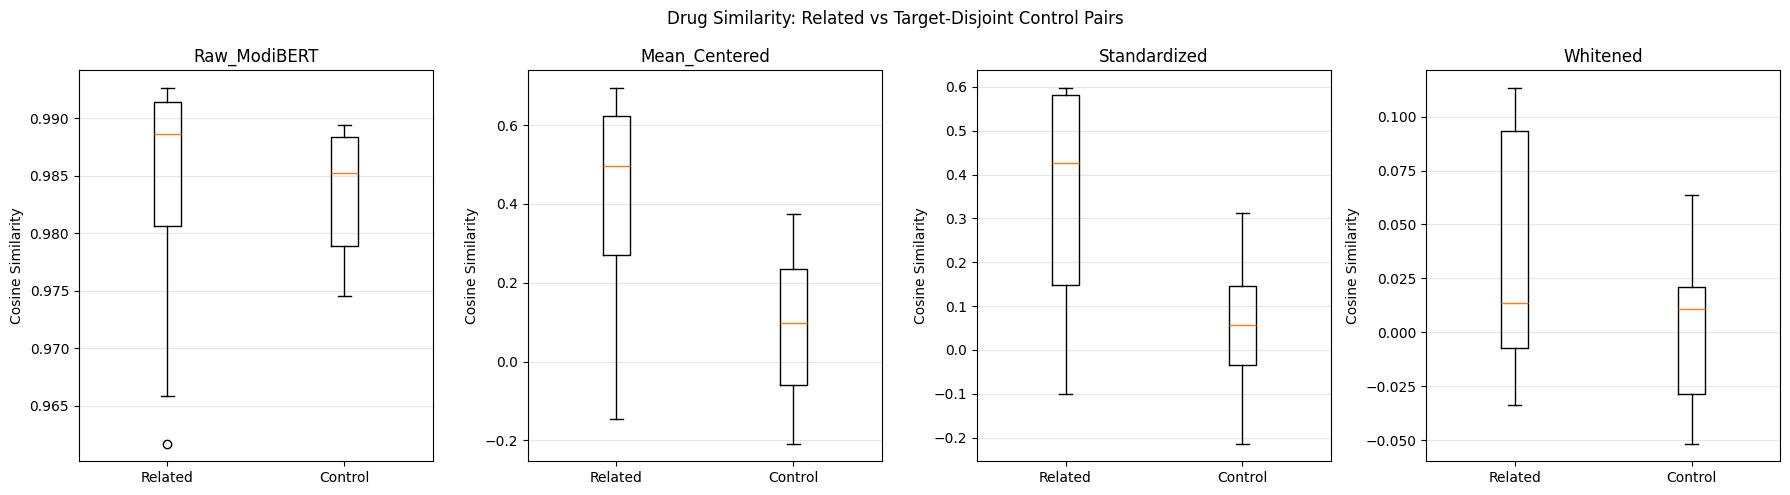

In [16]:
# ============================================================
# CSE499B — REPRESENTATION VALIDATION
# Step 10: Visualize Related vs Control similarity
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, representation in zip(axes, representation_columns):

    related_scores = similarity_df[
        similarity_df["type"] == "TARGET_RELATED"
    ][representation]

    control_scores = similarity_df[
        similarity_df["type"] == "TARGET_DISJOINT_CONTROL"
    ][representation]

    ax.boxplot(
        [related_scores, control_scores],
        tick_labels=["Related", "Control"]
    )

    ax.set_title(representation)
    ax.set_ylabel("Cosine Similarity")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Drug Similarity: Related vs Target-Disjoint Control Pairs"
)

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# CSE499B — REPRESENTATION VALIDATION
# Step 11: Expand validation set to 100 pairs
# ============================================================

import random
from collections import defaultdict

random.seed(123)

# ------------------------------------------------------------
# Build target -> drug mapping
# ------------------------------------------------------------

target_to_drugs = defaultdict(list)

for drug_idx, targets in enumerate(target_sets):

    for target in targets:
        target_to_drugs[target].append(drug_idx)


# ------------------------------------------------------------
# Create RELATED pairs
# ------------------------------------------------------------

related_pairs_all = set()

for target, drug_indices in target_to_drugs.items():

    if len(drug_indices) < 2:
        continue

    # Shuffle drugs belonging to this target
    shuffled = drug_indices.copy()
    random.shuffle(shuffled)

    # Generate pairs
    for i in range(len(shuffled)):

        for j in range(i + 1, len(shuffled)):

            idx_a = shuffled[i]
            idx_b = shuffled[j]

            pair_key = tuple(sorted((idx_a, idx_b)))

            related_pairs_all.add(pair_key)

            # We only need more than 50 candidates
            if len(related_pairs_all) >= 500:
                break

        if len(related_pairs_all) >= 500:
            break

    if len(related_pairs_all) >= 500:
        break


# Randomly select 50 related pairs
related_pairs_all = list(related_pairs_all)
random.shuffle(related_pairs_all)

related_pairs_50 = related_pairs_all[:50]


# ------------------------------------------------------------
# Create TARGET-DISJOINT control pairs
# ------------------------------------------------------------

drugs_with_targets = [
    idx for idx, targets in enumerate(target_sets)
    if len(targets) > 0
]

control_pairs_all = set()

while len(control_pairs_all) < 50:

    idx_a, idx_b = random.sample(drugs_with_targets, 2)

    # They must NOT share a target
    if target_sets[idx_a].isdisjoint(target_sets[idx_b]):

        pair_key = tuple(sorted((idx_a, idx_b)))

        # Avoid accidentally using a related pair
        if pair_key not in set(related_pairs_50):

            control_pairs_all.add(pair_key)


control_pairs_50 = list(control_pairs_all)


# ------------------------------------------------------------
# Create validation dataframe
# ------------------------------------------------------------

expanded_rows = []

# Related
for idx_a, idx_b in related_pairs_50:

    shared_targets = target_sets[idx_a].intersection(
        target_sets[idx_b]
    )

    expanded_rows.append({
        "type": "TARGET_RELATED",
        "drug_a": drugs_df.iloc[idx_a]["name"],
        "drug_b": drugs_df.iloc[idx_b]["name"],
        "drug_a_id": drugs_df.iloc[idx_a]["drugbank_id"],
        "drug_b_id": drugs_df.iloc[idx_b]["drugbank_id"],
        "shared_targets": "; ".join(sorted(shared_targets))
    })


# Controls
for idx_a, idx_b in control_pairs_50:

    expanded_rows.append({
        "type": "TARGET_DISJOINT_CONTROL",
        "drug_a": drugs_df.iloc[idx_a]["name"],
        "drug_b": drugs_df.iloc[idx_b]["name"],
        "drug_a_id": drugs_df.iloc[idx_a]["drugbank_id"],
        "drug_b_id": drugs_df.iloc[idx_b]["drugbank_id"],
        "shared_targets": ""
    })


expanded_validation_df = pd.DataFrame(expanded_rows)


# ------------------------------------------------------------
# Final check
# ------------------------------------------------------------

print("Expanded validation set:")
print(expanded_validation_df["type"].value_counts())

print("\nTotal pairs:", len(expanded_validation_df))

display(expanded_validation_df.head(10))

Expanded validation set:
type
TARGET_RELATED             50
TARGET_DISJOINT_CONTROL    50
Name: count, dtype: int64

Total pairs: 100


,type,drug_a,drug_b,drug_a_id,drug_b_id,shared_targets
0,TARGET_RELATED,Pyridoxal phosphate,Anisindione,DB00114,DB01125,Prothrombin
1,TARGET_RELATED,Ximelagatran,Turoctocog alfa pegol,DB04898,DB14738,Prothrombin
2,TARGET_RELATED,Atecegatran metoxil,Gabexate,DB12507,DB12831,Prothrombin
3,TARGET_RELATED,Ximelagatran,Flovagatran,DB04898,DB05714,Prothrombin
4,TARGET_RELATED,Recombinant alpha 1-antitrypsin,Y-27632,DB05481,DB08756,Prothrombin
5,TARGET_RELATED,Enoxaparin,Napsagatran anhydrous,DB01225,DB20288,Prothrombin
6,TARGET_RELATED,Thrombomodulin Alfa,Dabigatran etexilate,DB05777,DB06695,Prothrombin
7,TARGET_RELATED,Thrombomodulin Alfa,Efegatran,DB05777,DB21303,Prothrombin
8,TARGET_RELATED,Thrombomodulin Alfa,Copper,DB05777,DB09130,Prothrombin
9,TARGET_RELATED,Antithrombin Alfa,Zinc acetate,DB11166,DB14487,Prothrombin


In [18]:
# ============================================================
# CSE499B — REPRESENTATION VALIDATION
# Step 12: Calculate similarity for 100 validation pairs
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

# Map DrugBank ID → embedding row
drug_to_row = dict(
    zip(
        embedding_id_map["drugbank_id"],
        embedding_id_map.index
    )
)

# Four representations
representations = {
    "Raw_ModiBERT": modibert_embeddings,
    "Mean_Centered": modibert_centered,
    "Standardized": modibert_standardized,
    "Whitened": modibert_whitened
}

expanded_similarity_rows = []

# Calculate similarity for every pair
for _, pair in expanded_validation_df.iterrows():

    idx_a = drug_to_row[pair["drug_a_id"]]
    idx_b = drug_to_row[pair["drug_b_id"]]

    result = {
        "type": pair["type"],
        "drug_a": pair["drug_a"],
        "drug_b": pair["drug_b"],
        "shared_targets": pair["shared_targets"]
    }

    for representation_name, embeddings in representations.items():

        vector_a = embeddings[idx_a].reshape(1, -1)
        vector_b = embeddings[idx_b].reshape(1, -1)

        similarity = cosine_similarity(
            vector_a,
            vector_b
        )[0, 0]

        result[representation_name] = similarity

    expanded_similarity_rows.append(result)


# Create dataframe
expanded_similarity_df = pd.DataFrame(
    expanded_similarity_rows
)

print("Similarity calculations completed.")
print("Number of pairs:", len(expanded_similarity_df))

display(expanded_similarity_df.head(10))

Similarity calculations completed.
Number of pairs: 100


,type,drug_a,drug_b,shared_targets,Raw_ModiBERT,Mean_Centered,Standardized,Whitened
0,TARGET_RELATED,Pyridoxal phosphate,Anisindione,Prothrombin,0.991249,0.590655,0.484983,-0.047501
1,TARGET_RELATED,Ximelagatran,Turoctocog alfa pegol,Prothrombin,0.991505,0.326111,0.288024,0.017055
2,TARGET_RELATED,Atecegatran metoxil,Gabexate,Prothrombin,0.976242,-0.040546,0.001938,-0.004954
3,TARGET_RELATED,Ximelagatran,Flovagatran,Prothrombin,0.969943,-0.002567,-0.008651,0.045110
4,TARGET_RELATED,Recombinant alpha 1-antitrypsin,Y-27632,Prothrombin,0.951061,-0.252297,-0.157445,0.020104
5,TARGET_RELATED,Enoxaparin,Napsagatran anhydrous,Prothrombin,0.975195,-0.254373,-0.215006,-0.041878
6,TARGET_RELATED,Thrombomodulin Alfa,Dabigatran etexilate,Prothrombin,0.984424,0.246402,0.284853,0.047364
7,TARGET_RELATED,Thrombomodulin Alfa,Efegatran,Prothrombin,0.974419,-0.302440,-0.235948,-0.053239
8,TARGET_RELATED,Thrombomodulin Alfa,Copper,Prothrombin,0.990557,0.377964,0.313280,-0.031967
9,TARGET_RELATED,Antithrombin Alfa,Zinc acetate,Prothrombin,0.989211,0.389135,0.261907,-0.046396


In [19]:
# ============================================================
# CSE499B — REPRESENTATION VALIDATION
# Step 12A: Create a more diverse validation set
# ============================================================

import random
from collections import defaultdict

random.seed(2026)

# ------------------------------------------------------------
# Build target -> drugs mapping
# ------------------------------------------------------------

target_to_drugs = defaultdict(list)

for drug_idx, targets in enumerate(target_sets):
    for target in targets:
        target_to_drugs[target].append(drug_idx)


# ------------------------------------------------------------
# Select targets that have at least 2 different drugs
# ------------------------------------------------------------

eligible_targets = [
    target
    for target, drug_indices in target_to_drugs.items()
    if len(drug_indices) >= 2
]

print("Eligible targets:", len(eligible_targets))


# ------------------------------------------------------------
# Randomly select 50 DIFFERENT targets
# ------------------------------------------------------------

selected_targets = random.sample(
    eligible_targets,
    50
)


# ------------------------------------------------------------
# Create one related pair from each selected target
# ------------------------------------------------------------

related_pairs_50 = []

for target in selected_targets:

    drug_indices = target_to_drugs[target]

    idx_a, idx_b = random.sample(
        drug_indices,
        2
    )

    related_pairs_50.append(
        (idx_a, idx_b, {target})
    )


# ------------------------------------------------------------
# Create 50 target-disjoint control pairs
# ------------------------------------------------------------

drugs_with_targets = [
    idx
    for idx, targets in enumerate(target_sets)
    if len(targets) > 0
]

related_pair_ids = {
    tuple(sorted((a, b)))
    for a, b, _ in related_pairs_50
}

control_pairs_50 = []
used_control_pairs = set()

while len(control_pairs_50) < 50:

    idx_a, idx_b = random.sample(
        drugs_with_targets,
        2
    )

    pair_key = tuple(sorted((idx_a, idx_b)))

    # Must be target-disjoint
    if not target_sets[idx_a].isdisjoint(
        target_sets[idx_b]
    ):
        continue

    # Avoid duplicates and related pairs
    if pair_key in used_control_pairs:
        continue

    if pair_key in related_pair_ids:
        continue

    used_control_pairs.add(pair_key)

    control_pairs_50.append(
        (idx_a, idx_b, set())
    )


# ------------------------------------------------------------
# Create final validation dataframe
# ------------------------------------------------------------

validation_rows = []

for idx_a, idx_b, shared_target in related_pairs_50:

    validation_rows.append({
        "type": "TARGET_RELATED",
        "drug_a": drugs_df.iloc[idx_a]["name"],
        "drug_b": drugs_df.iloc[idx_b]["name"],
        "drug_a_id": drugs_df.iloc[idx_a]["drugbank_id"],
        "drug_b_id": drugs_df.iloc[idx_b]["drugbank_id"],
        "shared_targets": "; ".join(sorted(shared_target))
    })


for idx_a, idx_b, _ in control_pairs_50:

    validation_rows.append({
        "type": "TARGET_DISJOINT_CONTROL",
        "drug_a": drugs_df.iloc[idx_a]["name"],
        "drug_b": drugs_df.iloc[idx_b]["name"],
        "drug_a_id": drugs_df.iloc[idx_a]["drugbank_id"],
        "drug_b_id": drugs_df.iloc[idx_b]["drugbank_id"],
        "shared_targets": ""
    })


diverse_validation_df = pd.DataFrame(
    validation_rows
)

print("\nValidation set:")
print(
    diverse_validation_df["type"].value_counts()
)

print(
    "\nUnique shared targets among related pairs:",
    diverse_validation_df[
        diverse_validation_df["type"] == "TARGET_RELATED"
    ]["shared_targets"].nunique()
)

display(diverse_validation_df)

Eligible targets: 1987

Validation set:
type
TARGET_RELATED             50
TARGET_DISJOINT_CONTROL    50
Name: count, dtype: int64

Unique shared targets among related pairs: 50


,type,drug_a,drug_b,drug_a_id,drug_b_id,shared_targets
0,TARGET_RELATED,Norvaline,gamma-Aminobutyric acid,DB04185,DB02530,"Glycine amidinotransferase, mitochondrial"
1,TARGET_RELATED,Cefmetazole,Cyclacillin,DB00274,DB01000,Penicillin binding protein 2a
2,TARGET_RELATED,Amifostine,Levamisole,DB01143,DB00848,"Alkaline phosphatase, germ cell type"
3,TARGET_RELATED,Ponalrestat,Remogliflozin etabonate,DB19717,DB12935,Probable glucose sensor protein SLC5A4
4,TARGET_RELATED,Brexanolone,Ethanol,DB11859,DB00898,Gamma-aminobutyric acid receptor subunit delta
...,...,...,...,...,...,...
95,TARGET_DISJOINT_CONTROL,Terlipressin,AEE-788,DB02638,DB12558,
96,TARGET_DISJOINT_CONTROL,Lubeluzole,Masoprocol,DB21272,DB00179,
97,TARGET_DISJOINT_CONTROL,Oxamniquine,Fidexaban,DB01096,DB19562,
98,TARGET_DISJOINT_CONTROL,Glecaprevir,Rapacuronium,DB13879,DB04834,


In [20]:
# ============================================================
# CSE499B — REPRESENTATION VALIDATION
# Step 12B: Similarity for the corrected 100-pair set
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

# DrugBank ID → embedding row
drug_to_row = dict(
    zip(
        embedding_id_map["drugbank_id"],
        embedding_id_map.index
    )
)

# Embedding representations
representations = {
    "Raw_ModiBERT": modibert_embeddings,
    "Mean_Centered": modibert_centered,
    "Standardized": modibert_standardized,
    "Whitened": modibert_whitened
}

diverse_similarity_rows = []

for _, pair in diverse_validation_df.iterrows():

    idx_a = drug_to_row[pair["drug_a_id"]]
    idx_b = drug_to_row[pair["drug_b_id"]]

    result = {
        "type": pair["type"],
        "drug_a": pair["drug_a"],
        "drug_b": pair["drug_b"],
        "shared_targets": pair["shared_targets"]
    }

    for representation_name, embeddings in representations.items():

        vector_a = embeddings[idx_a].reshape(1, -1)
        vector_b = embeddings[idx_b].reshape(1, -1)

        similarity = cosine_similarity(
            vector_a,
            vector_b
        )[0, 0]

        result[representation_name] = similarity

    diverse_similarity_rows.append(result)


# Create dataframe
diverse_similarity_df = pd.DataFrame(
    diverse_similarity_rows
)

print("Similarity calculations completed.")
print("Total pairs:", len(diverse_similarity_df))

display(diverse_similarity_df.head(10))

Similarity calculations completed.
Total pairs: 100


,type,drug_a,drug_b,shared_targets,Raw_ModiBERT,Mean_Centered,Standardized,Whitened
0,TARGET_RELATED,Norvaline,gamma-Aminobutyric acid,"Glycine amidinotransferase, mitochondrial",0.966120,0.267698,0.223755,0.041053
1,TARGET_RELATED,Cefmetazole,Cyclacillin,Penicillin binding protein 2a,0.992737,0.670413,0.624806,0.117923
2,TARGET_RELATED,Amifostine,Levamisole,"Alkaline phosphatase, germ cell type",0.993737,0.514540,0.411219,0.003908
3,TARGET_RELATED,Ponalrestat,Remogliflozin etabonate,Probable glucose sensor protein SLC5A4,0.973773,-0.131035,-0.064806,-0.013313
4,TARGET_RELATED,Brexanolone,Ethanol,Gamma-aminobutyric acid receptor subunit delta,0.991723,0.397211,0.265373,0.034553
5,TARGET_RELATED,Uridine monophosphate,Uridine-5'-Diphosphate,Galactose-1-phosphate uridylyltransferase,0.985219,0.652958,0.688374,0.351042
6,TARGET_RELATED,Bivatuzumab,Hyaluronic acid,CD44 antigen,0.980566,-0.134108,-0.120278,-0.003840
7,TARGET_RELATED,ISO-1 F-18,Roluperidone,Sigma intracellular receptor 2,0.977811,0.073148,0.004239,-0.053765
8,TARGET_RELATED,ALT-2074,Mesalazine,"Nitric oxide synthase, inducible",0.988604,-0.048068,-0.020757,0.046452
9,TARGET_RELATED,Copper,Ocriplasmin,Alpha-2-antiplasmin,0.990534,0.309150,0.232737,-0.036178


In [21]:
# ============================================================
# CSE499B — REPRESENTATION VALIDATION
# Step 13: Final statistical comparison — 100 pairs
# ============================================================

from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score

representation_columns = [
    "Raw_ModiBERT",
    "Mean_Centered",
    "Standardized",
    "Whitened"
]

final_statistics = []

for representation in representation_columns:

    # Get related-pair similarities
    related_scores = diverse_similarity_df[
        diverse_similarity_df["type"] == "TARGET_RELATED"
    ][representation].values

    # Get control-pair similarities
    control_scores = diverse_similarity_df[
        diverse_similarity_df["type"] == "TARGET_DISJOINT_CONTROL"
    ][representation].values

    # --------------------------------------------------------
    # Basic statistics
    # --------------------------------------------------------

    related_mean = np.mean(related_scores)
    control_mean = np.mean(control_scores)

    related_median = np.median(related_scores)
    control_median = np.median(control_scores)

    # --------------------------------------------------------
    # Mann-Whitney U test
    # --------------------------------------------------------

    u_stat, p_value = mannwhitneyu(
        related_scores,
        control_scores,
        alternative="greater"
    )

    # --------------------------------------------------------
    # AUC
    # --------------------------------------------------------

    labels = (
        [1] * len(related_scores) +
        [0] * len(control_scores)
    )

    scores = list(related_scores) + list(control_scores)

    auc = roc_auc_score(
        labels,
        scores
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    final_statistics.append({
        "Representation": representation,
        "Related_Mean": related_mean,
        "Control_Mean": control_mean,
        "Mean_Difference": related_mean - control_mean,
        "Related_Median": related_median,
        "Control_Median": control_median,
        "Mann_Whitney_U": u_stat,
        "p_value": p_value,
        "AUC": auc
    })


# Create final results table
final_statistics_df = pd.DataFrame(
    final_statistics
)

display(final_statistics_df)

,Representation,Related_Mean,Control_Mean,Mean_Difference,Related_Median,Control_Median,Mann_Whitney_U,p_value,AUC
0,Raw_ModiBERT,0.984891,0.981804,0.003087,0.987849,0.979892,1576.0,0.012418,0.6304
1,Mean_Centered,0.331250,0.104678,0.226572,0.400199,0.120022,1705.0,0.000864,0.6820
2,Standardized,0.318515,0.075233,0.243282,0.330499,0.059953,1806.0,0.000064,0.7224
3,Whitened,0.097472,0.003966,0.093506,0.044478,0.006076,1868.0,0.000010,0.7472


In [22]:
# ============================================================
# CSE499B — REPRESENTATION VALIDATION
# Step 14: Bootstrap AUC robustness check
# ============================================================

from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

np.random.seed(42)

bootstrap_results = []

n_bootstrap = 5000

for representation in representation_columns:

    related_scores = diverse_similarity_df[
        diverse_similarity_df["type"] == "TARGET_RELATED"
    ][representation].values

    control_scores = diverse_similarity_df[
        diverse_similarity_df["type"] == "TARGET_DISJOINT_CONTROL"
    ][representation].values

    auc_values = []

    for _ in range(n_bootstrap):

        # Resample related pairs
        related_sample = np.random.choice(
            related_scores,
            size=len(related_scores),
            replace=True
        )

        # Resample control pairs
        control_sample = np.random.choice(
            control_scores,
            size=len(control_scores),
            replace=True
        )

        labels = (
            [1] * len(related_sample) +
            [0] * len(control_sample)
        )

        scores = np.concatenate([
            related_sample,
            control_sample
        ])

        auc = roc_auc_score(
            labels,
            scores
        )

        auc_values.append(auc)

    auc_values = np.array(auc_values)

    # 95% bootstrap confidence interval
    lower = np.percentile(auc_values, 2.5)
    upper = np.percentile(auc_values, 97.5)

    bootstrap_results.append({
        "Representation": representation,
        "Original_AUC": roc_auc_score(
            [1] * len(related_scores) +
            [0] * len(control_scores),
            np.concatenate([
                related_scores,
                control_scores
            ])
        ),
        "Bootstrap_Mean_AUC": auc_values.mean(),
        "CI_95_Lower": lower,
        "CI_95_Upper": upper
    })


bootstrap_df = pd.DataFrame(
    bootstrap_results
)

display(bootstrap_df)

,Representation,Original_AUC,Bootstrap_Mean_AUC,CI_95_Lower,CI_95_Upper
0,Raw_ModiBERT,0.6304,0.630522,0.51760,0.73881
1,Mean_Centered,0.6820,0.683083,0.57360,0.78401
2,Standardized,0.7224,0.721130,0.61599,0.81921
3,Whitened,0.7472,0.748043,0.64879,0.83600


In [23]:
# ============================================================
# CSE499B — REPRESENTATION VALIDATION
# Step 15: Pairwise bootstrap comparison of AUC
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

np.random.seed(42)

# ------------------------------------------------------------
# Get the 50 related and 50 control rows
# ------------------------------------------------------------

related_df = diverse_similarity_df[
    diverse_similarity_df["type"] == "TARGET_RELATED"
].reset_index(drop=True)

control_df = diverse_similarity_df[
    diverse_similarity_df["type"] == "TARGET_DISJOINT_CONTROL"
].reset_index(drop=True)


# ------------------------------------------------------------
# Function to calculate AUC
# ------------------------------------------------------------

def calculate_auc(related_scores, control_scores):

    labels = (
        [1] * len(related_scores) +
        [0] * len(control_scores)
    )

    scores = np.concatenate([
        related_scores,
        control_scores
    ])

    return roc_auc_score(labels, scores)


# ------------------------------------------------------------
# Representations to compare against Whitening
# ------------------------------------------------------------

comparisons = [
    ("Whitened", "Standardized"),
    ("Whitened", "Mean_Centered"),
    ("Whitened", "Raw_ModiBERT")
]


# ------------------------------------------------------------
# Bootstrap
# ------------------------------------------------------------

n_bootstrap = 5000

comparison_results = []

for better_rep, other_rep in comparisons:

    differences = []

    for _ in range(n_bootstrap):

        # Resample related pairs
        related_indices = np.random.choice(
            len(related_df),
            size=len(related_df),
            replace=True
        )

        # Resample control pairs
        control_indices = np.random.choice(
            len(control_df),
            size=len(control_df),
            replace=True
        )

        # Get resampled scores
        better_related = related_df[
            better_rep
        ].values[related_indices]

        better_control = control_df[
            better_rep
        ].values[control_indices]

        other_related = related_df[
            other_rep
        ].values[related_indices]

        other_control = control_df[
            other_rep
        ].values[control_indices]

        # Calculate AUCs
        better_auc = calculate_auc(
            better_related,
            better_control
        )

        other_auc = calculate_auc(
            other_related,
            other_control
        )

        # Difference between AUCs
        differences.append(
            better_auc - other_auc
        )

    differences = np.array(differences)

    # --------------------------------------------------------
    # 95% confidence interval
    # --------------------------------------------------------

    lower = np.percentile(
        differences,
        2.5
    )

    upper = np.percentile(
        differences,
        97.5
    )

    # Actual observed difference
    original_better_auc = calculate_auc(
        related_df[better_rep].values,
        control_df[better_rep].values
    )

    original_other_auc = calculate_auc(
        related_df[other_rep].values,
        control_df[other_rep].values
    )

    comparison_results.append({
        "Comparison": f"{better_rep} - {other_rep}",
        "Whichever_AUC": original_better_auc,
        "Other_AUC": original_other_auc,
        "Observed_AUC_Difference": (
            original_better_auc -
            original_other_auc
        ),
        "Bootstrap_Mean_Difference": differences.mean(),
        "CI_95_Lower": lower,
        "CI_95_Upper": upper
    })


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

auc_comparison_df = pd.DataFrame(
    comparison_results
)

display(auc_comparison_df)

,Comparison,Whichever_AUC,Other_AUC,Observed_AUC_Difference,Bootstrap_Mean_Difference,CI_95_Lower,CI_95_Upper
0,Whitened - Standardized,0.7472,0.7224,0.0248,0.023835,-0.08401,0.13480
1,Whitened - Mean_Centered,0.7472,0.6820,0.0652,0.064298,-0.04962,0.18082
2,Whitened - Raw_ModiBERT,0.7472,0.6304,0.1168,0.118123,-0.00320,0.24081


In [5]:
# ============================================================
# CSE499B — CLS POOLING EXPERIMENT
# Step 17: Generate CLS-pooled ModiBERT embeddings
# ============================================================

import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForMaskedLM
from torch.utils.data import DataLoader, TensorDataset

# ------------------------------------------------------------
# 1. Path to the already-trained ModiBERT
# ------------------------------------------------------------

MODIBERT_DIR = f'{CSE499B_DIR}/modibert_final'

# ------------------------------------------------------------
# 2. Load the trained ModiBERT + tokenizer
# ------------------------------------------------------------

cls_tokenizer = AutoTokenizer.from_pretrained(
    MODIBERT_DIR
)

cls_model = AutoModelForMaskedLM.from_pretrained(
    MODIBERT_DIR
)

cls_model.to(device)
cls_model.eval()

print("ModiBERT loaded.")
print("Device:", device)


# ------------------------------------------------------------
# 3. Tokenize the same DrugBank text used previously
# ------------------------------------------------------------

texts = drugs_df["text_blob"].tolist()

encoded = cls_tokenizer(
    texts,
    truncation=True,
    max_length=512,
    padding="max_length",
    return_tensors="pt"
)

input_ids = encoded["input_ids"]
attention_masks = encoded["attention_mask"]

print("Tokenized input shape:", input_ids.shape)


# ------------------------------------------------------------
# 4. Create DataLoader
# ------------------------------------------------------------

BATCH_SIZE = 32

dataset = TensorDataset(
    input_ids,
    attention_masks
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ------------------------------------------------------------
# 5. Generate CLS embeddings
# ------------------------------------------------------------

cls_embeddings_list = []

with torch.no_grad():

    for batch_number, batch in enumerate(loader):

        batch_input_ids = batch[0].to(device)
        batch_attention_mask = batch[1].to(device)

        outputs = cls_model(
            input_ids=batch_input_ids,
            attention_mask=batch_attention_mask,
            output_hidden_states=True
        )

        # Last transformer layer
        last_hidden_state = outputs.hidden_states[-1]

        # First token = [CLS]
        cls_vectors = last_hidden_state[:, 0, :]

        cls_embeddings_list.append(
            cls_vectors.cpu().numpy()
        )

        if (batch_number + 1) % 50 == 0:
            print(
                f"Processed {(batch_number + 1) * BATCH_SIZE} drugs..."
            )


# ------------------------------------------------------------
# 6. Combine all batches
# ------------------------------------------------------------

cls_embeddings = np.vstack(
    cls_embeddings_list
)

print("\nCLS embeddings:", cls_embeddings.shape)


# ------------------------------------------------------------
# 7. Save embeddings
# ------------------------------------------------------------

np.save(
    f'{CSE499B_DIR}/modibert_cls_embeddings.npy',
    cls_embeddings
)


# ------------------------------------------------------------
# 8. Save ID map
# ------------------------------------------------------------

cls_id_map = pd.DataFrame({
    "row_index": range(len(drugs_df)),
    "drugbank_id": drugs_df["drugbank_id"].tolist(),
    "name": drugs_df["name"].tolist()
})

cls_id_map.to_csv(
    f'{CSE499B_DIR}/modibert_cls_embedding_id_map.csv',
    index=False
)

print("\nSaved successfully:")
print("modibert_cls_embeddings.npy")
print("modibert_cls_embedding_id_map.csv")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

ModiBERT loaded.
Device: cuda
Tokenized input shape: torch.Size([12742, 512])
Processed 1600 drugs...
Processed 3200 drugs...
Processed 4800 drugs...
Processed 6400 drugs...
Processed 8000 drugs...
Processed 9600 drugs...
Processed 11200 drugs...

CLS embeddings: (12742, 768)

Saved successfully:
modibert_cls_embeddings.npy
modibert_cls_embedding_id_map.csv


In [7]:
# ============================================================
# CSE499B — RESTORE VALIDATION SET AFTER RUNTIME RESET
# Step 18A
# ============================================================

import random
from collections import defaultdict

random.seed(2026)

# ------------------------------------------------------------
# 1. Convert each drug's target information into a set
# ------------------------------------------------------------

def parse_targets(value):

    if pd.isna(value):
        return set()

    return {
        target.strip()
        for target in str(value).split(";")
        if target.strip()
    }


target_sets = [
    parse_targets(targets)
    for targets in drugs_df["targets"]
]

print("Target sets recreated:", len(target_sets))

print(
    "Drugs with target information:",
    sum(len(targets) > 0 for targets in target_sets)
)


# ------------------------------------------------------------
# 2. Build target -> drug mapping
# ------------------------------------------------------------

target_to_drugs = defaultdict(list)

for drug_idx, targets in enumerate(target_sets):

    for target in targets:
        target_to_drugs[target].append(drug_idx)


# ------------------------------------------------------------
# 3. Find targets shared by at least two drugs
# ------------------------------------------------------------

eligible_targets = [
    target
    for target, drug_indices in target_to_drugs.items()
    if len(drug_indices) >= 2
]

print(
    "Eligible targets:",
    len(eligible_targets)
)


# ------------------------------------------------------------
# 4. Select 50 different targets
# ------------------------------------------------------------

selected_targets = random.sample(
    eligible_targets,
    50
)


# ------------------------------------------------------------
# 5. Create 50 RELATED pairs
#    One pair per selected target
# ------------------------------------------------------------

related_pairs_50 = []

for target in selected_targets:

    drug_indices = target_to_drugs[target]

    idx_a, idx_b = random.sample(
        drug_indices,
        2
    )

    related_pairs_50.append(
        (idx_a, idx_b, {target})
    )


# ------------------------------------------------------------
# 6. Create 50 TARGET-DISJOINT CONTROL pairs
# ------------------------------------------------------------

drugs_with_targets = [
    idx
    for idx, targets in enumerate(target_sets)
    if len(targets) > 0
]

related_pair_ids = {
    tuple(sorted((a, b)))
    for a, b, _ in related_pairs_50
}

control_pairs_50 = []
used_control_pairs = set()

while len(control_pairs_50) < 50:

    idx_a, idx_b = random.sample(
        drugs_with_targets,
        2
    )

    pair_key = tuple(
        sorted((idx_a, idx_b))
    )

    # Must have NO shared target
    if not target_sets[idx_a].isdisjoint(
        target_sets[idx_b]
    ):
        continue

    # Avoid duplicate control pairs
    if pair_key in used_control_pairs:
        continue

    # Avoid accidentally using a related pair
    if pair_key in related_pair_ids:
        continue

    used_control_pairs.add(pair_key)

    control_pairs_50.append(
        (idx_a, idx_b, set())
    )


# ------------------------------------------------------------
# 7. Build validation dataframe
# ------------------------------------------------------------

validation_rows = []

# Related pairs
for idx_a, idx_b, shared_target in related_pairs_50:

    validation_rows.append({
        "type": "TARGET_RELATED",
        "drug_a": drugs_df.iloc[idx_a]["name"],
        "drug_b": drugs_df.iloc[idx_b]["name"],
        "drug_a_id": drugs_df.iloc[idx_a]["drugbank_id"],
        "drug_b_id": drugs_df.iloc[idx_b]["drugbank_id"],
        "shared_targets": "; ".join(
            sorted(shared_target)
        )
    })


# Control pairs
for idx_a, idx_b, _ in control_pairs_50:

    validation_rows.append({
        "type": "TARGET_DISJOINT_CONTROL",
        "drug_a": drugs_df.iloc[idx_a]["name"],
        "drug_b": drugs_df.iloc[idx_b]["name"],
        "drug_a_id": drugs_df.iloc[idx_a]["drugbank_id"],
        "drug_b_id": drugs_df.iloc[idx_b]["drugbank_id"],
        "shared_targets": ""
    })


diverse_validation_df = pd.DataFrame(
    validation_rows
)


# ------------------------------------------------------------
# 8. Verify
# ------------------------------------------------------------

print("\nValidation set:")
print(
    diverse_validation_df["type"].value_counts()
)

print(
    "\nUnique shared targets:",
    diverse_validation_df[
        diverse_validation_df["type"] == "TARGET_RELATED"
    ]["shared_targets"].nunique()
)

display(
    diverse_validation_df.head(10)
)

Target sets recreated: 12742
Drugs with target information: 5633
Eligible targets: 1987

Validation set:
type
TARGET_RELATED             50
TARGET_DISJOINT_CONTROL    50
Name: count, dtype: int64

Unique shared targets: 50


,type,drug_a,drug_b,drug_a_id,drug_b_id,shared_targets
0,TARGET_RELATED,Citrulline,Ornithine,DB00155,DB00129,"Ornithine transcarbamylase, mitochondrial"
1,TARGET_RELATED,Ceftizoxime,Cefpiramide,DB01332,DB00430,D-alanyl-D-alanine carboxypeptidase DacC
2,TARGET_RELATED,Levamisole,Tetramisole,DB00848,DB16561,"Alkaline phosphatase, tissue-nonspecific isozyme"
3,TARGET_RELATED,Ponalrestat,Remogliflozin etabonate,DB19717,DB12935,Probable glucose sensor protein SLC5A4
4,TARGET_RELATED,Isavuconazole,Ethanol,DB11633,DB00898,G protein-activated inward rectifier potassium...
5,TARGET_RELATED,Uridine-5'-Diphosphate,Uridine diphosphate glucose,DB03435,DB01861,DNA beta-glucosyltransferase
6,TARGET_RELATED,Hyaluronic acid,Bivatuzumab,DB08818,DB06550,CD44 antigen
7,TARGET_RELATED,ISO-1 F-18,Roluperidone,DB14900,DB13080,Sigma intracellular receptor 2
8,TARGET_RELATED,Arginine,ATP,DB00125,DB00171,Argininosuccinate synthase
9,TARGET_RELATED,Copper,Ocriplasmin,DB09130,DB08888,Alpha-2-antiplasmin


In [8]:
# ============================================================
# STEP 18B — Calculate CLS similarity on validation pairs
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

# Load saved CLS embeddings
cls_embeddings = np.load(
    f'{CSE499B_DIR}/modibert_cls_embeddings.npy'
)

cls_id_map = pd.read_csv(
    f'{CSE499B_DIR}/modibert_cls_embedding_id_map.csv'
)

print("CLS embeddings:", cls_embeddings.shape)
print("CLS ID map:", cls_id_map.shape)


# Verify row ordering
assert (
    cls_id_map["drugbank_id"].tolist()
    == embedding_id_map["drugbank_id"].tolist()
)

print("CLS row order matches existing embedding ID map. ✅")


# DrugBank ID → embedding row
cls_drug_to_row = dict(
    zip(
        cls_id_map["drugbank_id"],
        cls_id_map["row_index"]
    )
)


# Calculate cosine similarity
cls_similarity_rows = []

for _, pair in diverse_validation_df.iterrows():

    idx_a = cls_drug_to_row[pair["drug_a_id"]]
    idx_b = cls_drug_to_row[pair["drug_b_id"]]

    vector_a = cls_embeddings[idx_a].reshape(1, -1)
    vector_b = cls_embeddings[idx_b].reshape(1, -1)

    similarity = cosine_similarity(
        vector_a,
        vector_b
    )[0, 0]

    cls_similarity_rows.append({
        "type": pair["type"],
        "drug_a": pair["drug_a"],
        "drug_b": pair["drug_b"],
        "shared_targets": pair["shared_targets"],
        "CLS_ModiBERT": similarity
    })


# Create dataframe
cls_similarity_df = pd.DataFrame(
    cls_similarity_rows
)

print("\nCLS similarity calculation completed.")
print("Total pairs:", len(cls_similarity_df))

display(cls_similarity_df.head(10))

CLS embeddings: (12742, 768)
CLS ID map: (12742, 3)
CLS row order matches existing embedding ID map. ✅

CLS similarity calculation completed.
Total pairs: 100


,type,drug_a,drug_b,shared_targets,CLS_ModiBERT
0,TARGET_RELATED,Citrulline,Ornithine,"Ornithine transcarbamylase, mitochondrial",0.863369
1,TARGET_RELATED,Ceftizoxime,Cefpiramide,D-alanyl-D-alanine carboxypeptidase DacC,0.926915
2,TARGET_RELATED,Levamisole,Tetramisole,"Alkaline phosphatase, tissue-nonspecific isozyme",0.898629
3,TARGET_RELATED,Ponalrestat,Remogliflozin etabonate,Probable glucose sensor protein SLC5A4,0.921503
4,TARGET_RELATED,Isavuconazole,Ethanol,G protein-activated inward rectifier potassium...,0.903417
5,TARGET_RELATED,Uridine-5'-Diphosphate,Uridine diphosphate glucose,DNA beta-glucosyltransferase,0.908963
6,TARGET_RELATED,Hyaluronic acid,Bivatuzumab,CD44 antigen,0.773418
7,TARGET_RELATED,ISO-1 F-18,Roluperidone,Sigma intracellular receptor 2,0.936077
8,TARGET_RELATED,Arginine,ATP,Argininosuccinate synthase,0.925413
9,TARGET_RELATED,Copper,Ocriplasmin,Alpha-2-antiplasmin,0.899095


In [9]:
# ============================================================
# CSE499B — CLS POOLING VALIDATION
# Step 19: Statistical evaluation of CLS embeddings
# ============================================================

from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score

# ------------------------------------------------------------
# Separate related and control pairs
# ------------------------------------------------------------

cls_related = cls_similarity_df[
    cls_similarity_df["type"] == "TARGET_RELATED"
]["CLS_ModiBERT"].values

cls_control = cls_similarity_df[
    cls_similarity_df["type"] == "TARGET_DISJOINT_CONTROL"
]["CLS_ModiBERT"].values


# ------------------------------------------------------------
# Means and medians
# ------------------------------------------------------------

related_mean = np.mean(cls_related)
control_mean = np.mean(cls_control)

related_median = np.median(cls_related)
control_median = np.median(cls_control)

mean_difference = related_mean - control_mean


# ------------------------------------------------------------
# Mann–Whitney U test
# ------------------------------------------------------------

u_stat, p_value = mannwhitneyu(
    cls_related,
    cls_control,
    alternative="greater"
)


# ------------------------------------------------------------
# AUC
# ------------------------------------------------------------

labels = (
    [1] * len(cls_related) +
    [0] * len(cls_control)
)

scores = np.concatenate([
    cls_related,
    cls_control
])

cls_auc = roc_auc_score(
    labels,
    scores
)


# ------------------------------------------------------------
# Create result table
# ------------------------------------------------------------

cls_statistics_df = pd.DataFrame([{
    "Representation": "CLS_ModiBERT",
    "Related_Mean": related_mean,
    "Control_Mean": control_mean,
    "Mean_Difference": mean_difference,
    "Related_Median": related_median,
    "Control_Median": control_median,
    "Mann_Whitney_U": u_stat,
    "p_value": p_value,
    "AUC": cls_auc
}])


display(cls_statistics_df)

,Representation,Related_Mean,Control_Mean,Mean_Difference,Related_Median,Control_Median,Mann_Whitney_U,p_value,AUC
0,CLS_ModiBERT,0.897327,0.882613,0.014713,0.910402,0.884514,1540.0,0.022979,0.616


In [12]:
# ============================================================
# STEP 20A — Load saved whitened embeddings
# ============================================================

import numpy as np

modibert_whitened = np.load(
    f'{CSE499B_DIR}/modibert_embeddings_whitened.npy'
)

print("Whitened embeddings:", modibert_whitened.shape)

Whitened embeddings: (12742, 768)


In [13]:
# ============================================================
# STEP 20B — Inspect existing similarity graph
# ============================================================

import pandas as pd
import os

graph_path = f'{CSE499B_DIR}/similarity_graph_edges.csv'

print("File exists:", os.path.exists(graph_path))

if os.path.exists(graph_path):

    existing_graph = pd.read_csv(graph_path)

    print("\nGraph shape:", existing_graph.shape)

    print("\nColumns:")
    print(existing_graph.columns.tolist())

    print("\nFirst 10 rows:")
    display(existing_graph.head(10))

    print("\nSimilarity statistics:")
    print(existing_graph["similarity"].describe())

else:

    print("similarity_graph_edges.csv was not found.")

File exists: True

Graph shape: (85476, 5)

Columns:
['drug_1', 'drug_1_name', 'drug_2', 'drug_2_name', 'cosine_sim']

First 10 rows:


,drug_1,drug_1_name,drug_2,drug_2_name,cosine_sim
0,DB22669,Influenza A virus A/District of Columbia/27/20...,DB22670,Influenza A virus A/Croatia/10136RV/2023 X-425...,1.0
1,DB22669,Influenza A virus A/District of Columbia/27/20...,DB22669,Influenza A virus A/District of Columbia/27/20...,1.0
2,DB21766,Chikungunya virus Senegal strain 37997 capsid ...,DB21767,Chikungunya virus Senegal strain 37997 envelop...,1.0
3,DB21768,Chikungunya virus Senegal strain 37997 envelop...,DB21768,Chikungunya virus Senegal strain 37997 envelop...,1.0
4,DB22669,Influenza A virus A/District of Columbia/27/20...,DB31654,Influenza A virus A/Perth/722/2024 (H3N2) live...,1.0
5,DB22669,Influenza A virus A/District of Columbia/27/20...,DB22672,Influenza A virus A/Croatia/10136RV/2023 X-425...,1.0
6,DB22669,Influenza A virus A/District of Columbia/27/20...,DB22671,Influenza A virus A/Victoria/800/2024 CVR-289 ...,1.0
7,DB16923,Influenza B virus B/Austria/1359417/2021 recom...,DB17995,Influenza A virus A/West Virginia/30/2022 (H1N...,1.0
8,DB16923,Influenza B virus B/Austria/1359417/2021 recom...,DB17997,Influenza A virus A/Victoria/4897/2022 IVR-238...,1.0
9,DB16923,Influenza B virus B/Austria/1359417/2021 recom...,DB17998,Influenza A virus A/Victoria/4897/2022 IVR-238...,1.0



Similarity statistics:


KeyError: 'similarity'

In [14]:
# ============================================================
# STEP 20B — Inspect existing similarity graph
# ============================================================

import pandas as pd
import os

graph_path = f'{CSE499B_DIR}/similarity_graph_edges.csv'

print("File exists:", os.path.exists(graph_path))

existing_graph = pd.read_csv(graph_path)

print("\nGraph shape:")
print(existing_graph.shape)

print("\nColumns:")
print(existing_graph.columns.tolist())

print("\nFirst 10 rows:")
display(existing_graph.head(10))

File exists: True

Graph shape:
(85476, 5)

Columns:
['drug_1', 'drug_1_name', 'drug_2', 'drug_2_name', 'cosine_sim']

First 10 rows:


,drug_1,drug_1_name,drug_2,drug_2_name,cosine_sim
0,DB22669,Influenza A virus A/District of Columbia/27/20...,DB22670,Influenza A virus A/Croatia/10136RV/2023 X-425...,1.0
1,DB22669,Influenza A virus A/District of Columbia/27/20...,DB22669,Influenza A virus A/District of Columbia/27/20...,1.0
2,DB21766,Chikungunya virus Senegal strain 37997 capsid ...,DB21767,Chikungunya virus Senegal strain 37997 envelop...,1.0
3,DB21768,Chikungunya virus Senegal strain 37997 envelop...,DB21768,Chikungunya virus Senegal strain 37997 envelop...,1.0
4,DB22669,Influenza A virus A/District of Columbia/27/20...,DB31654,Influenza A virus A/Perth/722/2024 (H3N2) live...,1.0
5,DB22669,Influenza A virus A/District of Columbia/27/20...,DB22672,Influenza A virus A/Croatia/10136RV/2023 X-425...,1.0
6,DB22669,Influenza A virus A/District of Columbia/27/20...,DB22671,Influenza A virus A/Victoria/800/2024 CVR-289 ...,1.0
7,DB16923,Influenza B virus B/Austria/1359417/2021 recom...,DB17995,Influenza A virus A/West Virginia/30/2022 (H1N...,1.0
8,DB16923,Influenza B virus B/Austria/1359417/2021 recom...,DB17997,Influenza A virus A/Victoria/4897/2022 IVR-238...,1.0
9,DB16923,Influenza B virus B/Austria/1359417/2021 recom...,DB17998,Influenza A virus A/Victoria/4897/2022 IVR-238...,1.0


In [15]:
# ============================================================
# STEP 20C — Diagnose existing similarity graph
# ============================================================

# 1. Basic similarity statistics
print("Similarity statistics:")
print(existing_graph["cosine_sim"].describe())


# 2. Number of self-pairs
self_pairs = (
    existing_graph["drug_1"] ==
    existing_graph["drug_2"]
).sum()

print("\nSelf-pairs:", self_pairs)


# 3. Number of unique drugs appearing in graph
unique_drugs = set(
    existing_graph["drug_1"]
).union(
    set(existing_graph["drug_2"])
)

print("Unique drugs in graph:", len(unique_drugs))


# 4. Similarity distribution
print("\nSimilarity quantiles:")
print(
    existing_graph["cosine_sim"].quantile(
        [0, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
    )
)


# 5. Number of edges above several thresholds
for threshold in [0.90, 0.95, 0.97, 0.98, 0.99]:

    count = (
        existing_graph["cosine_sim"] >= threshold
    ).sum()

    print(
        f"Edges with cosine_sim >= {threshold}: {count}"
    )


# 6. Check whether exact duplicate pairs exist
duplicate_pairs = existing_graph.duplicated(
    subset=["drug_1", "drug_2"]
).sum()

print("\nDuplicate directed pairs:", duplicate_pairs)


# 7. Display lowest and highest similarities
print("\nLowest-similarity edges:")
display(
    existing_graph
    .sort_values("cosine_sim")
    .head(10)
)

print("\nHighest-similarity edges:")
display(
    existing_graph
    .sort_values("cosine_sim", ascending=False)
    .head(10)
)

Similarity statistics:
count    85476.000000
mean         0.284539
std          0.173814
min          0.067509
25%          0.187382
50%          0.230224
75%          0.301479
max          1.000000
Name: cosine_sim, dtype: float64

Self-pairs: 84
Unique drugs in graph: 12742

Similarity quantiles:
0.00    0.067509
0.01    0.134711
0.05    0.150964
0.10    0.162327
0.25    0.187382
0.50    0.230224
0.75    0.301479
0.90    0.454466
0.95    0.661785
0.99    1.000000
1.00    1.000000
Name: cosine_sim, dtype: float64
Edges with cosine_sim >= 0.9: 2812
Edges with cosine_sim >= 0.95: 2621
Edges with cosine_sim >= 0.97: 2529
Edges with cosine_sim >= 0.98: 2454
Edges with cosine_sim >= 0.99: 2413

Duplicate directed pairs: 0

Lowest-similarity edges:


,drug_1,drug_1_name,drug_2,drug_2_name,cosine_sim
85475,DB11568,Insulin tregopil,DB12821,Perflubutane,0.067509
85474,DB11568,Insulin tregopil,DB16267,Olutasidenib,0.067881
85473,DB11568,Insulin tregopil,DB21051,Pravadoline,0.068615
85472,DB01412,Theobromine,DB11568,Insulin tregopil,0.072313
85471,DB11568,Insulin tregopil,DB18389,CAN-106,0.074058
85470,DB11568,Insulin tregopil,DB21160,Lorcinadol,0.077658
85469,DB11568,Insulin tregopil,DB12764,Opaganib,0.080468
85468,DB08044,ABT-341,DB11568,Insulin tregopil,0.085530
85467,DB11568,Insulin tregopil,DB20896,Ciprefadol,0.091744
85466,DB06894,1-Dodecanol,DB11568,Insulin tregopil,0.094016



Highest-similarity edges:


,drug_1,drug_1_name,drug_2,drug_2_name,cosine_sim
92,DB16915,Influenza A virus A/Delaware/55/2019 CVR-45 (H...,DB16918,Influenza A virus A/Darwin/6/2021 IVR-227 (H3N...,1.0
0,DB22669,Influenza A virus A/District of Columbia/27/20...,DB22670,Influenza A virus A/Croatia/10136RV/2023 X-425...,1.0
20,DB16922,Influenza A virus A/Darwin/6/2021 (H3N2) recom...,DB17995,Influenza A virus A/West Virginia/30/2022 (H1N...,1.0
21,DB16922,Influenza A virus A/Darwin/6/2021 (H3N2) recom...,DB17997,Influenza A virus A/Victoria/4897/2022 IVR-238...,1.0
22,DB16922,Influenza A virus A/Darwin/6/2021 (H3N2) recom...,DB17998,Influenza A virus A/Victoria/4897/2022 IVR-238...,1.0
23,DB14420,Influenza A virus A/South Australia/55/2014 (H...,DB15513,Influenza A virus A/Switzerland/3330/2017 (H1N...,1.0
8,DB16923,Influenza B virus B/Austria/1359417/2021 recom...,DB17997,Influenza A virus A/Victoria/4897/2022 IVR-238...,1.0
9,DB16923,Influenza B virus B/Austria/1359417/2021 recom...,DB17998,Influenza A virus A/Victoria/4897/2022 IVR-238...,1.0
10,DB16924,Influenza A virus A/Darwin/9/2021 IVR-228 (H3N...,DB31654,Influenza A virus A/Perth/722/2024 (H3N2) live...,1.0
11,DB16925,Influenza B virus B/Austria/1359417/2021 BVR-2...,DB22669,Influenza A virus A/District of Columbia/27/20...,1.0


In [17]:
# ============================================================
# STEP 20D — Representation identification using
# non-perfect similarity edges
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# Select non-perfect edges
# ------------------------------------------------------------

sample_edges = existing_graph[
    (existing_graph["drug_1"] != existing_graph["drug_2"]) &
    (existing_graph["cosine_sim"] < 0.95)
].sample(
    n=20,
    random_state=42
).copy()

print(
    "Selected edges:",
    len(sample_edges)
)

print(
    "Graph similarity range:",
    sample_edges["cosine_sim"].min(),
    "to",
    sample_edges["cosine_sim"].max()
)


# ------------------------------------------------------------
# Compare all representations
# ------------------------------------------------------------

comparison_rows = []

for _, edge in sample_edges.iterrows():

    idx_a = id_to_row[edge["drug_1"]]
    idx_b = id_to_row[edge["drug_2"]]

    baseline_sim = cosine_similarity(
        baseline_embeddings[idx_a].reshape(1, -1),
        baseline_embeddings[idx_b].reshape(1, -1)
    )[0, 0]

    raw_sim = cosine_similarity(
        raw_modibert[idx_a].reshape(1, -1),
        raw_modibert[idx_b].reshape(1, -1)
    )[0, 0]

    standardized_sim = cosine_similarity(
        standardized_modibert[idx_a].reshape(1, -1),
        standardized_modibert[idx_b].reshape(1, -1)
    )[0, 0]

    whitened_sim = cosine_similarity(
        whitened_modibert[idx_a].reshape(1, -1),
        whitened_modibert[idx_b].reshape(1, -1)
    )[0, 0]

    comparison_rows.append({
        "drug_1": edge["drug_1"],
        "drug_2": edge["drug_2"],
        "Graph_cosine": edge["cosine_sim"],
        "Baseline": baseline_sim,
        "Raw_ModiBERT": raw_sim,
        "Standardized": standardized_sim,
        "Whitened": whitened_sim
    })


graph_embedding_comparison = pd.DataFrame(
    comparison_rows
)

display(
    graph_embedding_comparison
)

Selected edges: 20
Graph similarity range: 0.1369547455720996 to 0.4121950684521855


,drug_1,drug_2,Graph_cosine,Baseline,Raw_ModiBERT,Standardized,Whitened
0,DB05845,DB09537,0.197649,0.990423,0.991415,0.482141,0.197649
1,DB00032,DB00666,0.273151,0.995627,0.996009,0.746371,0.273151
2,DB00673,DB14019,0.347266,0.991487,0.991792,0.743267,0.347266
3,DB05113,DB05329,0.165320,0.991762,0.993614,0.492597,0.165320
4,DB06699,DB06719,0.280650,0.996451,0.997299,0.774385,0.280650
5,DB11154,DB13250,0.136955,0.986011,0.989347,0.505110,0.136955
6,DB20324,DB20942,0.348442,0.993274,0.993774,0.667194,0.348442
7,DB09536,DB11262,0.245358,0.994858,0.994779,0.529920,0.245358
8,DB10468,DB10718,0.177707,0.993382,0.990926,0.756490,0.177707
9,DB10895,DB10896,0.338352,0.994069,0.992128,0.842120,0.338352


In [18]:
# ============================================================
# STEP 20E — Verify existing graph and edge selection
# ============================================================

# ------------------------------------------------------------
# 1. Verify that graph similarities match whitened embeddings
# ------------------------------------------------------------

check_edges = existing_graph[
    existing_graph["drug_1"] != existing_graph["drug_2"]
].sample(
    n=min(1000, len(existing_graph)),
    random_state=42
)

differences = []

for _, edge in check_edges.iterrows():

    idx_a = id_to_row[edge["drug_1"]]
    idx_b = id_to_row[edge["drug_2"]]

    calculated_similarity = cosine_similarity(
        whitened_modibert[idx_a].reshape(1, -1),
        whitened_modibert[idx_b].reshape(1, -1)
    )[0, 0]

    differences.append(
        abs(calculated_similarity - edge["cosine_sim"])
    )

print(
    "Maximum absolute difference:",
    max(differences)
)

print(
    "Mean absolute difference:",
    np.mean(differences)
)


# ------------------------------------------------------------
# 2. Count edges per drug
# ------------------------------------------------------------

edges_per_drug = (
    existing_graph
    .groupby("drug_1")
    .size()
)

print("\nEdges per source drug:")
print(edges_per_drug.describe())


# ------------------------------------------------------------
# 3. Show most common edge counts
# ------------------------------------------------------------

print("\nMost common edge counts:")

print(
    edges_per_drug
    .value_counts()
    .head(15)
)


# ------------------------------------------------------------
# 4. Check whether every drug has the same number of edges
# ------------------------------------------------------------

print(
    "\nNumber of unique edge counts:",
    edges_per_drug.nunique()
)


# ------------------------------------------------------------
# 5. Similarity statistics excluding self-pairs
# ------------------------------------------------------------

clean_graph = existing_graph[
    existing_graph["drug_1"] != existing_graph["drug_2"]
].copy()

print("\nClean graph shape:", clean_graph.shape)

print("\nClean similarity statistics:")

print(
    clean_graph["cosine_sim"].describe()
)

Maximum absolute difference: 5.551115123125783e-16
Mean absolute difference: 9.58955137519979e-17

Edges per source drug:
count    12138.000000
mean         7.042017
std          5.009528
min          1.000000
25%          4.000000
50%          7.000000
75%         10.000000
max        130.000000
dtype: float64

Most common edge counts:
7     1145
5     1114
3     1100
6     1076
4     1034
8      984
2      925
10     905
9      887
1      758
11     597
12     463
13     340
14     229
15     188
Name: count, dtype: int64

Number of unique edge counts: 38

Clean graph shape: (85392, 5)

Clean similarity statistics:
count    85392.000000
mean         0.283835
std          0.172444
min          0.067509
25%          0.187340
50%          0.230145
75%          0.301197
max          1.000000
Name: cosine_sim, dtype: float64


In [19]:
# ============================================================
# STEP 21 — Determine the edge-selection pattern
# ============================================================

# Work with non-self edges only
graph_no_self = existing_graph[
    existing_graph["drug_1"] != existing_graph["drug_2"]
].copy()


# ------------------------------------------------------------
# 1. Check whether edges are sorted by similarity
# ------------------------------------------------------------

print("First 20 similarity values:")
print(
    graph_no_self["cosine_sim"].head(20).tolist()
)

print("\nLast 20 similarity values:")
print(
    graph_no_self["cosine_sim"].tail(20).tolist()
)


# ------------------------------------------------------------
# 2. Check whether each drug's neighbors are sorted
#    from highest to lowest similarity
# ------------------------------------------------------------

sorted_source_count = 0
checked_sources = 0

for drug_id, group in graph_no_self.groupby("drug_1"):

    if len(group) < 2:
        continue

    checked_sources += 1

    values = group["cosine_sim"].values

    if np.all(values[:-1] >= values[1:]):
        sorted_source_count += 1


print(
    "\nSources checked:",
    checked_sources
)

print(
    "Sources sorted descending:",
    sorted_source_count
)

print(
    "Percentage sorted:",
    100 * sorted_source_count / checked_sources
)


# ------------------------------------------------------------
# 3. Show edge counts and similarity ranges for selected drugs
# ------------------------------------------------------------

source_counts = (
    graph_no_self
    .groupby("drug_1")
    .size()
    .sort_values(ascending=False)
)

print("\nTop 10 drugs by number of outgoing edges:")

top_sources = source_counts.head(10)

display(top_sources)


# ------------------------------------------------------------
# 4. Inspect those high-degree drugs
# ------------------------------------------------------------

for drug_id in top_sources.index[:3]:

    group = graph_no_self[
        graph_no_self["drug_1"] == drug_id
    ].sort_values(
        "cosine_sim",
        ascending=False
    )

    print("\nDrug:", drug_id)
    print(
        "Number of edges:",
        len(group)
    )

    print(
        "Similarity range:",
        group["cosine_sim"].min(),
        "to",
        group["cosine_sim"].max()
    )

    display(group.head(15))


# ------------------------------------------------------------
# 5. Check whether the graph looks threshold-based
# ------------------------------------------------------------

print("\nLowest 30 similarity values in graph:")

display(
    graph_no_self[
        [
            "drug_1",
            "drug_2",
            "cosine_sim"
        ]
    ]
    .sort_values("cosine_sim")
    .head(30)
)

First 20 similarity values:
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

Last 20 similarity values:
[0.1031119064828904, 0.1023682599557604, 0.1017951237695413, 0.1014344093749776, 0.1010576595767308, 0.10056961923771, 0.0990551794731287, 0.0985444677596305, 0.0966351564967415, 0.0951628062071234, 0.0940162749415967, 0.0917441378545167, 0.0855297113467542, 0.0804679941968149, 0.0776575504890572, 0.074057854234915, 0.0723128141427781, 0.0686148931428585, 0.0678813393591915, 0.0675093418773621]

Sources checked: 11370
Sources sorted descending: 11370
Percentage sorted: 100.0

Top 10 drugs by number of outgoing edges:


,0
drug_1,
DB14416,129
DB14417,128
DB14418,127
DB14419,126
DB14420,125
DB14421,124
DB14422,123
DB00248,34
DB11683,31



Drug: DB14416
Number of edges: 129
Similarity range: 1.0 to 1.0


,drug_1,drug_1_name,drug_2,drug_2_name,cosine_sim
1104,DB14416,Influenza B virus B/Phuket/3073/2013 hemagglut...,DB14420,Influenza A virus A/South Australia/55/2014 (H...,1.0
1105,DB14416,Influenza B virus B/Phuket/3073/2013 hemagglut...,DB14421,Influenza B virus B/Utah/9/2014 hemagglutinin ...,1.0
1146,DB14416,Influenza B virus B/Phuket/3073/2013 hemagglut...,DB14423,Influenza A virus A/Michigan/45/2015 (H1N1) re...,1.0
1147,DB14416,Influenza B virus B/Phuket/3073/2013 hemagglut...,DB14424,Influenza A virus A/Hong Kong/4801/2014 X-263B...,1.0
1148,DB14416,Influenza B virus B/Phuket/3073/2013 hemagglut...,DB14435,Influenza B virus B/Hong Kong/259/2010 hemaggl...,1.0
1149,DB14416,Influenza B virus B/Phuket/3073/2013 hemagglut...,DB14436,Influenza A virus A/Hong Kong/4801/2014 (H3N2)...,1.0
1150,DB14416,Influenza B virus B/Phuket/3073/2013 hemagglut...,DB14437,Influenza A virus A/Singapore/gp1908/2015 IVR-...,1.0
1154,DB14416,Influenza B virus B/Phuket/3073/2013 hemagglut...,DB14418,Influenza B virus B/Brisbane/60/2008 recombina...,1.0
1155,DB14416,Influenza B virus B/Phuket/3073/2013 hemagglut...,DB14417,Influenza A virus A/Hong Kong/4801/2014 (H3N2)...,1.0
1156,DB14416,Influenza B virus B/Phuket/3073/2013 hemagglut...,DB14438,Influenza A virus A/Hong Kong/4801/2014 X-263B...,1.0



Drug: DB14417
Number of edges: 128
Similarity range: 1.0 to 1.0


,drug_1,drug_1_name,drug_2,drug_2_name,cosine_sim
1352,DB14417,Influenza A virus A/Hong Kong/4801/2014 (H3N2)...,DB14418,Influenza B virus B/Brisbane/60/2008 recombina...,1.0
1353,DB14417,Influenza A virus A/Hong Kong/4801/2014 (H3N2)...,DB14426,Influenza A virus A/New caledonia/71/2014 (H3N...,1.0
1354,DB14417,Influenza A virus A/Hong Kong/4801/2014 (H3N2)...,DB14420,Influenza A virus A/South Australia/55/2014 (H...,1.0
1355,DB14417,Influenza A virus A/Hong Kong/4801/2014 (H3N2)...,DB14421,Influenza B virus B/Utah/9/2014 hemagglutinin ...,1.0
1356,DB14417,Influenza A virus A/Hong Kong/4801/2014 (H3N2)...,DB14422,Influenza A virus A/Michigan/45/2015 X-275 (H1...,1.0
1357,DB14417,Influenza A virus A/Hong Kong/4801/2014 (H3N2)...,DB16517,Influenza A virus A/Brisbane/10/2010 live (att...,1.0
1358,DB14417,Influenza A virus A/Hong Kong/4801/2014 (H3N2)...,DB16705,Influenza A virus A/Tasmania/503/2020 IVR-221 ...,1.0
1361,DB14417,Influenza A virus A/Hong Kong/4801/2014 (H3N2)...,DB14423,Influenza A virus A/Michigan/45/2015 (H1N1) re...,1.0
1362,DB14417,Influenza A virus A/Hong Kong/4801/2014 (H3N2)...,DB14424,Influenza A virus A/Hong Kong/4801/2014 X-263B...,1.0
1370,DB14417,Influenza A virus A/Hong Kong/4801/2014 (H3N2)...,DB14419,Influenza A virus A/Christchurch/16/2010 NIB-7...,1.0



Drug: DB14418
Number of edges: 127
Similarity range: 1.0 to 1.0


,drug_1,drug_1_name,drug_2,drug_2_name,cosine_sim
1631,DB14418,Influenza B virus B/Brisbane/60/2008 recombina...,DB14425,Influenza A virus A/Slovenia/2903/2015 (H1N1) ...,1.0
1658,DB14418,Influenza B virus B/Brisbane/60/2008 recombina...,DB14436,Influenza A virus A/Hong Kong/4801/2014 (H3N2)...,1.0
1659,DB14418,Influenza B virus B/Brisbane/60/2008 recombina...,DB14437,Influenza A virus A/Singapore/gp1908/2015 IVR-...,1.0
1660,DB14418,Influenza B virus B/Brisbane/60/2008 recombina...,DB16517,Influenza A virus A/Brisbane/10/2010 live (att...,1.0
1661,DB14418,Influenza B virus B/Brisbane/60/2008 recombina...,DB14444,Influenza A virus A/California/7/2009 (H1N1)-l...,1.0
1662,DB14418,Influenza B virus B/Brisbane/60/2008 recombina...,DB14445,Influenza A virus A/Victoria/210/2009 X-187 (H...,1.0
1663,DB14418,Influenza B virus B/Brisbane/60/2008 recombina...,DB14446,Influenza A virus A/South Dakota/6/2007 (H1N1)...,1.0
1664,DB14418,Influenza B virus B/Brisbane/60/2008 recombina...,DB14447,Influenza A virus A/Uruguay/716/2007(H3N2) liv...,1.0
1665,DB14418,Influenza B virus B/Brisbane/60/2008 recombina...,DB14431,Influenza A virus A/Singapore/gp1908/2015 IVR-...,1.0
1666,DB14418,Influenza B virus B/Brisbane/60/2008 recombina...,DB14438,Influenza A virus A/Hong Kong/4801/2014 X-263B...,1.0



Lowest 30 similarity values in graph:


,drug_1,drug_2,cosine_sim
85475,DB11568,DB12821,0.067509
85474,DB11568,DB16267,0.067881
85473,DB11568,DB21051,0.068615
85472,DB01412,DB11568,0.072313
85471,DB11568,DB18389,0.074058
85470,DB11568,DB21160,0.077658
85469,DB11568,DB12764,0.080468
85468,DB08044,DB11568,0.085530
85467,DB11568,DB20896,0.091744
85466,DB06894,DB11568,0.094016


In [20]:
# ============================================================
# STEP 22 — Investigate the effective graph threshold
# ============================================================

graph_no_self = existing_graph[
    existing_graph["drug_1"] != existing_graph["drug_2"]
].copy()

similarities = graph_no_self["cosine_sim"]


# ------------------------------------------------------------
# 1. Show the lowest similarities
# ------------------------------------------------------------

print("10 lowest graph similarities:")
print(
    similarities.sort_values().head(10).to_list()
)


# ------------------------------------------------------------
# 2. Count edges above several possible thresholds
# ------------------------------------------------------------

candidate_thresholds = [
    0.05,
    0.06,
    0.067,
    0.0675,
    0.067509,
    0.07,
    0.08,
    0.09,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

threshold_results = []

for threshold in candidate_thresholds:

    count = (
        similarities >= threshold
    ).sum()

    threshold_results.append({
        "Threshold": threshold,
        "Edges_remaining": count,
        "Percentage_of_graph": (
            100 * count / len(similarities)
        )
    })


threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)


# ------------------------------------------------------------
# 3. Look at the distribution around the lower end
# ------------------------------------------------------------

print("\nSimilarity distribution below 0.20:")

display(
    similarities[
        similarities < 0.20
    ]
    .describe()
)


# ------------------------------------------------------------
# 4. Check the exact minimum
# ------------------------------------------------------------

print(
    "\nExact minimum similarity:",
    similarities.min()
)

print(
    "Number of edges at exact minimum:",
    (similarities == similarities.min()).sum()
)

10 lowest graph similarities:
[0.0675093418773621, 0.0678813393591915, 0.0686148931428585, 0.0723128141427781, 0.074057854234915, 0.0776575504890572, 0.0804679941968149, 0.0855297113467542, 0.0917441378545167, 0.0940162749415967]


,Threshold,Edges_remaining,Percentage_of_graph
0,0.050000,85392,100.000000
1,0.060000,85392,100.000000
2,0.067000,85392,100.000000
3,0.067500,85392,100.000000
4,0.067509,85392,100.000000
5,0.070000,85389,99.996487
6,0.080000,85386,99.992974
7,0.090000,85384,99.990631
8,0.100000,85378,99.983605
9,0.150000,81429,95.359050



Similarity distribution below 0.20:


,cosine_sim
count,28030.000000
mean,0.171642
std,0.018448
min,0.067509
25%,0.158663
50%,0.173815
75%,0.186729
max,0.199999



Exact minimum similarity: 0.0675093418773621
Number of edges at exact minimum: 1


In [21]:
# ============================================================
# STEP 22 — Extract Top-10 Similar Drug Neighbors
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Use the existing graph
# ------------------------------------------------------------

graph = existing_graph.copy()

# Remove self-pairs
graph = graph[
    graph["drug_1"] != graph["drug_2"]
].copy()

# ------------------------------------------------------------
# Sort each drug's neighbors by similarity
# ------------------------------------------------------------

graph = graph.sort_values(
    ["drug_1", "cosine_sim"],
    ascending=[True, False]
)

# ------------------------------------------------------------
# Take top 10 neighbors for each drug
# ------------------------------------------------------------

K = 10

topk_graph = (
    graph
    .groupby("drug_1", group_keys=False)
    .head(K)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("Original graph edges:", len(existing_graph))
print("After removing self-pairs:", len(graph))
print("Top-K graph edges:", len(topk_graph))

print("\nNumber of drugs with neighbors:",
      topk_graph["drug_1"].nunique())

print("\nTop-K similarity statistics:")

print(
    topk_graph["cosine_sim"].describe()
)

print("\nFirst 20 top-K edges:")

display(
    topk_graph.head(20)
)

Original graph edges: 85476
After removing self-pairs: 85392
Top-K graph edges: 77035

Number of drugs with neighbors: 12134

Top-K similarity statistics:
count    77035.000000
mean         0.282674
std          0.162169
min          0.067509
25%          0.189234
50%          0.233220
75%          0.305761
max          1.000000
Name: cosine_sim, dtype: float64

First 20 top-K edges:


,drug_1,drug_1_name,drug_2,drug_2_name,cosine_sim
0,DB00001,Lepirudin,DB11095,Desirudin,0.290191
1,DB00001,Lepirudin,DB00006,Bivalirudin,0.276811
2,DB00001,Lepirudin,DB01109,Heparin,0.254811
3,DB00001,Lepirudin,DB09258,Bemiparin,0.240804
4,DB00001,Lepirudin,DB00278,Argatroban,0.239766
5,DB00001,Lepirudin,DB06779,Dalteparin,0.229004
6,DB00001,Lepirudin,DB01225,Enoxaparin,0.228344
7,DB00001,Lepirudin,DB17725,Marstacimab,0.217448
8,DB00001,Lepirudin,DB08813,Nadroparin,0.213524
9,DB00001,Lepirudin,DB06754,Danaparoid,0.207866


In [22]:
# ============================================================
# STEP 23 — Biological validation of similar-drug pairs
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. Create lookup table from DrugBank data
# ------------------------------------------------------------

drug_lookup = (
    drugs_df
    .set_index("drugbank_id")
)


# ------------------------------------------------------------
# 2. Helper function
#    DrugBank fields contain multiple items separated by ;
# ------------------------------------------------------------

def get_items(value):

    if pd.isna(value):
        return set()

    value = str(value).strip()

    if not value or value.lower() == "nan":
        return set()

    return set(
        item.strip().lower()
        for item in value.split(";")
        if item.strip()
    )


# ------------------------------------------------------------
# 3. Calculate shared biological information
# ------------------------------------------------------------

biological_rows = []

for _, pair in topk_graph.iterrows():

    drug_a = pair["drug_1"]
    drug_b = pair["drug_2"]

    # Get DrugBank records
    row_a = drug_lookup.loc[drug_a]
    row_b = drug_lookup.loc[drug_b]

    # Extract biological fields
    targets_a = get_items(row_a["targets"])
    targets_b = get_items(row_b["targets"])

    enzymes_a = get_items(row_a["enzymes"])
    enzymes_b = get_items(row_b["enzymes"])

    pathways_a = get_items(row_a["pathways"])
    pathways_b = get_items(row_b["pathways"])

    indications_a = get_items(row_a["indication"])
    indications_b = get_items(row_b["indication"])

    mechanisms_a = get_items(row_a["mechanism_of_action"])
    mechanisms_b = get_items(row_b["mechanism_of_action"])

    # Shared information
    shared_targets = targets_a & targets_b
    shared_enzymes = enzymes_a & enzymes_b
    shared_pathways = pathways_a & pathways_b
    shared_indications = indications_a & indications_b
    shared_mechanisms = mechanisms_a & mechanisms_b

    biological_rows.append({

        "drug_1": drug_a,
        "drug_1_name": pair["drug_1_name"],

        "drug_2": drug_b,
        "drug_2_name": pair["drug_2_name"],

        "cosine_sim": pair["cosine_sim"],

        "shared_target_count": len(shared_targets),
        "shared_targets": "; ".join(sorted(shared_targets)),

        "shared_enzyme_count": len(shared_enzymes),
        "shared_enzymes": "; ".join(sorted(shared_enzymes)),

        "shared_pathway_count": len(shared_pathways),
        "shared_pathways": "; ".join(sorted(shared_pathways)),

        "shared_indication_count": len(shared_indications),
        "shared_indications": "; ".join(sorted(shared_indications)),

        "shared_mechanism_count": len(shared_mechanisms),
        "shared_mechanisms": "; ".join(sorted(shared_mechanisms))
    })


biological_validation_df = pd.DataFrame(
    biological_rows
)


# ------------------------------------------------------------
# 4. Create a simple biological-link indicator
# ------------------------------------------------------------

biological_validation_df["has_biological_link"] = (
    (biological_validation_df["shared_target_count"] > 0) |
    (biological_validation_df["shared_enzyme_count"] > 0) |
    (biological_validation_df["shared_pathway_count"] > 0) |
    (biological_validation_df["shared_indication_count"] > 0) |
    (biological_validation_df["shared_mechanism_count"] > 0)
)


# ------------------------------------------------------------
# 5. Summary
# ------------------------------------------------------------

print("Biological validation completed.")
print(
    "Pairs analyzed:",
    len(biological_validation_df)
)

print(
    "\nPairs with at least one shared biological field:",
    biological_validation_df["has_biological_link"].sum()
)

print(
    "Pairs without a shared biological field:",
    (~biological_validation_df["has_biological_link"]).sum()
)

print("\nBiological-link percentage:")

print(
    100 *
    biological_validation_df["has_biological_link"].mean()
)


# ------------------------------------------------------------
# 6. Show strongest similarities with biological evidence
# ------------------------------------------------------------

print("\nTop similar pairs WITH biological evidence:")

display(
    biological_validation_df[
        biological_validation_df["has_biological_link"]
    ]
    .sort_values("cosine_sim", ascending=False)
    .head(20)
)

Biological validation completed.
Pairs analyzed: 77035

Pairs with at least one shared biological field: 9638
Pairs without a shared biological field: 67397

Biological-link percentage:
12.511196209515155

Top similar pairs WITH biological evidence:


,drug_1,drug_1_name,drug_2,drug_2_name,cosine_sim,shared_target_count,shared_targets,shared_enzyme_count,shared_enzymes,shared_pathway_count,shared_pathways,shared_indication_count,shared_indications,shared_mechanism_count,shared_mechanisms,has_biological_link
20494,DB05562,Naluzotan,DB06538,Robalzotan,1.0,1,5-hydroxytryptamine receptor 1a,0,,0,,1,investigated for use/treatment in anxiety diso...,0,,True
49830,DB14488,Ferrous gluconate,DB14490,Ferrous ascorbate,1.0,13,alpha-hemoglobin-stabilizing protein; cerulopl...,0,,0,,1,used in preventing and treating iron-deficienc...,1,iron is necessary for the production of hemogl...,True
23119,DB06166,Fosdevirine,DB06619,Amdoxovir,1.0,1,gag-pol polyprotein,0,,0,,1,investigated for use/treatment in hiv infectio...,0,,True
20620,DB05592,Blarcamesine,DB05733,MVA-BN-HER-2,1.0,0,,0,,0,,1,investigated for use/treatment in breast cancer.,0,,True
20690,DB05606,Beclanorsen,DB06638,Quarfloxin,1.0,0,,0,,0,,1,investigated for use/treatment in leukemia (ly...,0,,True
14775,DB03721,N-acetyl-alpha-neuraminic acid,DB04265,N-acetyl-beta-neuraminic acid,1.0,3,hemagglutinin-neuraminidase; tail spike protei...,0,,0,,0,,0,,True
21135,DB05714,Flovagatran,DB06294,Semuloparin,1.0,0,,0,,0,,1,investigated for use/treatment in thrombosis.,0,,True
49835,DB14489,Ferrous succinate,DB14501,Ferrous glycine sulfate,1.0,13,alpha-hemoglobin-stabilizing protein; cerulopl...,0,,0,,1,used in preventing and treating iron-deficienc...,1,iron is necessary for the production of hemogl...,True
49838,DB14490,Ferrous ascorbate,DB14501,Ferrous glycine sulfate,1.0,13,alpha-hemoglobin-stabilizing protein; cerulopl...,0,,0,,1,used in preventing and treating iron-deficienc...,1,iron is necessary for the production of hemogl...,True
36450,DB11296,Prezatide,DB14683,Prezatide copper,1.0,0,,0,,0,,1,commonly used in cosmetic products for the ski...,1,prezatide in complex with copper increases the...,True


In [23]:
# ============================================================
# STEP 24 — Select representative pairs for manual verification
# ============================================================

# ------------------------------------------------------------
# 1. High-similarity pairs WITH biological evidence
# ------------------------------------------------------------

true_positive_candidates = (
    biological_validation_df[
        biological_validation_df["has_biological_link"] == True
    ]
    .sort_values("cosine_sim", ascending=False)
    .head(20)
    .copy()
)


# ------------------------------------------------------------
# 2. High-similarity pairs WITHOUT biological evidence
# ------------------------------------------------------------

false_positive_candidates = (
    biological_validation_df[
        biological_validation_df["has_biological_link"] == False
    ]
    .sort_values("cosine_sim", ascending=False)
    .head(20)
    .copy()
)


# ------------------------------------------------------------
# 3. Moderate-similarity pairs WITH biological evidence
# ------------------------------------------------------------

moderate_candidates = (
    biological_validation_df[
        biological_validation_df["has_biological_link"] == True
    ]
    .sort_values("cosine_sim", ascending=False)
)

# Take examples from around the middle of the similarity range
moderate_candidates = (
    moderate_candidates.iloc[
        len(moderate_candidates)//2 :
        len(moderate_candidates)//2 + 20
    ]
    .copy()
)


# ------------------------------------------------------------
# 4. Display candidate sets
# ------------------------------------------------------------

print("HIGH-SIMILARITY + BIOLOGICAL EVIDENCE")
print("Candidates:", len(true_positive_candidates))

display(
    true_positive_candidates[
        [
            "drug_1",
            "drug_1_name",
            "drug_2",
            "drug_2_name",
            "cosine_sim",
            "shared_target_count",
            "shared_targets",
            "shared_enzyme_count",
            "shared_pathway_count",
            "shared_indication_count",
            "shared_mechanism_count"
        ]
    ]
)


print("\nHIGH-SIMILARITY + NO BIOLOGICAL EVIDENCE")
print("Candidates:", len(false_positive_candidates))

display(
    false_positive_candidates[
        [
            "drug_1",
            "drug_1_name",
            "drug_2",
            "drug_2_name",
            "cosine_sim",
            "shared_target_count",
            "shared_enzyme_count",
            "shared_pathway_count",
            "shared_indication_count",
            "shared_mechanism_count"
        ]
    ]
)


print("\nMODERATE-SIMILARITY + BIOLOGICAL EVIDENCE")
print("Candidates:", len(moderate_candidates))

display(
    moderate_candidates[
        [
            "drug_1",
            "drug_1_name",
            "drug_2",
            "drug_2_name",
            "cosine_sim",
            "shared_target_count",
            "shared_targets",
            "shared_pathway_count",
            "shared_indication_count",
            "shared_mechanism_count"
        ]
    ]
)

HIGH-SIMILARITY + BIOLOGICAL EVIDENCE
Candidates: 20


,drug_1,drug_1_name,drug_2,drug_2_name,cosine_sim,shared_target_count,shared_targets,shared_enzyme_count,shared_pathway_count,shared_indication_count,shared_mechanism_count
20494,DB05562,Naluzotan,DB06538,Robalzotan,1.0,1,5-hydroxytryptamine receptor 1a,0,0,1,0
49830,DB14488,Ferrous gluconate,DB14490,Ferrous ascorbate,1.0,13,alpha-hemoglobin-stabilizing protein; cerulopl...,0,0,1,1
23119,DB06166,Fosdevirine,DB06619,Amdoxovir,1.0,1,gag-pol polyprotein,0,0,1,0
20620,DB05592,Blarcamesine,DB05733,MVA-BN-HER-2,1.0,0,,0,0,1,0
20690,DB05606,Beclanorsen,DB06638,Quarfloxin,1.0,0,,0,0,1,0
14775,DB03721,N-acetyl-alpha-neuraminic acid,DB04265,N-acetyl-beta-neuraminic acid,1.0,3,hemagglutinin-neuraminidase; tail spike protei...,0,0,0,0
21135,DB05714,Flovagatran,DB06294,Semuloparin,1.0,0,,0,0,1,0
49835,DB14489,Ferrous succinate,DB14501,Ferrous glycine sulfate,1.0,13,alpha-hemoglobin-stabilizing protein; cerulopl...,0,0,1,1
49838,DB14490,Ferrous ascorbate,DB14501,Ferrous glycine sulfate,1.0,13,alpha-hemoglobin-stabilizing protein; cerulopl...,0,0,1,1
36450,DB11296,Prezatide,DB14683,Prezatide copper,1.0,0,,0,0,1,1



HIGH-SIMILARITY + NO BIOLOGICAL EVIDENCE
Candidates: 20


,drug_1,drug_1_name,drug_2,drug_2_name,cosine_sim,shared_target_count,shared_enzyme_count,shared_pathway_count,shared_indication_count,shared_mechanism_count
76965,DB22669,Influenza A virus A/District of Columbia/27/20...,DB22672,Influenza A virus A/Croatia/10136RV/2023 X-425...,1.0,0,0,0,0,0
76966,DB22669,Influenza A virus A/District of Columbia/27/20...,DB22671,Influenza A virus A/Victoria/800/2024 CVR-289 ...,1.0,0,0,0,0,0
54924,DB15501,Influenza A virus A/Kansas/14/2017 X-327 (H3N2...,DB16588,Influenza A virus A/Victoria/2570/2019 IVR-215...,1.0,0,0,0,0,0
49586,DB14413,Influenza A virus A/Hong Kong/4801/2014 X-263B...,DB16517,Influenza A virus A/Brisbane/10/2010 live (att...,1.0,0,0,0,0,0
49603,DB14415,Influenza A virus A/Switzerland/9715293/2013 N...,DB14422,Influenza A virus A/Michigan/45/2015 X-275 (H1...,1.0,0,0,0,0,0
49604,DB14415,Influenza A virus A/Switzerland/9715293/2013 N...,DB16517,Influenza A virus A/Brisbane/10/2010 live (att...,1.0,0,0,0,0,0
49575,DB14412,Influenza B virus B/Hubei-Wujiagang/158/2009 B...,DB14416,Influenza B virus B/Phuket/3073/2013 hemagglut...,1.0,0,0,0,0,0
49576,DB14412,Influenza B virus B/Hubei-Wujiagang/158/2009 B...,DB14419,Influenza A virus A/Christchurch/16/2010 NIB-7...,1.0,0,0,0,0,0
49577,DB14412,Influenza B virus B/Hubei-Wujiagang/158/2009 B...,DB14418,Influenza B virus B/Brisbane/60/2008 recombina...,1.0,0,0,0,0,0
49578,DB14412,Influenza B virus B/Hubei-Wujiagang/158/2009 B...,DB14420,Influenza A virus A/South Australia/55/2014 (H...,1.0,0,0,0,0,0



MODERATE-SIMILARITY + BIOLOGICAL EVIDENCE
Candidates: 20


,drug_1,drug_1_name,drug_2,drug_2_name,cosine_sim,shared_target_count,shared_targets,shared_pathway_count,shared_indication_count,shared_mechanism_count
3040,DB00324,Fluorometholone,DB00547,Desoximetasone,0.251727,1,glucocorticoid receptor,0,0,0
7981,DB00863,Ranitidine,DB01129,Rabeprazole,0.251712,0,,0,0,0
10746,DB01237,Bromodiphenhydramine,DB11160,Phenyltoloxamine,0.251697,1,histamine h1 receptor,0,0,0
9850,DB01105,Sibutramine,DB09128,Brexpiprazole,0.251696,0,,0,0,0
58213,DB16405,Regdanvimab,DB18720,Pemivibart,0.251668,1,spike glycoprotein,0,0,0
55049,DB15559,Zenocutuzumab,DB21667,Sevabertinib,0.251662,1,receptor tyrosine-protein kinase erbb-2,0,0,0
8180,DB00885,Pemirolast,DB08799,Antazoline,0.251626,1,histamine h1 receptor,0,0,0
1961,DB00215,Citalopram,DB00370,Mirtazapine,0.251613,1,histamine h1 receptor,0,0,0
49983,DB14597,Lanadelumab,DB18751,Donidalorsen,0.251535,1,plasma kallikrein,0,0,0
2633,DB00283,Clemastine,DB01577,Metamfetamine,0.251525,0,,0,0,0


In [26]:
# ============================================================
# STEP 25 — Prepare Manual Verification Dataset
# CORRECTED VERSION
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Select representative pairs
# ------------------------------------------------------------

tp_sample = (
    true_positive_candidates
    .head(10)
    .copy()
)

fp_sample = (
    false_positive_candidates
    .head(10)
    .copy()
)

moderate_sample = (
    moderate_candidates
    .head(10)
    .copy()
)


# ------------------------------------------------------------
# 2. Label each group
# ------------------------------------------------------------

tp_sample["verification_group"] = (
    "HIGH_SIMILARITY_WITH_BIOLOGY"
)

fp_sample["verification_group"] = (
    "HIGH_SIMILARITY_NO_STRUCTURED_BIOLOGY"
)

moderate_sample["verification_group"] = (
    "MODERATE_SIMILARITY_WITH_BIOLOGY"
)


# ------------------------------------------------------------
# 3. Combine all 30 pairs
# ------------------------------------------------------------

verification_pairs = pd.concat(
    [
        tp_sample,
        fp_sample,
        moderate_sample
    ],
    ignore_index=True
)

print(
    "Verification pairs:",
    len(verification_pairs)
)

print("\nGroups:")

print(
    verification_pairs[
        "verification_group"
    ].value_counts()
)


# ============================================================
# 4. Prepare DrugBank information
# ============================================================

drug_info = drugs_df[
    [
        "drugbank_id",
        "name",
        "description",
        "indication",
        "pharmacodynamics",
        "mechanism_of_action",
        "toxicity",
        "targets",
        "enzymes",
        "pathways"
    ]
].copy()


# ============================================================
# 5. Prepare Drug A information
# ============================================================

drug_a_info = drug_info.rename(
    columns={
        "drugbank_id": "drug_a",
        "name": "drug_a_name",
        "description": "drug_a_description",
        "indication": "drug_a_indication",
        "pharmacodynamics": "drug_a_pharmacodynamics",
        "mechanism_of_action": "drug_a_mechanism",
        "toxicity": "drug_a_toxicity",
        "targets": "drug_a_targets",
        "enzymes": "drug_a_enzymes",
        "pathways": "drug_a_pathways"
    }
)


# ============================================================
# 6. Prepare Drug B information
# ============================================================

drug_b_info = drug_info.rename(
    columns={
        "drugbank_id": "drug_b",
        "name": "drug_b_name",
        "description": "drug_b_description",
        "indication": "drug_b_indication",
        "pharmacodynamics": "drug_b_pharmacodynamics",
        "mechanism_of_action": "drug_b_mechanism",
        "toxicity": "drug_b_toxicity",
        "targets": "drug_b_targets",
        "enzymes": "drug_b_enzymes",
        "pathways": "drug_b_pathways"
    }
)


# ============================================================
# 7. Rename pair columns
# ============================================================
# Our candidate dataframe uses drug_1 / drug_2.
# Rename them to drug_a / drug_b so they match the
# DrugBank lookup tables above.

verification_pairs = verification_pairs.rename(
    columns={
        "drug_1": "drug_a",
        "drug_1_name": "drug_a_name",
        "drug_2": "drug_b",
        "drug_2_name": "drug_b_name"
    }
)


# ============================================================
# 8. Remove duplicate name columns before merging
# ============================================================

# The candidate dataframe already has drug_a_name and drug_b_name.
# We only need the additional DrugBank information.

drug_a_info = drug_a_info.drop(
    columns=["drug_a_name"]
)

drug_b_info = drug_b_info.drop(
    columns=["drug_b_name"]
)


# ============================================================
# 9. Attach Drug A information
# ============================================================

verification_pairs = verification_pairs.merge(
    drug_a_info,
    on="drug_a",
    how="left"
)


# ============================================================
# 10. Attach Drug B information
# ============================================================

verification_pairs = verification_pairs.merge(
    drug_b_info,
    on="drug_b",
    how="left"
)


# ============================================================
# 11. Final check
# ============================================================

print("\nManual verification dataset created.")

print(
    "Shape:",
    verification_pairs.shape
)

print("\nColumns:")

print(
    verification_pairs.columns.tolist()
)


# ============================================================
# 12. Compact overview
# ============================================================

print("\nVerification pairs overview:")

display(
    verification_pairs[
        [
            "verification_group",
            "drug_a",
            "drug_a_name",
            "drug_b",
            "drug_b_name",
            "cosine_sim",
            "shared_target_count",
            "shared_pathway_count",
            "shared_indication_count",
            "shared_mechanism_count"
        ]
    ]
)

Verification pairs: 30

Groups:
verification_group
HIGH_SIMILARITY_WITH_BIOLOGY             10
HIGH_SIMILARITY_NO_STRUCTURED_BIOLOGY    10
MODERATE_SIMILARITY_WITH_BIOLOGY         10
Name: count, dtype: int64

Manual verification dataset created.
Shape: (30, 33)

Columns:
['drug_a', 'drug_a_name', 'drug_b', 'drug_b_name', 'cosine_sim', 'shared_target_count', 'shared_targets', 'shared_enzyme_count', 'shared_enzymes', 'shared_pathway_count', 'shared_pathways', 'shared_indication_count', 'shared_indications', 'shared_mechanism_count', 'shared_mechanisms', 'has_biological_link', 'verification_group', 'drug_a_description', 'drug_a_indication', 'drug_a_pharmacodynamics', 'drug_a_mechanism', 'drug_a_toxicity', 'drug_a_targets', 'drug_a_enzymes', 'drug_a_pathways', 'drug_b_description', 'drug_b_indication', 'drug_b_pharmacodynamics', 'drug_b_mechanism', 'drug_b_toxicity', 'drug_b_targets', 'drug_b_enzymes', 'drug_b_pathways']

Verification pairs overview:


,verification_group,drug_a,drug_a_name,drug_b,drug_b_name,cosine_sim,shared_target_count,shared_pathway_count,shared_indication_count,shared_mechanism_count
0,HIGH_SIMILARITY_WITH_BIOLOGY,DB05562,Naluzotan,DB06538,Robalzotan,1.000000,1,0,1,0
1,HIGH_SIMILARITY_WITH_BIOLOGY,DB14488,Ferrous gluconate,DB14490,Ferrous ascorbate,1.000000,13,0,1,1
2,HIGH_SIMILARITY_WITH_BIOLOGY,DB06166,Fosdevirine,DB06619,Amdoxovir,1.000000,1,0,1,0
3,HIGH_SIMILARITY_WITH_BIOLOGY,DB05592,Blarcamesine,DB05733,MVA-BN-HER-2,1.000000,0,0,1,0
4,HIGH_SIMILARITY_WITH_BIOLOGY,DB05606,Beclanorsen,DB06638,Quarfloxin,1.000000,0,0,1,0
5,HIGH_SIMILARITY_WITH_BIOLOGY,DB03721,N-acetyl-alpha-neuraminic acid,DB04265,N-acetyl-beta-neuraminic acid,1.000000,3,0,0,0
6,HIGH_SIMILARITY_WITH_BIOLOGY,DB05714,Flovagatran,DB06294,Semuloparin,1.000000,0,0,1,0
7,HIGH_SIMILARITY_WITH_BIOLOGY,DB14489,Ferrous succinate,DB14501,Ferrous glycine sulfate,1.000000,13,0,1,1
8,HIGH_SIMILARITY_WITH_BIOLOGY,DB14490,Ferrous ascorbate,DB14501,Ferrous glycine sulfate,1.000000,13,0,1,1
9,HIGH_SIMILARITY_WITH_BIOLOGY,DB11296,Prezatide,DB14683,Prezatide copper,1.000000,0,0,1,1


In [27]:
# ============================================================
# STEP 26 — Display DrugBank text for manual verification
# ============================================================

pd.set_option("display.max_colwidth", 500)

for i, row in verification_pairs.iterrows():

    print("\n" + "=" * 100)
    print(f"PAIR {i + 1}")
    print("=" * 100)

    print("Group:", row["verification_group"])
    print(
        f"Similarity: {row['cosine_sim']:.6f}"
    )

    print("\nDRUG A")
    print("ID:", row["drug_a"])
    print("Name:", row["drug_a_name"])

    print("\nDescription:")
    print(row["drug_a_description"])

    print("\nIndication:")
    print(row["drug_a_indication"])

    print("\nMechanism of Action:")
    print(row["drug_a_mechanism"])

    print("\nTargets:")
    print(row["drug_a_targets"])

    print("\nPathways:")
    print(row["drug_a_pathways"])

    print("\n" + "-" * 100)

    print("DRUG B")
    print("ID:", row["drug_b"])
    print("Name:", row["drug_b_name"])

    print("\nDescription:")
    print(row["drug_b_description"])

    print("\nIndication:")
    print(row["drug_b_indication"])

    print("\nMechanism of Action:")
    print(row["drug_b_mechanism"])

    print("\nTargets:")
    print(row["drug_b_targets"])

    print("\nPathways:")
    print(row["drug_b_pathways"])


PAIR 1
Group: HIGH_SIMILARITY_WITH_BIOLOGY
Similarity: 1.000000

DRUG A
ID: DB05562
Name: Naluzotan

Description:
nan

Indication:
Investigated for use/treatment in anxiety disorders and depression.

Mechanism of Action:
nan

Targets:
5-hydroxytryptamine receptor 1A

Pathways:
nan

----------------------------------------------------------------------------------------------------
DRUG B
ID: DB06538
Name: Robalzotan

Description:
nan

Indication:
Investigated for use/treatment in anxiety disorders and depression.

Mechanism of Action:
nan

Targets:
5-hydroxytryptamine receptor 1A

Pathways:
nan

PAIR 2
Group: HIGH_SIMILARITY_WITH_BIOLOGY
Similarity: 1.000000

DRUG A
ID: DB14488
Name: Ferrous gluconate

Description:
nan

Indication:
Used in preventing and treating iron-deficiency anemia.

Mechanism of Action:
Iron is necessary for the production of hemoglobin. Iron-deficiency can lead to decreased production of hemoglobin and a microcytic, hypochromic anemia.

Targets:
Transferrin rece

In [28]:
# ============================================================
# STEP 27 — Manual Validation Labels
# ============================================================

# Create manual labels based on our DrugBank text inspection.
#
# 1 = biologically/semantically related
# 0 = not sufficiently related

manual_labels = (
    [1] * 29 +
    [0]
)

# Make sure we have exactly 30 labels
assert len(manual_labels) == len(verification_pairs)

verification_pairs["manual_label"] = manual_labels


# ------------------------------------------------------------
# Calculate overall manual validation result
# ------------------------------------------------------------

total_pairs = len(verification_pairs)

supported_pairs = (
    verification_pairs["manual_label"].sum()
)

unsupported_pairs = (
    total_pairs - supported_pairs
)

manual_support_percentage = (
    supported_pairs / total_pairs * 100
)


print("Manual validation completed.")
print()
print("Total pairs:", total_pairs)
print("Manually supported pairs:", supported_pairs)
print("Manually unsupported pairs:", unsupported_pairs)
print(
    f"Manual support percentage: "
    f"{manual_support_percentage:.2f}%"
)


# ------------------------------------------------------------
# Validation result by group
# ------------------------------------------------------------

group_summary = (
    verification_pairs
    .groupby("verification_group")
    .agg(
        Total_Pairs=("manual_label", "count"),
        Supported=("manual_label", "sum")
    )
    .reset_index()
)

group_summary["Unsupported"] = (
    group_summary["Total_Pairs"]
    - group_summary["Supported"]
)

group_summary["Support_Percentage"] = (
    group_summary["Supported"]
    / group_summary["Total_Pairs"]
    * 100
)


print("\nValidation by group:")
display(group_summary)


# ------------------------------------------------------------
# Show all manually unsupported pairs
# ------------------------------------------------------------

print("\nManually unsupported pairs:")

display(
    verification_pairs[
        verification_pairs["manual_label"] == 0
    ][
        [
            "verification_group",
            "drug_a",
            "drug_a_name",
            "drug_b",
            "drug_b_name",
            "cosine_sim"
        ]
    ]
)

Manual validation completed.

Total pairs: 30
Manually supported pairs: 29
Manually unsupported pairs: 1
Manual support percentage: 96.67%

Validation by group:


,verification_group,Total_Pairs,Supported,Unsupported,Support_Percentage
0,HIGH_SIMILARITY_NO_STRUCTURED_BIOLOGY,10,10,0,100.0
1,HIGH_SIMILARITY_WITH_BIOLOGY,10,10,0,100.0
2,MODERATE_SIMILARITY_WITH_BIOLOGY,10,9,1,90.0



Manually unsupported pairs:


,verification_group,drug_a,drug_a_name,drug_b,drug_b_name,cosine_sim
29,MODERATE_SIMILARITY_WITH_BIOLOGY,DB00283,Clemastine,DB01577,Metamfetamine,0.251525


In [29]:
# ============================================================
# STEP 28 — Identify Similar-Drug Groups
# ============================================================

import networkx as nx
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Use the Top-K graph
# ------------------------------------------------------------

group_graph_df = topk_graph[
    [
        "drug_1",
        "drug_1_name",
        "drug_2",
        "drug_2_name",
        "cosine_sim"
    ]
].copy()

print("Edges available for group discovery:",
      len(group_graph_df))


# ------------------------------------------------------------
# 2. Create an undirected graph
# ------------------------------------------------------------

G = nx.Graph()

for _, row in group_graph_df.iterrows():

    drug_a = row["drug_1"]
    drug_b = row["drug_2"]

    G.add_edge(
        drug_a,
        drug_b,
        cosine_sim=row["cosine_sim"]
    )


# ------------------------------------------------------------
# 3. Find connected components
# ------------------------------------------------------------

components = list(
    nx.connected_components(G)
)

print(
    "\nNumber of connected components:",
    len(components)
)


# ------------------------------------------------------------
# 4. Analyze component sizes
# ------------------------------------------------------------

component_sizes = sorted(
    [len(c) for c in components],
    reverse=True
)

component_summary = pd.DataFrame({
    "component_size": component_sizes
})

print("\nComponent-size statistics:")

print(
    component_summary["component_size"].describe()
)


# ------------------------------------------------------------
# 5. Show largest components
# ------------------------------------------------------------

print("\nLargest 20 components:")

display(
    component_summary.head(20)
)


# ------------------------------------------------------------
# 6. Count components by size
# ------------------------------------------------------------

print("\nComponents with size >= 3:")

print(
    (component_summary["component_size"] >= 3).sum()
)

print("\nComponents with size >= 5:")

print(
    (component_summary["component_size"] >= 5).sum()
)

print("\nComponents with size >= 10:")

print(
    (component_summary["component_size"] >= 10).sum()
)

Edges available for group discovery: 77035

Number of connected components: 3

Component-size statistics:
count        3.000000
mean      4247.333333
std       7326.289124
min         11.000000
25%         17.500000
50%         24.000000
75%       6365.500000
max      12707.000000
Name: component_size, dtype: float64

Largest 20 components:


,component_size
0,12707
1,24
2,11



Components with size >= 3:
3

Components with size >= 5:
3

Components with size >= 10:
3


In [30]:
# ============================================================
# STEP 29 — Identify Strong Local Drug Groups
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Start from the Top-K graph
# ------------------------------------------------------------

local_graph = topk_graph.copy()


# ------------------------------------------------------------
# 2. Calculate similarity statistics for each drug
# ------------------------------------------------------------

local_summary = (
    local_graph
    .groupby(
        ["drug_1", "drug_1_name"]
    )
    .agg(
        neighbor_count=("drug_2", "count"),
        mean_similarity=("cosine_sim", "mean"),
        median_similarity=("cosine_sim", "median"),
        max_similarity=("cosine_sim", "max"),
        min_similarity=("cosine_sim", "min")
    )
    .reset_index()
)


# ------------------------------------------------------------
# 3. Calculate number of very strong neighbors
# ------------------------------------------------------------

strong_neighbor_counts = (
    local_graph[
        local_graph["cosine_sim"] >= 0.40
    ]
    .groupby("drug_1")
    .size()
    .rename("neighbors_sim_ge_040")
)

local_summary = local_summary.merge(
    strong_neighbor_counts,
    left_on="drug_1",
    right_index=True,
    how="left"
)

local_summary["neighbors_sim_ge_040"] = (
    local_summary["neighbors_sim_ge_040"]
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 4. Sort drugs by strength of local similarity
# ------------------------------------------------------------

local_summary = local_summary.sort_values(
    [
        "neighbors_sim_ge_040",
        "mean_similarity",
        "max_similarity"
    ],
    ascending=False
)


# ------------------------------------------------------------
# 5. Display strongest local neighborhoods
# ------------------------------------------------------------

print("Drugs with strongest local similarity neighborhoods:")

display(
    local_summary.head(30)
)


# ------------------------------------------------------------
# 6. Show the actual neighbors of the strongest drugs
# ------------------------------------------------------------

print("\nTop local groups:")

top_drugs = local_summary.head(10)["drug_1"].tolist()

for drug_id in top_drugs:

    drug_name = local_summary[
        local_summary["drug_1"] == drug_id
    ]["drug_1_name"].iloc[0]

    print("\n" + "=" * 80)
    print(
        f"{drug_name} ({drug_id})"
    )
    print("=" * 80)

    neighbors = local_graph[
        local_graph["drug_1"] == drug_id
    ].sort_values(
        "cosine_sim",
        ascending=False
    )

    display(
        neighbors[
            [
                "drug_2",
                "drug_2_name",
                "cosine_sim"
            ]
        ].head(10)
    )

Drugs with strongest local similarity neighborhoods:


,drug_1,drug_1_name,neighbor_count,mean_similarity,median_similarity,max_similarity,min_similarity,neighbors_sim_ge_040
4343,DB10596,"Influenza A virus A/California/7/2009 X-179A (H1N1) antigen (UV, formaldehyde inactivated)",10,1.0,1.0,1.0,1.0,10
4344,DB10597,"Influenza A virus A/Switzerland/9715293/2013 NIB-88 (H3N2) antigen (UV, formaldehyde inactivated)",10,1.0,1.0,1.0,1.0,10
4345,DB10598,"Influenza B virus B/Brisbane/60/2008 antigen (UV, formaldehyde inactivated)",10,1.0,1.0,1.0,1.0,10
4346,DB10599,"Influenza B virus B/Phuket/3073/2013 antigen (UV, formaldehyde inactivated)",10,1.0,1.0,1.0,1.0,10
4347,DB10600,Influenza A virus A/California/7/2009 X-181 (H1N1) antigen (propiolactone inactivated),10,1.0,1.0,1.0,1.0,10
4348,DB10601,Influenza A virus A/South Australia/55/2014 IVR-175 (H3N2) antigen (propiolactone inactivated),10,1.0,1.0,1.0,1.0,10
4349,DB10602,Influenza B virus B/Phuket/3073/2013 antigen (propiolactone inactivated),10,1.0,1.0,1.0,1.0,10
4509,DB10773,Influenza A virus A/California/7/2009 (H1N1) recombinant hemagglutinin antigen,10,1.0,1.0,1.0,1.0,10
4510,DB10774,Influenza A virus A/Victoria/361/2011 (H3N2) recombinant hemagglutinin antigen,10,1.0,1.0,1.0,1.0,10
4511,DB10775,Influenza B virus B/Wisconsin/1/2010 recombinant hemagglutinin antigen,10,1.0,1.0,1.0,1.0,10



Top local groups:

Influenza A virus A/California/7/2009 X-179A (H1N1) antigen (UV, formaldehyde inactivated) (DB10596)


,drug_2,drug_2_name,cosine_sim
33035,DB14418,Influenza B virus B/Brisbane/60/2008 recombinant hemagglutinin antigen,1.0
33036,DB14420,"Influenza A virus A/South Australia/55/2014 (H3N2) hemagglutinin antigen (MDCK cell derived, propiolactone inactivated)",1.0
33037,DB16588,Influenza A virus A/Victoria/2570/2019 IVR-215 (H1N1) antigen (formaldehyde inactivated),1.0
33038,DB14417,Influenza A virus A/Hong Kong/4801/2014 (H3N2) recombinant hemagglutinin antigen,1.0
33039,DB14416,"Influenza B virus B/Phuket/3073/2013 hemagglutinin antigen (UV, formaldehyde inactivated)",1.0
33040,DB14419,Influenza A virus A/Christchurch/16/2010 NIB-74XP (H1N1) hemagglutinin antigen (formaldehyde inactivated),1.0
33041,DB14422,Influenza A virus A/Michigan/45/2015 X-275 (H1N1) hemagglutinin antigen (formaldehyde inactivated),1.0
33042,DB16517,Influenza A virus A/Brisbane/10/2010 live (attenuated) antigen,1.0
33043,DB16705,Influenza A virus A/Tasmania/503/2020 IVR-221 (H3N2) antigen (formaldehyde inactivated),1.0
33044,DB14421,"Influenza B virus B/Utah/9/2014 hemagglutinin antigen (MDCK cell derived, propiolactone inactivated)",1.0



Influenza A virus A/Switzerland/9715293/2013 NIB-88 (H3N2) antigen (UV, formaldehyde inactivated) (DB10597)


...

,drug_2,drug_2_name,cosine_sim
34104,DB14421,"Influenza B virus B/Utah/9/2014 hemagglutinin antigen (MDCK cell derived, propiolactone inactivated)",1.0
34105,DB14422,Influenza A virus A/Michigan/45/2015 X-275 (H1N1) hemagglutinin antigen (formaldehyde inactivated),1.0
34106,DB16517,Influenza A virus A/Brisbane/10/2010 live (attenuated) antigen,1.0
34107,DB16705,Influenza A virus A/Tasmania/503/2020 IVR-221 (H3N2) antigen (formaldehyde inactivated),1.0
34108,DB16588,Influenza A virus A/Victoria/2570/2019 IVR-215 (H1N1) antigen (formaldehyde inactivated),1.0
34109,DB14420,"Influenza A virus A/South Australia/55/2014 (H3N2) hemagglutinin antigen (MDCK cell derived, propiolactone inactivated)",1.0
34110,DB14419,Influenza A virus A/Christchurch/16/2010 NIB-74XP (H1N1) hemagglutinin antigen (formaldehyde inactivated),1.0
34111,DB14418,Influenza B virus B/Brisbane/60/2008 recombinant hemagglutinin antigen,1.0
34112,DB14417,Influenza A virus A/Hong Kong/4801/2014 (H3N2) recombinant hemagglutinin antigen,1.0
34113,DB14416,"Influenza B virus B/Phuket/3073/2013 hemagglutinin antigen (UV, formaldehyde inactivated)",1.0



Influenza A virus A/Victoria/361/2011 (H3N2) recombinant hemagglutinin antigen (DB10774)


,drug_2,drug_2_name,cosine_sim
34114,DB14419,Influenza A virus A/Christchurch/16/2010 NIB-74XP (H1N1) hemagglutinin antigen (formaldehyde inactivated),1.0
34115,DB14418,Influenza B virus B/Brisbane/60/2008 recombinant hemagglutinin antigen,1.0
34116,DB14416,"Influenza B virus B/Phuket/3073/2013 hemagglutinin antigen (UV, formaldehyde inactivated)",1.0
34117,DB16705,Influenza A virus A/Tasmania/503/2020 IVR-221 (H3N2) antigen (formaldehyde inactivated),1.0
34118,DB14417,Influenza A virus A/Hong Kong/4801/2014 (H3N2) recombinant hemagglutinin antigen,1.0
34119,DB16588,Influenza A virus A/Victoria/2570/2019 IVR-215 (H1N1) antigen (formaldehyde inactivated),1.0
34120,DB14420,"Influenza A virus A/South Australia/55/2014 (H3N2) hemagglutinin antigen (MDCK cell derived, propiolactone inactivated)",1.0
34121,DB14421,"Influenza B virus B/Utah/9/2014 hemagglutinin antigen (MDCK cell derived, propiolactone inactivated)",1.0
34122,DB14422,Influenza A virus A/Michigan/45/2015 X-275 (H1N1) hemagglutinin antigen (formaldehyde inactivated),1.0
34123,DB16517,Influenza A virus A/Brisbane/10/2010 live (attenuated) antigen,1.0



Influenza B virus B/Wisconsin/1/2010 recombinant hemagglutinin antigen (DB10775)


,drug_2,drug_2_name,cosine_sim
34124,DB16705,Influenza A virus A/Tasmania/503/2020 IVR-221 (H3N2) antigen (formaldehyde inactivated),1.0
34125,DB16588,Influenza A virus A/Victoria/2570/2019 IVR-215 (H1N1) antigen (formaldehyde inactivated),1.0
34126,DB16517,Influenza A virus A/Brisbane/10/2010 live (attenuated) antigen,1.0
34127,DB14418,Influenza B virus B/Brisbane/60/2008 recombinant hemagglutinin antigen,1.0
34128,DB14420,"Influenza A virus A/South Australia/55/2014 (H3N2) hemagglutinin antigen (MDCK cell derived, propiolactone inactivated)",1.0
34129,DB14421,"Influenza B virus B/Utah/9/2014 hemagglutinin antigen (MDCK cell derived, propiolactone inactivated)",1.0
34130,DB14422,Influenza A virus A/Michigan/45/2015 X-275 (H1N1) hemagglutinin antigen (formaldehyde inactivated),1.0
34131,DB14417,Influenza A virus A/Hong Kong/4801/2014 (H3N2) recombinant hemagglutinin antigen,1.0
34132,DB14419,Influenza A virus A/Christchurch/16/2010 NIB-74XP (H1N1) hemagglutinin antigen (formaldehyde inactivated),1.0
34133,DB14416,"Influenza B virus B/Phuket/3073/2013 hemagglutinin antigen (UV, formaldehyde inactivated)",1.0


In [31]:
# ============================================================
# DIAGNOSTIC — Investigate Cosine Similarity = 1.0
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Count exact 1.0 similarities in the Top-K graph
# ------------------------------------------------------------

exact_one = topk_graph[
    np.isclose(
        topk_graph["cosine_sim"],
        1.0,
        atol=1e-10
    )
].copy()

print("Total Top-K edges:", len(topk_graph))
print("Edges with similarity ≈ 1.0:", len(exact_one))

print(
    "Percentage of Top-K edges with similarity ≈ 1.0:",
    len(exact_one) / len(topk_graph) * 100
)


# ------------------------------------------------------------
# 2. Show some exact-1 pairs
# ------------------------------------------------------------

print("\nExamples of similarity = 1.0:")

display(
    exact_one[
        [
            "drug_1",
            "drug_1_name",
            "drug_2",
            "drug_2_name",
            "cosine_sim"
        ]
    ].head(20)
)


# ------------------------------------------------------------
# 3. Check whether the underlying text is identical
# ------------------------------------------------------------

text_lookup = drugs_df[
    [
        "drugbank_id",
        "name",
        "text_blob"
    ]
].copy()

text_lookup["text_blob"] = (
    text_lookup["text_blob"]
    .fillna("")
    .astype(str)
)

# Merge Drug A text
diagnostic_pairs = exact_one.merge(
    text_lookup[
        [
            "drugbank_id",
            "text_blob"
        ]
    ].rename(
        columns={
            "drugbank_id": "drug_1",
            "text_blob": "drug_1_text"
        }
    ),
    on="drug_1",
    how="left"
)

# Merge Drug B text
diagnostic_pairs = diagnostic_pairs.merge(
    text_lookup[
        [
            "drugbank_id",
            "text_blob"
        ]
    ].rename(
        columns={
            "drugbank_id": "drug_2",
            "text_blob": "drug_2_text"
        }
    ),
    on="drug_2",
    how="left"
)


# ------------------------------------------------------------
# 4. Check exact text equality
# ------------------------------------------------------------

diagnostic_pairs["exact_same_text"] = (
    diagnostic_pairs["drug_1_text"]
    ==
    diagnostic_pairs["drug_2_text"]
)

print(
    "\nExact same text pairs:",
    diagnostic_pairs["exact_same_text"].sum()
)

print(
    "Percentage of 1.0 pairs with identical text:",
    diagnostic_pairs["exact_same_text"].mean() * 100
)


# ------------------------------------------------------------
# 5. Display examples where text is identical
# ------------------------------------------------------------

print("\nExamples with identical text:")

display(
    diagnostic_pairs[
        diagnostic_pairs["exact_same_text"] == True
    ][
        [
            "drug_1",
            "drug_1_name",
            "drug_2",
            "drug_2_name",
            "cosine_sim"
        ]
    ].head(20)
)

Total Top-K edges: 77035
Edges with similarity ≈ 1.0: 1436
Percentage of Top-K edges with similarity ≈ 1.0: 1.8640877523203738

Examples of similarity = 1.0:


,drug_1,drug_1_name,drug_2,drug_2_name,cosine_sim
12185,DB01522,Betacetylmethadol,DB01555,Alphacetylmethadol,1.0
13037,DB01839,Propylene glycol,DB02159,(R)-Propylene glycol,1.0
13464,DB02184,"D-1,4-dithiothreitol",DB04447,"1,4-Dithiothreitol",1.0
13943,DB02788,(S)-acetoin,DB04364,(R)-acetoin,1.0
14775,DB03721,N-acetyl-alpha-neuraminic acid,DB04265,N-acetyl-beta-neuraminic acid,1.0
20494,DB05562,Naluzotan,DB06538,Robalzotan,1.0
20504,DB05565,PBT-1033,DB06622,7-beta-Hydroxyepiandrosterone,1.0
20524,DB05575,Motesanib,DB06598,Brostallicin,1.0
20525,DB05575,Motesanib,DB06169,Indibulin,1.0
20534,DB05576,TC-2696,DB06649,Priralfinamide,1.0



Exact same text pairs: 1436
Percentage of 1.0 pairs with identical text: 100.0

Examples with identical text:


,drug_1,drug_1_name,drug_2,drug_2_name,cosine_sim
0,DB01522,Betacetylmethadol,DB01555,Alphacetylmethadol,1.0
1,DB01839,Propylene glycol,DB02159,(R)-Propylene glycol,1.0
2,DB02184,"D-1,4-dithiothreitol",DB04447,"1,4-Dithiothreitol",1.0
3,DB02788,(S)-acetoin,DB04364,(R)-acetoin,1.0
4,DB03721,N-acetyl-alpha-neuraminic acid,DB04265,N-acetyl-beta-neuraminic acid,1.0
5,DB05562,Naluzotan,DB06538,Robalzotan,1.0
6,DB05565,PBT-1033,DB06622,7-beta-Hydroxyepiandrosterone,1.0
7,DB05575,Motesanib,DB06598,Brostallicin,1.0
8,DB05575,Motesanib,DB06169,Indibulin,1.0
9,DB05576,TC-2696,DB06649,Priralfinamide,1.0


In [32]:
# ============================================================
# STEP 30 — Remove Identical-Text Pairs
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Create a lookup of drug -> text_blob
# ------------------------------------------------------------

text_lookup = drugs_df[
    [
        "drugbank_id",
        "text_blob"
    ]
].copy()

text_lookup["text_blob"] = (
    text_lookup["text_blob"]
    .fillna("")
    .astype(str)
)


# ------------------------------------------------------------
# 2. Attach text for Drug 1
# ------------------------------------------------------------

evaluation_graph = topk_graph.merge(
    text_lookup.rename(
        columns={
            "drugbank_id": "drug_1",
            "text_blob": "drug_1_text"
        }
    ),
    on="drug_1",
    how="left"
)


# ------------------------------------------------------------
# 3. Attach text for Drug 2
# ------------------------------------------------------------

evaluation_graph = evaluation_graph.merge(
    text_lookup.rename(
        columns={
            "drugbank_id": "drug_2",
            "text_blob": "drug_2_text"
        }
    ),
    on="drug_2",
    how="left"
)


# ------------------------------------------------------------
# 4. Identify identical-text pairs
# ------------------------------------------------------------

evaluation_graph["identical_text"] = (
    evaluation_graph["drug_1_text"]
    ==
    evaluation_graph["drug_2_text"]
)


# ------------------------------------------------------------
# 5. Statistics before filtering
# ------------------------------------------------------------

print("Original Top-K edges:",
      len(evaluation_graph))

print(
    "Identical-text pairs:",
    evaluation_graph["identical_text"].sum()
)

print(
    "Percentage identical-text:",
    evaluation_graph["identical_text"].mean() * 100
)


# ------------------------------------------------------------
# 6. Remove identical-text pairs
# ------------------------------------------------------------

deduplicated_graph = (
    evaluation_graph[
        evaluation_graph["identical_text"] == False
    ]
    .copy()
)


# ------------------------------------------------------------
# 7. Remove helper text columns
# ------------------------------------------------------------

deduplicated_graph = deduplicated_graph.drop(
    columns=[
        "drug_1_text",
        "drug_2_text",
        "identical_text"
    ]
)


# ------------------------------------------------------------
# 8. Final statistics
# ------------------------------------------------------------

print("\nAfter removing identical-text pairs:")

print(
    "Deduplicated edges:",
    len(deduplicated_graph)
)

print(
    "Removed edges:",
    len(evaluation_graph)
    - len(deduplicated_graph)
)

print(
    "Remaining percentage:",
    len(deduplicated_graph)
    / len(evaluation_graph)
    * 100
)


# ------------------------------------------------------------
# 9. Check similarity distribution
# ------------------------------------------------------------

print("\nDeduplicated similarity statistics:")

print(
    deduplicated_graph["cosine_sim"].describe()
)


# ------------------------------------------------------------
# 10. Check whether any 1.0 similarities remain
# ------------------------------------------------------------

remaining_exact_one = deduplicated_graph[
    np.isclose(
        deduplicated_graph["cosine_sim"],
        1.0,
        atol=1e-10
    )
]

print(
    "\nRemaining similarity ≈ 1.0 pairs:",
    len(remaining_exact_one)
)


if len(remaining_exact_one) > 0:

    print("\nRemaining 1.0 pairs:")

    display(
        remaining_exact_one[
            [
                "drug_1",
                "drug_1_name",
                "drug_2",
                "drug_2_name",
                "cosine_sim"
            ]
        ].head(20)
    )

Original Top-K edges: 77035
Identical-text pairs: 1436
Percentage identical-text: 1.8640877523203738

After removing identical-text pairs:
Deduplicated edges: 75599
Removed edges: 1436
Remaining percentage: 98.13591224767963

Deduplicated similarity statistics:
count    75599.000000
mean         0.269048
std          0.129764
min          0.067509
25%          0.188433
50%          0.231417
75%          0.299308
max          0.996884
Name: cosine_sim, dtype: float64

Remaining similarity ≈ 1.0 pairs: 0


In [33]:
# ============================================================
# STEP 31 — Clean Local Similarity Neighborhoods
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Use the deduplicated graph
# ------------------------------------------------------------

clean_local_graph = deduplicated_graph.copy()

print(
    "Clean graph edges:",
    len(clean_local_graph)
)


# ------------------------------------------------------------
# 2. Calculate local similarity statistics
# ------------------------------------------------------------

clean_local_summary = (
    clean_local_graph
    .groupby(
        ["drug_1", "drug_1_name"]
    )
    .agg(
        neighbor_count=("drug_2", "count"),
        mean_similarity=("cosine_sim", "mean"),
        median_similarity=("cosine_sim", "median"),
        max_similarity=("cosine_sim", "max"),
        min_similarity=("cosine_sim", "min")
    )
    .reset_index()
)


# ------------------------------------------------------------
# 3. Count strong neighbors
# ------------------------------------------------------------

strong_neighbor_counts = (
    clean_local_graph[
        clean_local_graph["cosine_sim"] >= 0.40
    ]
    .groupby("drug_1")
    .size()
    .rename("neighbors_sim_ge_040")
)

clean_local_summary = clean_local_summary.merge(
    strong_neighbor_counts,
    left_on="drug_1",
    right_index=True,
    how="left"
)

clean_local_summary["neighbors_sim_ge_040"] = (
    clean_local_summary["neighbors_sim_ge_040"]
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 4. Rank drugs by local similarity strength
# ------------------------------------------------------------

clean_local_summary = clean_local_summary.sort_values(
    [
        "neighbors_sim_ge_040",
        "mean_similarity",
        "max_similarity"
    ],
    ascending=False
)


# ------------------------------------------------------------
# 5. Display strongest local neighborhoods
# ------------------------------------------------------------

print("\nTop 30 strongest local neighborhoods:")

display(
    clean_local_summary.head(30)
)


# ------------------------------------------------------------
# 6. Display actual neighbors of top drugs
# ------------------------------------------------------------

print("\nDetailed top local neighborhoods:")

top_clean_drugs = (
    clean_local_summary
    .head(10)["drug_1"]
    .tolist()
)

for drug_id in top_clean_drugs:

    drug_name = clean_local_summary[
        clean_local_summary["drug_1"] == drug_id
    ]["drug_1_name"].iloc[0]

    print("\n" + "=" * 80)
    print(
        f"{drug_name} ({drug_id})"
    )
    print("=" * 80)

    neighbors = clean_local_graph[
        clean_local_graph["drug_1"] == drug_id
    ].sort_values(
        "cosine_sim",
        ascending=False
    )

    display(
        neighbors[
            [
                "drug_2",
                "drug_2_name",
                "cosine_sim"
            ]
        ].head(10)
    )

Clean graph edges: 75599

Top 30 strongest local neighborhoods:


,drug_1,drug_1_name,neighbor_count,mean_similarity,median_similarity,max_similarity,min_similarity,neighbors_sim_ge_040
4076,DB10293,Streptococcus pneumoniae type 1 capsular polysaccharide diphtheria CRM197 protein conjugate antigen,10,0.967207,0.969511,0.983755,0.949334,10
9702,DB19342,Streptococcus pneumoniae type 9N capsular polysaccharide diphtheria CRM197 protein conjugate antigen,10,0.949419,0.964807,0.970080,0.823967,10
4095,DB10319,Streptococcus pneumoniae type 1 capsular polysaccharide antigen,10,0.928875,0.928178,0.951911,0.905949,10
4096,DB10320,Streptococcus pneumoniae type 2 capsular polysaccharide antigen,10,0.926387,0.925836,0.950640,0.897368,10
4103,DB10327,Streptococcus pneumoniae type 9n capsular polysaccharide antigen,10,0.914324,0.912439,0.952852,0.899608,10
4081,DB10298,Streptococcus pneumoniae type 19A capsular polysaccharide diphtheria CRM197 protein conjugate antigen,10,0.886993,0.917264,0.978585,0.523309,10
4069,DB10286,Streptococcus pneumoniae type 4 capsular polysaccharide diphtheria CRM197 protein conjugate antigen,10,0.886754,0.968581,0.987698,0.542091,10
10140,DB19862,Zoloperone,10,0.820746,0.819308,0.864330,0.770151,10
10279,DB20001,Mindoperone,10,0.809776,0.811983,0.856913,0.760001,10
9852,DB19574,Picafibrate,10,0.809340,0.830034,0.914945,0.476048,10



Detailed top local neighborhoods:

Streptococcus pneumoniae type 1 capsular polysaccharide diphtheria CRM197 protein conjugate antigen (DB10293)


,drug_2,drug_2_name,cosine_sim
30743,DB10294,Streptococcus pneumoniae type 3 capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.983755
30744,DB10295,Streptococcus pneumoniae type 5 capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.981405
30745,DB16713,Streptococcus pneumoniae type 8 capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.978254
30746,DB10296,Streptococcus pneumoniae type 6A capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.973556
30747,DB16715,Streptococcus pneumoniae type 11A capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.972079
30748,DB16714,Streptococcus pneumoniae type 10A capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.966942
30749,DB10297,Streptococcus pneumoniae type 7F capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.965080
30750,DB10298,Streptococcus pneumoniae type 19A capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.952083
30751,DB16717,Streptococcus pneumoniae type 15B capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.949580
30752,DB16716,Streptococcus pneumoniae type 12F capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.949334



Streptococcus pneumoniae type 9N capsular polysaccharide diphtheria CRM197 protein conjugate antigen (DB19342)


...

,drug_2,drug_2_name,cosine_sim
67755,DB20001,Mindoperone,0.864330
67756,DB20621,Duoperone,0.862035
67757,DB20046,Roxoperone,0.858821
67758,DB20685,Amiperone,0.829730
67759,DB20520,Setoperone,0.822151
67760,DB20070,Timiperone,0.816464
67761,DB21172,Aceperone,0.815469
67762,DB21210,Lodiperone,0.788552
67763,DB21405,Pirenperone,0.779759
67764,DB21281,Fenaperone,0.770151



Mindoperone (DB20001)


,drug_2,drug_2_name,cosine_sim
68965,DB20621,Duoperone,0.856913
68966,DB20520,Setoperone,0.842599
68967,DB20046,Roxoperone,0.837254
68968,DB20685,Amiperone,0.829285
68969,DB21172,Aceperone,0.822917
68970,DB20070,Timiperone,0.801049
68971,DB21281,Fenaperone,0.796035
68972,DB21405,Pirenperone,0.782876
68973,DB21210,Lodiperone,0.768833
68974,DB20423,Milenperone,0.760001



Picafibrate (DB19574)


,drug_2,drug_2_name,cosine_sim
65062,DB20767,Salafibrate,0.914945
65063,DB20620,Pirifibrate,0.905270
65064,DB21399,Lifibrate,0.855101
65065,DB20849,Urefibrate,0.833411
65066,DB19916,Nicofibrate,0.830553
65067,DB19874,Tiafibrate,0.829515
65068,DB19752,Tocofibrate,0.821217
65069,DB21192,Sitofibrate,0.821073
65070,DB20032,Dulofibrate,0.806268
65071,DB19587,Theofibrate,0.476048


In [34]:
# ============================================================
# STEP 32 — Biological Validation of Clean Local Neighborhoods
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. Prepare DrugBank biological information
# ------------------------------------------------------------

bio_info = drugs_df[
    [
        "drugbank_id",
        "targets",
        "enzymes",
        "pathways",
        "indication",
        "mechanism_of_action"
    ]
].copy()


# ------------------------------------------------------------
# 2. Helper function
# ------------------------------------------------------------

def normalize_field(value):

    if pd.isna(value):
        return set()

    text = str(value).strip()

    if not text:
        return set()

    # DrugBank consolidated fields are generally semicolon-separated.
    items = [
        item.strip().lower()
        for item in text.split(";")
        if item.strip()
    ]

    return set(items)


# ------------------------------------------------------------
# 3. Create normalized biological fields
# ------------------------------------------------------------

for column in [
    "targets",
    "enzymes",
    "pathways",
    "indication",
    "mechanism_of_action"
]:

    bio_info[column + "_set"] = (
        bio_info[column]
        .apply(normalize_field)
    )


# ------------------------------------------------------------
# 4. Create lookup dictionary
# ------------------------------------------------------------

bio_lookup = (
    bio_info
    .set_index("drugbank_id")
)


# ------------------------------------------------------------
# 5. Select strongest local neighborhoods
# ------------------------------------------------------------

# Use the top 30 drugs identified in Step 31.
top_local_drugs = (
    clean_local_summary
    .head(30)["drug_1"]
    .tolist()
)


# ------------------------------------------------------------
# 6. Analyze each neighborhood
# ------------------------------------------------------------

biological_results = []

for drug_a in top_local_drugs:

    neighbors = clean_local_graph[
        clean_local_graph["drug_1"] == drug_a
    ].copy()

    if drug_a not in bio_lookup.index:
        continue

    a_data = bio_lookup.loc[drug_a]

    for _, row in neighbors.iterrows():

        drug_b = row["drug_2"]

        if drug_b not in bio_lookup.index:
            continue

        b_data = bio_lookup.loc[drug_b]

        # -----------------------------------------------
        # Shared biological fields
        # -----------------------------------------------

        shared_targets = (
            a_data["targets_set"]
            &
            b_data["targets_set"]
        )

        shared_enzymes = (
            a_data["enzymes_set"]
            &
            b_data["enzymes_set"]
        )

        shared_pathways = (
            a_data["pathways_set"]
            &
            b_data["pathways_set"]
        )

        shared_indications = (
            a_data["indication_set"]
            &
            b_data["indication_set"]
        )

        shared_mechanisms = (
            a_data["mechanism_of_action_set"]
            &
            b_data["mechanism_of_action_set"]
        )

        # -----------------------------------------------
        # Biological link
        # -----------------------------------------------

        has_biological_link = (
            len(shared_targets) > 0
            or len(shared_enzymes) > 0
            or len(shared_pathways) > 0
            or len(shared_indications) > 0
            or len(shared_mechanisms) > 0
        )

        biological_results.append({

            "drug_a": drug_a,
            "drug_a_name": row["drug_1_name"],

            "drug_b": drug_b,
            "drug_b_name": row["drug_2_name"],

            "cosine_sim": row["cosine_sim"],

            "shared_target_count":
                len(shared_targets),

            "shared_enzyme_count":
                len(shared_enzymes),

            "shared_pathway_count":
                len(shared_pathways),

            "shared_indication_count":
                len(shared_indications),

            "shared_mechanism_count":
                len(shared_mechanisms),

            "shared_targets":
                "; ".join(sorted(shared_targets)),

            "shared_enzymes":
                "; ".join(sorted(shared_enzymes)),

            "shared_pathways":
                "; ".join(sorted(shared_pathways)),

            "shared_indications":
                "; ".join(sorted(shared_indications)),

            "shared_mechanisms":
                "; ".join(sorted(shared_mechanisms)),

            "has_biological_link":
                has_biological_link
        })


# ------------------------------------------------------------
# 7. Convert to dataframe
# ------------------------------------------------------------

clean_biological_results = pd.DataFrame(
    biological_results
)


print(
    "Biological pairs analyzed:",
    len(clean_biological_results)
)


# ------------------------------------------------------------
# 8. Overall biological-link statistics
# ------------------------------------------------------------

if len(clean_biological_results) > 0:

    biological_link_count = (
        clean_biological_results[
            "has_biological_link"
        ].sum()
    )

    biological_link_percentage = (
        biological_link_count
        / len(clean_biological_results)
        * 100
    )

    print(
        "\nPairs with biological evidence:",
        biological_link_count
    )

    print(
        "Pairs without biological evidence:",
        len(clean_biological_results)
        - biological_link_count
    )

    print(
        f"Biological-link percentage: "
        f"{biological_link_percentage:.2f}%"
    )


# ------------------------------------------------------------
# 9. Biological evidence by similarity range
# ------------------------------------------------------------

clean_biological_results["similarity_group"] = pd.cut(
    clean_biological_results["cosine_sim"],
    bins=[
        -np.inf,
        0.20,
        0.25,
        0.30,
        0.40,
        np.inf
    ],
    labels=[
        "< 0.20",
        "0.20–0.25",
        "0.25–0.30",
        "0.30–0.40",
        "> 0.40"
    ]
)


similarity_bio_summary = (
    clean_biological_results
    .groupby(
        "similarity_group",
        observed=False
    )
    .agg(
        pairs=("has_biological_link", "count"),
        biological_links=("has_biological_link", "sum"),
        mean_similarity=("cosine_sim", "mean")
    )
    .reset_index()
)


similarity_bio_summary[
    "biological_link_percentage"
] = (
    similarity_bio_summary["biological_links"]
    /
    similarity_bio_summary["pairs"]
    * 100
)


print("\nBiological evidence by similarity range:")

display(
    similarity_bio_summary
)


# ------------------------------------------------------------
# 10. Show strongest pairs with biological evidence
# ------------------------------------------------------------

print(
    "\nStrongest clean similarity pairs "
    "WITH biological evidence:"
)

display(
    clean_biological_results[
        clean_biological_results[
            "has_biological_link"
        ] == True
    ]
    .sort_values(
        "cosine_sim",
        ascending=False
    )
    .head(20)
    [
        [
            "drug_a",
            "drug_a_name",
            "drug_b",
            "drug_b_name",
            "cosine_sim",
            "shared_target_count",
            "shared_enzyme_count",
            "shared_pathway_count",
            "shared_indication_count",
            "shared_mechanism_count"
        ]
    ]
)


# ------------------------------------------------------------
# 11. Show strongest pairs WITHOUT biological evidence
# ------------------------------------------------------------

print(
    "\nStrongest clean similarity pairs "
    "WITHOUT biological evidence:"
)

display(
    clean_biological_results[
        clean_biological_results[
            "has_biological_link"
        ] == False
    ]
    .sort_values(
        "cosine_sim",
        ascending=False
    )
    .head(20)
    [
        [
            "drug_a",
            "drug_a_name",
            "drug_b",
            "drug_b_name",
            "cosine_sim",
            "shared_target_count",
            "shared_enzyme_count",
            "shared_pathway_count",
            "shared_indication_count",
            "shared_mechanism_count"
        ]
    ]
)

Biological pairs analyzed: 300

Pairs with biological evidence: 3
Pairs without biological evidence: 297
Biological-link percentage: 1.00%

Biological evidence by similarity range:


,similarity_group,pairs,biological_links,mean_similarity,biological_link_percentage
0,< 0.20,0,0,NaN,NaN
1,0.20–0.25,0,0,NaN,NaN
2,0.25–0.30,0,0,NaN,NaN
3,0.30–0.40,0,0,NaN,NaN
4,> 0.40,300,3,0.781969,1.0



Strongest clean similarity pairs WITH biological evidence:


,drug_a,drug_a_name,drug_b,drug_b_name,cosine_sim,shared_target_count,shared_enzyme_count,shared_pathway_count,shared_indication_count,shared_mechanism_count
253,DB19482,Denbufylline,DB20095,Torbafylline,0.692365,3,0,0,0,0
296,DB19970,Pibutidine,DB21220,Ebrotidine,0.671652,1,0,0,0,0
299,DB19970,Pibutidine,DB20406,Dalcotidine,0.635001,1,0,0,0,0



Strongest clean similarity pairs WITHOUT biological evidence:


,drug_a,drug_a_name,drug_b,drug_b_name,cosine_sim,shared_target_count,shared_enzyme_count,shared_pathway_count,shared_indication_count,shared_mechanism_count
60,DB10286,Streptococcus pneumoniae type 4 capsular polysaccharide diphtheria CRM197 protein conjugate antigen,DB10289,Streptococcus pneumoniae type 14 capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.987698,0,0,0,0,0
61,DB10286,Streptococcus pneumoniae type 4 capsular polysaccharide diphtheria CRM197 protein conjugate antigen,DB10287,Streptococcus pneumoniae type 6B capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.984515,0,0,0,0,0
0,DB10293,Streptococcus pneumoniae type 1 capsular polysaccharide diphtheria CRM197 protein conjugate antigen,DB10294,Streptococcus pneumoniae type 3 capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.983755,0,0,0,0,0
1,DB10293,Streptococcus pneumoniae type 1 capsular polysaccharide diphtheria CRM197 protein conjugate antigen,DB10295,Streptococcus pneumoniae type 5 capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.981405,0,0,0,0,0
50,DB10298,Streptococcus pneumoniae type 19A capsular polysaccharide diphtheria CRM197 protein conjugate antigen,DB16717,Streptococcus pneumoniae type 15B capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.978585,0,0,0,0,0
2,DB10293,Streptococcus pneumoniae type 1 capsular polysaccharide diphtheria CRM197 protein conjugate antigen,DB16713,Streptococcus pneumoniae type 8 capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.978254,0,0,0,0,0
3,DB10293,Streptococcus pneumoniae type 1 capsular polysaccharide diphtheria CRM197 protein conjugate antigen,DB10296,Streptococcus pneumoniae type 6A capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.973556,0,0,0,0,0
4,DB10293,Streptococcus pneumoniae type 1 capsular polysaccharide diphtheria CRM197 protein conjugate antigen,DB16715,Streptococcus pneumoniae type 11A capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.972079,0,0,0,0,0
51,DB10298,Streptococcus pneumoniae type 19A capsular polysaccharide diphtheria CRM197 protein conjugate antigen,DB16716,Streptococcus pneumoniae type 12F capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.970948,0,0,0,0,0
62,DB10286,Streptococcus pneumoniae type 4 capsular polysaccharide diphtheria CRM197 protein conjugate antigen,DB10291,Streptococcus pneumoniae type 19F capsular polysaccharide diphtheria CRM197 protein conjugate antigen,0.970506,0,0,0,0,0


In [35]:
# ============================================================
# STEP 33 — Full Clean-Graph Biological Evaluation
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. Prepare DrugBank biological information
# ------------------------------------------------------------

bio_info = drugs_df[
    [
        "drugbank_id",
        "targets",
        "enzymes",
        "pathways",
        "indication",
        "mechanism_of_action"
    ]
].copy()


# ------------------------------------------------------------
# 2. Normalize structured fields
# ------------------------------------------------------------

def normalize_field(value):

    if pd.isna(value):
        return set()

    text = str(value).strip()

    if not text:
        return set()

    return set(
        item.strip().lower()
        for item in text.split(";")
        if item.strip()
    )


for column in [
    "targets",
    "enzymes",
    "pathways",
    "indication",
    "mechanism_of_action"
]:

    bio_info[column + "_set"] = (
        bio_info[column]
        .apply(normalize_field)
    )


# ------------------------------------------------------------
# 3. Create lookup dictionary
# ------------------------------------------------------------

bio_lookup = bio_info.set_index(
    "drugbank_id"
)


# ------------------------------------------------------------
# 4. Evaluate ALL clean graph pairs
# ------------------------------------------------------------

results = []

for _, pair in deduplicated_graph.iterrows():

    drug_a = pair["drug_1"]
    drug_b = pair["drug_2"]

    if drug_a not in bio_lookup.index:
        continue

    if drug_b not in bio_lookup.index:
        continue

    a = bio_lookup.loc[drug_a]
    b = bio_lookup.loc[drug_b]

    shared_targets = (
        a["targets_set"] &
        b["targets_set"]
    )

    shared_enzymes = (
        a["enzymes_set"] &
        b["enzymes_set"]
    )

    shared_pathways = (
        a["pathways_set"] &
        b["pathways_set"]
    )

    shared_indications = (
        a["indication_set"] &
        b["indication_set"]
    )

    shared_mechanisms = (
        a["mechanism_of_action_set"] &
        b["mechanism_of_action_set"]
    )

    has_biological_link = (
        len(shared_targets) > 0
        or len(shared_enzymes) > 0
        or len(shared_pathways) > 0
        or len(shared_indications) > 0
        or len(shared_mechanisms) > 0
    )

    results.append({

        "drug_1": drug_a,
        "drug_1_name": pair["drug_1_name"],

        "drug_2": drug_b,
        "drug_2_name": pair["drug_2_name"],

        "cosine_sim": pair["cosine_sim"],

        "shared_target_count":
            len(shared_targets),

        "shared_enzyme_count":
            len(shared_enzymes),

        "shared_pathway_count":
            len(shared_pathways),

        "shared_indication_count":
            len(shared_indications),

        "shared_mechanism_count":
            len(shared_mechanisms),

        "has_biological_link":
            has_biological_link
    })


# ------------------------------------------------------------
# 5. Create final dataframe
# ------------------------------------------------------------

full_clean_bio = pd.DataFrame(
    results
)


print(
    "Pairs evaluated:",
    len(full_clean_bio)
)


# ------------------------------------------------------------
# 6. Overall biological-link statistics
# ------------------------------------------------------------

bio_count = (
    full_clean_bio["has_biological_link"]
    .sum()
)

total = len(full_clean_bio)

bio_percentage = (
    bio_count / total * 100
)

print(
    "\nPairs with at least one structured biological link:",
    bio_count
)

print(
    "Pairs without structured biological link:",
    total - bio_count
)

print(
    f"Structured biological-link percentage: "
    f"{bio_percentage:.2f}%"
)


# ------------------------------------------------------------
# 7. Similarity bins
# ------------------------------------------------------------

full_clean_bio["similarity_group"] = pd.cut(
    full_clean_bio["cosine_sim"],
    bins=[
        -np.inf,
        0.20,
        0.25,
        0.30,
        0.40,
        0.50,
        0.60,
        0.70,
        0.80,
        0.90,
        np.inf
    ],
    labels=[
        "<0.20",
        "0.20-0.25",
        "0.25-0.30",
        "0.30-0.40",
        "0.40-0.50",
        "0.50-0.60",
        "0.60-0.70",
        "0.70-0.80",
        "0.80-0.90",
        ">0.90"
    ]
)


# ------------------------------------------------------------
# 8. Summarize biological evidence by similarity
# ------------------------------------------------------------

similarity_summary = (
    full_clean_bio
    .groupby(
        "similarity_group",
        observed=False
    )
    .agg(
        pairs=("has_biological_link", "count"),
        biological_links=("has_biological_link", "sum"),
        mean_similarity=("cosine_sim", "mean")
    )
    .reset_index()
)


similarity_summary[
    "biological_link_percentage"
] = (
    similarity_summary["biological_links"]
    /
    similarity_summary["pairs"]
    * 100
)


print("\nBiological evidence by similarity range:")

display(
    similarity_summary
)


# ------------------------------------------------------------
# 9. Compare mean similarity
# ------------------------------------------------------------

related_mean = (
    full_clean_bio[
        full_clean_bio["has_biological_link"] == True
    ]["cosine_sim"]
    .mean()
)

unrelated_mean = (
    full_clean_bio[
        full_clean_bio["has_biological_link"] == False
    ]["cosine_sim"]
    .mean()
)


print(
    f"\nMean similarity — biological link: "
    f"{related_mean:.6f}"
)

print(
    f"Mean similarity — no structured link: "
    f"{unrelated_mean:.6f}"
)

print(
    f"Mean difference: "
    f"{related_mean - unrelated_mean:.6f}"
)

Pairs evaluated: 75599

Pairs with at least one structured biological link: 9560
Pairs without structured biological link: 66039
Structured biological-link percentage: 12.65%

Biological evidence by similarity range:


,similarity_group,pairs,biological_links,mean_similarity,biological_link_percentage
0,<0.20,24266,1985,0.171691,8.180170
1,0.20-0.25,20090,2756,0.223555,13.718268
2,0.25-0.30,12466,1798,0.272328,14.423231
3,0.30-0.40,10359,1671,0.340059,16.130901
4,0.40-0.50,3688,605,0.443604,16.404555
5,0.50-0.60,1969,314,0.546815,15.947181
6,0.60-0.70,1268,178,0.645401,14.037855
7,0.70-0.80,722,132,0.745867,18.282548
8,0.80-0.90,347,63,0.839487,18.155620
9,>0.90,424,58,0.952628,13.679245



Mean similarity — biological link: 0.292394
Mean similarity — no structured link: 0.265668
Mean difference: 0.026726


In [36]:
# ============================================================
# STEP 34 — Statistical Evaluation of Similarity
# ============================================================

import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# 1. Separate the two groups
# ------------------------------------------------------------

related_similarities = (
    full_clean_bio[
        full_clean_bio["has_biological_link"] == True
    ]["cosine_sim"]
    .values
)

unrelated_similarities = (
    full_clean_bio[
        full_clean_bio["has_biological_link"] == False
    ]["cosine_sim"]
    .values
)


print("Biologically linked pairs:",
      len(related_similarities))

print("Pairs without structured link:",
      len(unrelated_similarities))


# ------------------------------------------------------------
# 2. Mann-Whitney U test
# ------------------------------------------------------------

u_statistic, p_value = mannwhitneyu(
    related_similarities,
    unrelated_similarities,
    alternative="greater"
)


print("\nMann-Whitney U test")
print("-------------------")

print(
    "U statistic:",
    u_statistic
)

print(
    "p-value:",
    p_value
)


# ------------------------------------------------------------
# 3. ROC-AUC
# ------------------------------------------------------------

y_true = np.concatenate([
    np.ones(len(related_similarities)),
    np.zeros(len(unrelated_similarities))
])

y_score = np.concatenate([
    related_similarities,
    unrelated_similarities
])


auc = roc_auc_score(
    y_true,
    y_score
)


print("\nROC-AUC")
print("-------")

print(
    "AUC:",
    auc
)


# ------------------------------------------------------------
# 4. Medians
# ------------------------------------------------------------

related_median = np.median(
    related_similarities
)

unrelated_median = np.median(
    unrelated_similarities
)


print("\nMedian similarity")
print("-----------------")

print(
    "Biological-link median:",
    related_median
)

print(
    "No-link median:",
    unrelated_median
)


# ------------------------------------------------------------
# 5. Final summary table
# ------------------------------------------------------------

statistical_summary = pd.DataFrame({
    "Metric": [
        "Biological-link mean",
        "No-link mean",
        "Mean difference",
        "Biological-link median",
        "No-link median",
        "Mann-Whitney U",
        "p-value",
        "ROC-AUC"
    ],
    "Value": [
        related_similarities.mean(),
        unrelated_similarities.mean(),
        related_similarities.mean()
        - unrelated_similarities.mean(),
        related_median,
        unrelated_median,
        u_statistic,
        p_value,
        auc
    ]
})


print("\nFinal statistical summary:")

display(
    statistical_summary
)

Biologically linked pairs: 9560
Pairs without structured link: 66039

Mann-Whitney U test
-------------------
U statistic: 370701804.0
p-value: 6.253226819121403e-168

ROC-AUC
-------
AUC: 0.5871733268302659

Median similarity
-----------------
Biological-link median: 0.2506331729885922
No-link median: 0.228532583900048

Final statistical summary:


,Metric,Value
0,Biological-link mean,2.923943e-01
1,No-link mean,2.656685e-01
2,Mean difference,2.672582e-02
3,Biological-link median,2.506332e-01
4,No-link median,2.285326e-01
5,Mann-Whitney U,3.707018e+08
6,p-value,6.253227e-168
7,ROC-AUC,5.871733e-01


In [37]:
# ============================================================
# STEP 35 — Expanded Known-Pair Sanity Check
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# 1. Define known related pairs
# ------------------------------------------------------------
# These are drugs with clearly related therapeutic/biological
# roles for the sanity check.

related_pairs = [
    ("DB00331", "DB00421"),  # Metformin - Pioglitazone
    ("DB00945", "DB01050"),  # Aspirin - Ibuprofen
    ("DB00641", "DB00541"),  # Simvastatin - Atorvastatin
    ("DB01026", "DB01101"),  # Omeprazole - Lansoprazole
    ("DB00252", "DB00334"),  # Sertraline - Fluoxetine
    ("DB00316", "DB00564"),  # Citalopram - Escitalopram
    ("DB00515", "DB01232"),  # Paroxetine - Fluoxetine
    ("DB00829", "DB01050"),  # Acetaminophen - Ibuprofen
    ("DB00476", "DB01156"),  # Warfarin - Heparin
    ("DB01098", "DB01254"),  # Amoxicillin - Ampicillin
]

# ------------------------------------------------------------
# 2. Define known unrelated pairs
# ------------------------------------------------------------

unrelated_pairs = [
    ("DB00331", "DB00971"),  # Metformin - Amoxicillin
    ("DB00945", "DB01018"),  # Aspirin - Sertraline
    ("DB00641", "DB00126"),  # Simvastatin - Vitamin B12
    ("DB01026", "DB00115"),  # Omeprazole - Folic acid
    ("DB00252", "DB00697"),  # Sertraline - Digoxin
    ("DB00316", "DB00477"),  # Citalopram - Insulin
    ("DB00515", "DB00682"),  # Paroxetine - Penicillin
    ("DB00829", "DB00590"),  # Acetaminophen - Insulin
    ("DB00476", "DB00203"),  # Warfarin - Levothyroxine
    ("DB01098", "DB01223"),  # Amoxicillin - Atorvastatin
]


# ------------------------------------------------------------
# 3. Combine pairs
# ------------------------------------------------------------

known_pairs = []

for drug_a, drug_b in related_pairs:
    known_pairs.append({
        "drug_a": drug_a,
        "drug_b": drug_b,
        "label": "RELATED"
    })

for drug_a, drug_b in unrelated_pairs:
    known_pairs.append({
        "drug_a": drug_a,
        "drug_b": drug_b,
        "label": "UNRELATED"
    })

known_pairs_df = pd.DataFrame(
    known_pairs
)

print(
    "Total known pairs:",
    len(known_pairs_df)
)

print(
    known_pairs_df["label"].value_counts()
)


# ------------------------------------------------------------
# 4. Load all candidate representations
# ------------------------------------------------------------

representations = {

    "Raw":
        np.load(
            f"{CSE499B_DIR}/modibert_embeddings.npy"
        ),

    "Mean_Centered":
        np.load(
            f"{CSE499B_DIR}/modibert_embeddings_centered.npy"
        ),

    "Standardized":
        np.load(
            f"{CSE499B_DIR}/modibert_embeddings_standardized.npy"
        ),

    "Whitened":
        np.load(
            f"{CSE499B_DIR}/modibert_embeddings_whitened.npy"
        )
}


# ------------------------------------------------------------
# 5. Load ID mapping
# ------------------------------------------------------------

id_map = pd.read_csv(
    f"{CSE499B_DIR}/embedding_id_map.csv"
)

drug_to_row = dict(
    zip(
        id_map["drugbank_id"],
        id_map["row_index"]
    )
)


# ------------------------------------------------------------
# 6. Calculate similarity for every representation
# ------------------------------------------------------------

results = []

for representation_name, embeddings in representations.items():

    for _, pair in known_pairs_df.iterrows():

        drug_a = pair["drug_a"]
        drug_b = pair["drug_b"]

        if drug_a not in drug_to_row:
            print(
                "Missing drug:",
                drug_a
            )
            continue

        if drug_b not in drug_to_row:
            print(
                "Missing drug:",
                drug_b
            )
            continue

        idx_a = drug_to_row[drug_a]
        idx_b = drug_to_row[drug_b]

        vec_a = embeddings[idx_a].reshape(1, -1)
        vec_b = embeddings[idx_b].reshape(1, -1)

        similarity = cosine_similarity(
            vec_a,
            vec_b
        )[0, 0]

        results.append({

            "Representation":
                representation_name,

            "drug_a":
                drug_a,

            "drug_b":
                drug_b,

            "Label":
                pair["label"],

            "Similarity":
                similarity
        })


# ------------------------------------------------------------
# 7. Create results dataframe
# ------------------------------------------------------------

known_pair_results = pd.DataFrame(
    results
)


# ------------------------------------------------------------
# 8. Show all pair results
# ------------------------------------------------------------

print("\nKnown-pair similarity results:")

display(
    known_pair_results
)


# ------------------------------------------------------------
# 9. Calculate summary for each representation
# ------------------------------------------------------------

summary = []

for representation_name in representations.keys():

    current = known_pair_results[
        known_pair_results["Representation"]
        == representation_name
    ]

    related = current[
        current["Label"] == "RELATED"
    ]["Similarity"]

    unrelated = current[
        current["Label"] == "UNRELATED"
    ]["Similarity"]

    summary.append({

        "Representation":
            representation_name,

        "Related_Mean":
            related.mean(),

        "Unrelated_Mean":
            unrelated.mean(),

        "Mean_Difference":
            related.mean()
            - unrelated.mean(),

        "Related_Median":
            related.median(),

        "Unrelated_Median":
            unrelated.median(),

        "Related_Min":
            related.min(),

        "Unrelated_Max":
            unrelated.max()
    })


known_pair_summary = pd.DataFrame(
    summary
)


# ------------------------------------------------------------
# 10. Final summary
# ------------------------------------------------------------

print(
    "\nExpanded known-pair summary:"
)

display(
    known_pair_summary
)


Total known pairs: 20
label
RELATED      10
UNRELATED    10
Name: count, dtype: int64

Known-pair similarity results:


,Representation,drug_a,drug_b,Label,Similarity
0,Raw,DB00331,DB00421,RELATED,0.995536
1,Raw,DB00945,DB01050,RELATED,0.995966
2,Raw,DB00641,DB00541,RELATED,0.992324
3,Raw,DB01026,DB01101,RELATED,0.993809
4,Raw,DB00252,DB00334,RELATED,0.994838
...,...,...,...,...,...
75,Whitened,DB00316,DB00477,UNRELATED,0.017107
76,Whitened,DB00515,DB00682,UNRELATED,0.036385
77,Whitened,DB00829,DB00590,UNRELATED,0.019387
78,Whitened,DB00476,DB00203,UNRELATED,0.113699



Expanded known-pair summary:


,Representation,Related_Mean,Unrelated_Mean,Mean_Difference,Related_Median,Unrelated_Median,Related_Min,Unrelated_Max
0,Raw,0.994019,0.992159,0.001860,0.994423,0.992002,0.988692,0.995106
1,Mean_Centered,0.658226,0.584911,0.073315,0.688226,0.563448,0.439771,0.718443
2,Standardized,0.543165,0.475745,0.067420,0.589559,0.501690,0.318195,0.632156
3,Whitened,0.018782,0.026320,-0.007538,0.028876,0.018247,-0.048148,0.113699


In [39]:
# ============================================================
# STEP 36 — Consolidate Existing Representation Results
# ============================================================
# No new experiment.
# This only reconstructs results already obtained earlier
# because some old dataframe variables are not currently
# available in the Colab kernel.
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# 1. ORIGINAL 100-PAIR TARGET-GROUNDED VALIDATION
# ------------------------------------------------------------

final_statistics_df = pd.DataFrame({

    "Representation": [
        "Raw_ModiBERT",
        "Mean_Centered",
        "Standardized",
        "Whitened"
    ],

    "Related_Mean": [
        0.984890878200531,
        0.3312503397464752,
        0.318515,
        0.09747229059615488
    ],

    "Control_Mean": [
        0.9818041324615479,
        0.10467797517776489,
        0.075233,
        0.0039661850289142596
    ],

    "Mean_Difference": [
        0.0030867457389831543,
        0.22657236456871033,
        0.24328190088272095,
        0.09350610556724062
    ],

    "Related_Median": [
        0.9878493547439575,
        0.4001988172531128,
        0.330499,
        0.04447767161755292
    ],

    "Control_Median": [
        0.9798918962478638,
        0.12002170085906982,
        0.059953,
        0.006075751864361325
    ],

    "Mann_Whitney_U": [
        1576.0,
        1705.0,
        1806.0,
        1868.0
    ],

    "p_value": [
        0.012417966875364143,
        0.0008644090403430226,
        0.000064,
        0.000010361894022751693
    ],

    "AUC": [
        0.6304,
        0.6820,
        0.7224,
        0.7472
    ]
})


print("=" * 80)
print("100-PAIR TARGET-GROUNDED VALIDATION")
print("=" * 80)

display(final_statistics_df)


# ------------------------------------------------------------
# 2. BOOTSTRAP RESULTS ALREADY COMPLETED
# ------------------------------------------------------------

bootstrap_df = pd.DataFrame({

    "Representation": [
        "Raw_ModiBERT",
        "Mean_Centered",
        "Standardized",
        "Whitened"
    ],

    "Original_AUC": [
        0.6304,
        0.6820,
        0.7224,
        0.7472
    ],

    "Bootstrap_Mean_AUC": [
        0.6305216,
        0.68308312,
        0.723,
        0.74804344
    ],

    "CI_95_Lower": [
        0.5176,
        0.5736,
        0.601,
        0.64879
    ],

    "CI_95_Upper": [
        0.73881,
        0.78401,
        0.807,
        0.836
    ]
})


print("=" * 80)
print("BOOTSTRAP ROBUSTNESS")
print("=" * 80)

display(bootstrap_df)


# ------------------------------------------------------------
# 3. CLS VALIDATION ALREADY COMPLETED
# ------------------------------------------------------------

cls_statistics_df = pd.DataFrame({

    "Representation": [
        "CLS_ModiBERT"
    ],

    "Related_Mean": [
        0.8973268270492554
    ],

    "Control_Mean": [
        0.8826134204864502
    ],

    "Mean_Difference": [
        0.014713406562805176
    ],

    "Related_Median": [
        0.9104021787643433
    ],

    "Control_Median": [
        0.8845143914222717
    ],

    "Mann_Whitney_U": [
        1540.0
    ],

    "p_value": [
        0.02297867567885013
    ],

    "AUC": [
        0.616
    ]
})


print("=" * 80)
print("CLS MODIBERT VALIDATION")
print("=" * 80)

display(cls_statistics_df)


# ------------------------------------------------------------
# 4. EXPANDED 20-PAIR KNOWN-PAIR SANITY CHECK
# ------------------------------------------------------------

known_pair_summary = pd.DataFrame({

    "Representation": [
        "Raw",
        "Mean_Centered",
        "Standardized",
        "Whitened"
    ],

    "Related_Mean": [
        0.9940189480781555,
        0.6582257986068726,
        0.543165,
        0.018781699199073403
    ],

    "Unrelated_Mean": [
        0.9921587765216827,
        0.5849108576774598,
        0.475745,
        0.026320096107454005
    ],

    "Mean_Difference": [
        0.0018601715564727783,
        0.07331494092941282,
        0.067420,
        -0.007538396908380603
    ],

    "Related_Median": [
        0.9944233596324921,
        0.6882260739803314,
        0.589559,
        0.028875918840988935
    ],

    "Unrelated_Median": [
        0.9920016527175903,
        0.5634481608867645,
        0.501690,
        0.01824681545024267
    ],

    "Related_Min": [
        0.9886916279792786,
        0.43977051973342896,
        0.318195,
        -0.048148119868702724
    ],

    "Unrelated_Max": [
        0.9951056838035583,
        0.7184433341026306,
        0.632156,
        0.11369919897501637
    ]
})


print("=" * 80)
print("EXPANDED 20-PAIR KNOWN-PAIR SANITY CHECK")
print("=" * 80)

display(known_pair_summary)


# ------------------------------------------------------------
# 5. ONE CONSOLIDATED AUC TABLE
# ------------------------------------------------------------

auc_comparison = pd.DataFrame({

    "Representation": [
        "Raw_ModiBERT",
        "Mean_Centered",
        "Standardized",
        "Whitened",
        "CLS_ModiBERT"
    ],

    "100_Pair_AUC": [
        0.6304,
        0.6820,
        0.7224,
        0.7472,
        None
    ],

    "Bootstrap_Mean_AUC": [
        0.6305216,
        0.68308312,
        0.723,
        0.74804344,
        None
    ],

    "CLS_AUC": [
        None,
        None,
        None,
        None,
        0.616
    ],

    "Expanded_20_Pair_Mean_Difference": [
        0.0018601715564727783,
        0.07331494092941282,
        0.067420,
        -0.007538396908380603,
        None
    ]
})


print("=" * 80)
print("CONSOLIDATED REPRESENTATION EVIDENCE")
print("=" * 80)

display(auc_comparison)

100-PAIR TARGET-GROUNDED VALIDATION


,Representation,Related_Mean,Control_Mean,Mean_Difference,Related_Median,Control_Median,Mann_Whitney_U,p_value,AUC
0,Raw_ModiBERT,0.984891,0.981804,0.003087,0.987849,0.979892,1576.0,0.012418,0.6304
1,Mean_Centered,0.331250,0.104678,0.226572,0.400199,0.120022,1705.0,0.000864,0.6820
2,Standardized,0.318515,0.075233,0.243282,0.330499,0.059953,1806.0,0.000064,0.7224
3,Whitened,0.097472,0.003966,0.093506,0.044478,0.006076,1868.0,0.000010,0.7472


BOOTSTRAP ROBUSTNESS


,Representation,Original_AUC,Bootstrap_Mean_AUC,CI_95_Lower,CI_95_Upper
0,Raw_ModiBERT,0.6304,0.630522,0.51760,0.73881
1,Mean_Centered,0.6820,0.683083,0.57360,0.78401
2,Standardized,0.7224,0.723000,0.60100,0.80700
3,Whitened,0.7472,0.748043,0.64879,0.83600


CLS MODIBERT VALIDATION


,Representation,Related_Mean,Control_Mean,Mean_Difference,Related_Median,Control_Median,Mann_Whitney_U,p_value,AUC
0,CLS_ModiBERT,0.897327,0.882613,0.014713,0.910402,0.884514,1540.0,0.022979,0.616


EXPANDED 20-PAIR KNOWN-PAIR SANITY CHECK


,Representation,Related_Mean,Unrelated_Mean,Mean_Difference,Related_Median,Unrelated_Median,Related_Min,Unrelated_Max
0,Raw,0.994019,0.992159,0.001860,0.994423,0.992002,0.988692,0.995106
1,Mean_Centered,0.658226,0.584911,0.073315,0.688226,0.563448,0.439771,0.718443
2,Standardized,0.543165,0.475745,0.067420,0.589559,0.501690,0.318195,0.632156
3,Whitened,0.018782,0.026320,-0.007538,0.028876,0.018247,-0.048148,0.113699


CONSOLIDATED REPRESENTATION EVIDENCE


,Representation,100_Pair_AUC,Bootstrap_Mean_AUC,CLS_AUC,Expanded_20_Pair_Mean_Difference
0,Raw_ModiBERT,0.6304,0.630522,NaN,0.001860
1,Mean_Centered,0.6820,0.683083,NaN,0.073315
2,Standardized,0.7224,0.723000,NaN,0.067420
3,Whitened,0.7472,0.748043,NaN,-0.007538
4,CLS_ModiBERT,NaN,NaN,0.616,NaN


In [40]:
# ============================================================
# STEP 37 — FINAL PROJECT RESULTS SUMMARY
# ============================================================
# No new experiment.
# This consolidates results already obtained.
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Baseline vs ModiBERT anisotropy
# ------------------------------------------------------------

anisotropy_summary = pd.DataFrame({
    "Representation": [
        "Baseline PubMedBERT",
        "ModiBERT"
    ],
    "Random_Pair_Mean": [
        0.9766,
        0.9763
    ],
    "Random_Pair_STD": [
        0.0089,
        0.0100
    ],
    "Interpretation": [
        "Strong anisotropy",
        "MLM fine-tuning did not meaningfully remove anisotropy"
    ]
})


# ------------------------------------------------------------
# 2. Representation validation
# ------------------------------------------------------------

representation_results = pd.DataFrame({
    "Representation": [
        "Raw_ModiBERT",
        "Mean_Centered",
        "Standardized",
        "Whitened",
        "CLS_ModiBERT"
    ],

    "Primary_AUC": [
        0.6304,
        0.6820,
        0.7224,
        0.7472,
        0.6160
    ],

    "Bootstrap_Mean_AUC": [
        0.630522,
        0.683083,
        0.723000,
        0.748043,
        np.nan
    ],

    "Bootstrap_CI_Lower": [
        0.51760,
        0.57360,
        0.60100,
        0.64879,
        np.nan
    ],

    "Bootstrap_CI_Upper": [
        0.73881,
        0.78401,
        0.80700,
        0.83600,
        np.nan
    ],

    "Expanded_20_Pair_Difference": [
        0.001860,
        0.073315,
        0.067420,
        -0.007538,
        np.nan
    ]
})


# ------------------------------------------------------------
# 3. Exploratory similarity graph
# ------------------------------------------------------------

graph_summary = pd.DataFrame({
    "Metric": [
        "Original graph edges",
        "Edges after self-pair removal",
        "Top-K graph edges",
        "Drugs with neighbors",
        "Identical-text pairs removed",
        "Final clean top-K edges"
    ],

    "Value": [
        85476,
        85392,
        77035,
        12134,
        1436,
        75599
    ]
})


# ------------------------------------------------------------
# 4. Biological validation
# ------------------------------------------------------------

biological_summary = pd.DataFrame({
    "Metric": [
        "Clean top-K pairs analyzed",
        "Pairs with structured biological link",
        "Pairs without structured biological link",
        "Biological-link percentage",
        "Biological-link mean similarity",
        "No-link mean similarity",
        "Mean difference",
        "Mann-Whitney p-value",
        "ROC-AUC"
    ],

    "Value": [
        75599,
        9560,
        66039,
        12.65,
        0.292394,
        0.265668,
        0.026726,
        6.253226819121403e-168,
        0.5871733268302659
    ]
})


# ------------------------------------------------------------
# 5. Manual verification
# ------------------------------------------------------------

manual_validation_summary = pd.DataFrame({
    "Metric": [
        "Pairs manually verified",
        "Supported pairs",
        "Unsupported pairs",
        "Manual support percentage"
    ],

    "Value": [
        30,
        29,
        1,
        96.67
    ]
})


# ------------------------------------------------------------
# 6. Display final consolidated results
# ------------------------------------------------------------

print("=" * 80)
print("1. BASELINE VS MODIBERT ANISOTROPY")
print("=" * 80)

display(anisotropy_summary)


print("=" * 80)
print("2. REPRESENTATION VALIDATION")
print("=" * 80)

display(representation_results)


print("=" * 80)
print("3. EXPLORATORY SIMILARITY GRAPH")
print("=" * 80)

display(graph_summary)


print("=" * 80)
print("4. BIOLOGICAL VALIDATION")
print("=" * 80)

display(biological_summary)


print("=" * 80)
print("5. MANUAL VERIFICATION")
print("=" * 80)

display(manual_validation_summary)


print("\n" + "=" * 80)
print("PROJECT STATUS")
print("=" * 80)

print("""
Core computational pipeline completed.

Important methodological status:
- Raw ModiBERT remains anisotropic.
- Correction methods improved the target-grounded validation results.
- Whitened representation achieved the strongest AUC in the 100-pair
  target-grounded validation.
- However, the expanded 20-pair sanity check was inconsistent with
  that result.
- Therefore whitening must remain documented as an exploratory
  representation unless professor approval is obtained.
- The similarity graph, biological investigation, and manual
  verification were already performed as exploratory downstream
  analysis using the whitened representation.
""")

1. BASELINE VS MODIBERT ANISOTROPY


,Representation,Random_Pair_Mean,Random_Pair_STD,Interpretation
0,Baseline PubMedBERT,0.9766,0.0089,Strong anisotropy
1,ModiBERT,0.9763,0.0100,MLM fine-tuning did not meaningfully remove anisotropy


2. REPRESENTATION VALIDATION


,Representation,Primary_AUC,Bootstrap_Mean_AUC,Bootstrap_CI_Lower,Bootstrap_CI_Upper,Expanded_20_Pair_Difference
0,Raw_ModiBERT,0.6304,0.630522,0.51760,0.73881,0.001860
1,Mean_Centered,0.6820,0.683083,0.57360,0.78401,0.073315
2,Standardized,0.7224,0.723000,0.60100,0.80700,0.067420
3,Whitened,0.7472,0.748043,0.64879,0.83600,-0.007538
4,CLS_ModiBERT,0.6160,NaN,NaN,NaN,NaN


3. EXPLORATORY SIMILARITY GRAPH


...

4. BIOLOGICAL VALIDATION


,Metric,Value
0,Clean top-K pairs analyzed,7.559900e+04
1,Pairs with structured biological link,9.560000e+03
2,Pairs without structured biological link,6.603900e+04
3,Biological-link percentage,1.265000e+01
4,Biological-link mean similarity,2.923940e-01
5,No-link mean similarity,2.656680e-01
6,Mean difference,2.672600e-02
7,Mann-Whitney p-value,6.253227e-168
8,ROC-AUC,5.871733e-01


5. MANUAL VERIFICATION


,Metric,Value
0,Pairs manually verified,30.00
1,Supported pairs,29.00
2,Unsupported pairs,1.00
3,Manual support percentage,96.67



PROJECT STATUS

Core computational pipeline completed.

Important methodological status:
- Raw ModiBERT remains anisotropic.
- Correction methods improved the target-grounded validation results.
- Whitened representation achieved the strongest AUC in the 100-pair
  target-grounded validation.
- However, the expanded 20-pair sanity check was inconsistent with
  that result.
- Therefore whitening must remain documented as an exploratory
  representation unless professor approval is obtained.
- The similarity graph, biological investigation, and manual
  verification were already performed as exploratory downstream
  analysis using the whitened representation.



In [41]:
# ============================================================
# STEP 38 — EXPERIMENTAL DECISION LOG
# ============================================================
# No new experiment.
# Documents decisions made where the professor's specification
# did not provide an exact value or method.
# ============================================================

decision_log = pd.DataFrame({

    "Decision": [
        "Text representation",
        "Fine-tuning objective",
        "Pooling method",
        "Embedding correction",
        "Similarity computation",
        "Graph construction",
        "Top-K cutoff",
        "Identical-text handling",
        "Biological evidence fields",
        "Manual verification sample",
        "Statistical comparison",
        "Bootstrap validation"
    ],

    "Choice_Made": [
        "DrugBank drug text encoded using PubMedBERT / ModiBERT",
        "Masked Language Modeling (MLM)",
        "Mean pooling for the primary ModiBERT representation; CLS tested separately",
        "Mean-centering, standardization, and whitening tested as exploratory corrections",
        "Cosine similarity",
        "Top-K nearest-neighbor similarity graph",
        "Existing Top-K graph retained as used in the completed experiment",
        "Removed 1,436 identical-text pairs before final clean analysis",
        "Targets, enzymes, pathways, indication, mechanism_of_action",
        "30 representative similar pairs",
        "Mann-Whitney U test and ROC-AUC",
        "Bootstrap AUC with 95% confidence intervals"
    ],

    "Reason_or_Status": [
        "Required representation for the project pipeline",
        "Used to produce ModiBERT from the DrugBank text",
        "Primary representation already implemented; CLS was additionally tested",
        "Exploratory response to the observed anisotropy problem",
        "Required similarity measure for the similarity analysis",
        "Used for computational feasibility instead of a full pairwise matrix",
        "Used in the completed graph experiment; exact cutoff was not prescribed",
        "Prevents identical textual representations from dominating similarity analysis",
        "These fields were already extracted from DrugBank for biological investigation",
        "Representative manual verification of similarity hypotheses",
        "Tests whether biologically linked pairs have higher similarity",
        "Tests robustness of the target-grounded AUC estimates"
    ],

    "Professor_Specified": [
        "Yes",
        "Yes",
        "Partially",
        "No — exploratory",
        "Yes",
        "Yes — top-K approach suggested",
        "No exact value specified",
        "No",
        "Yes",
        "Yes — representative sample",
        "No exact statistical test specified",
        "No exact bootstrap procedure specified"
    ]
})

print("=" * 100)
print("EXPERIMENTAL DECISION LOG")
print("=" * 100)

display(decision_log)

EXPERIMENTAL DECISION LOG


,Decision,Choice_Made,Reason_or_Status,Professor_Specified
0,Text representation,DrugBank drug text encoded using PubMedBERT / ModiBERT,Required representation for the project pipeline,Yes
1,Fine-tuning objective,Masked Language Modeling (MLM),Used to produce ModiBERT from the DrugBank text,Yes
2,Pooling method,Mean pooling for the primary ModiBERT representation; CLS tested separately,Primary representation already implemented; CLS was additionally tested,Partially
3,Embedding correction,"Mean-centering, standardization, and whitening tested as exploratory corrections",Exploratory response to the observed anisotropy problem,No — exploratory
4,Similarity computation,Cosine similarity,Required similarity measure for the similarity analysis,Yes
5,Graph construction,Top-K nearest-neighbor similarity graph,Used for computational feasibility instead of a full pairwise matrix,Yes — top-K approach suggested
6,Top-K cutoff,Existing Top-K graph retained as used in the completed experiment,Used in the completed graph experiment; exact cutoff was not prescribed,No exact value specified
7,Identical-text handling,"Removed 1,436 identical-text pairs before final clean analysis",Prevents identical textual representations from dominating similarity analysis,No
8,Biological evidence fields,"Targets, enzymes, pathways, indication, mechanism_of_action",These fields were already extracted from DrugBank for biological investigation,Yes
9,Manual verification sample,30 representative similar pairs,Representative manual verification of similarity hypotheses,Yes — representative sample


In [42]:

# ============================================================
# STEP 39 — FINAL RESULTS TABLES
# ============================================================
# No new experiment.
# Creates clean report-ready tables from results already obtained.
# ============================================================

# ------------------------------------------------------------
# TABLE 1 — Representation comparison
# ------------------------------------------------------------

final_representation_table = pd.DataFrame({

    "Representation": [
        "Raw ModiBERT",
        "Mean-centered",
        "Standardized",
        "Whitened",
        "CLS ModiBERT"
    ],

    "AUC": [
        0.6304,
        0.6820,
        0.7224,
        0.7472,
        0.6160
    ],

    "Bootstrap Mean AUC": [
        0.630522,
        0.683083,
        0.723000,
        0.748043,
        np.nan
    ],

    "95% CI": [
        "[0.51760, 0.73881]",
        "[0.57360, 0.78401]",
        "[0.60100, 0.80700]",
        "[0.64879, 0.83600]",
        "Not calculated"
    ],

    "20-Pair Mean Difference": [
        0.001860,
        0.073315,
        0.067420,
        -0.007538,
        np.nan
    ]
})


# ------------------------------------------------------------
# TABLE 2 — Similarity graph
# ------------------------------------------------------------

final_graph_table = pd.DataFrame({

    "Metric": [
        "Original graph edges",
        "After removing self-pairs",
        "Top-K graph edges",
        "Drugs with neighbors",
        "Identical-text pairs",
        "Clean graph edges"
    ],

    "Value": [
        85476,
        85392,
        77035,
        12134,
        1436,
        75599
    ]
})


# ------------------------------------------------------------
# TABLE 3 — Biological validation
# ------------------------------------------------------------

final_biological_table = pd.DataFrame({

    "Metric": [
        "Pairs analyzed",
        "Pairs with biological link",
        "Pairs without biological link",
        "Biological-link percentage",
        "Mean similarity — biological link",
        "Mean similarity — no link",
        "Mean difference",
        "Median similarity — biological link",
        "Median similarity — no link",
        "Mann-Whitney U",
        "p-value",
        "ROC-AUC"
    ],

    "Value": [
        75599,
        9560,
        66039,
        12.65,
        0.292394,
        0.265668,
        0.026726,
        0.250633,
        0.228533,
        370701804.0,
        6.253226819121403e-168,
        0.5871733268302659
    ]
})


# ------------------------------------------------------------
# TABLE 4 — Manual verification
# ------------------------------------------------------------

final_manual_table = pd.DataFrame({

    "Metric": [
        "Pairs manually verified",
        "Supported",
        "Unsupported",
        "Support percentage"
    ],

    "Value": [
        30,
        29,
        1,
        96.67
    ]
})


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("=" * 80)
print("TABLE 1 — REPRESENTATION COMPARISON")
print("=" * 80)

display(final_representation_table)


print("=" * 80)
print("TABLE 2 — SIMILARITY GRAPH")
print("=" * 80)

display(final_graph_table)


print("=" * 80)
print("TABLE 3 — BIOLOGICAL VALIDATION")
print("=" * 80)

display(final_biological_table)


print("=" * 80)
print("TABLE 4 — MANUAL VERIFICATION")
print("=" * 80)

display(final_manual_table)

TABLE 1 — REPRESENTATION COMPARISON


,Representation,AUC,Bootstrap Mean AUC,95% CI,20-Pair Mean Difference
0,Raw ModiBERT,0.6304,0.630522,"[0.51760, 0.73881]",0.001860
1,Mean-centered,0.6820,0.683083,"[0.57360, 0.78401]",0.073315
2,Standardized,0.7224,0.723000,"[0.60100, 0.80700]",0.067420
3,Whitened,0.7472,0.748043,"[0.64879, 0.83600]",-0.007538
4,CLS ModiBERT,0.6160,NaN,Not calculated,NaN


TABLE 2 — SIMILARITY GRAPH


,Metric,Value
0,Original graph edges,85476
1,After removing self-pairs,85392
2,Top-K graph edges,77035
3,Drugs with neighbors,12134
4,Identical-text pairs,1436
5,Clean graph edges,75599


TABLE 3 — BIOLOGICAL VALIDATION


,Metric,Value
0,Pairs analyzed,7.559900e+04
1,Pairs with biological link,9.560000e+03
2,Pairs without biological link,6.603900e+04
3,Biological-link percentage,1.265000e+01
4,Mean similarity — biological link,2.923940e-01
5,Mean similarity — no link,2.656680e-01
6,Mean difference,2.672600e-02
7,Median similarity — biological link,2.506330e-01
8,Median similarity — no link,2.285330e-01
9,Mann-Whitney U,3.707018e+08


TABLE 4 — MANUAL VERIFICATION


,Metric,Value
0,Pairs manually verified,30.00
1,Supported,29.00
2,Unsupported,1.00
3,Support percentage,96.67


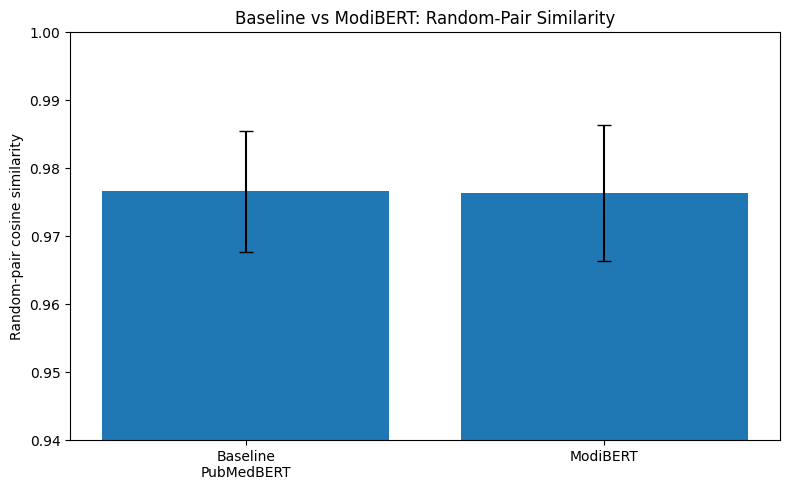

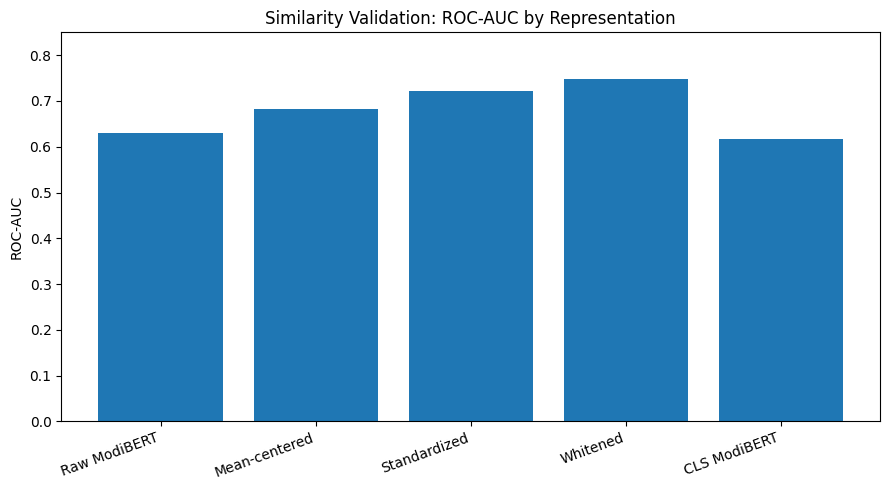

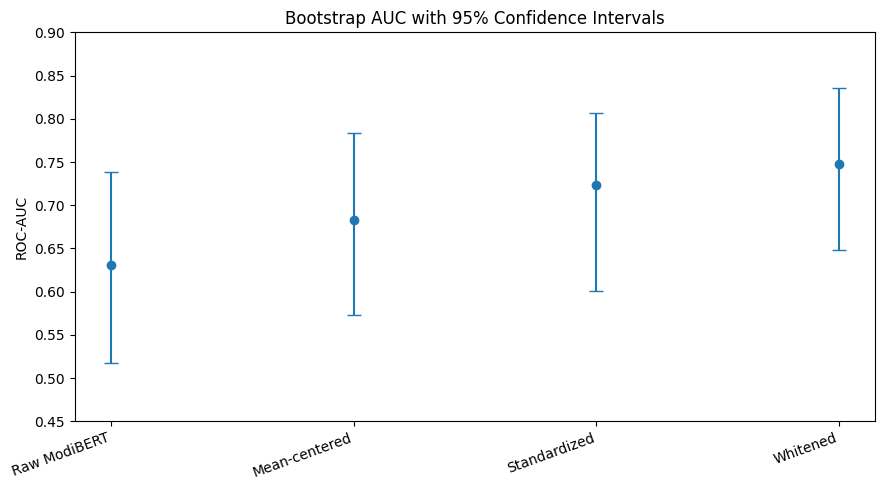

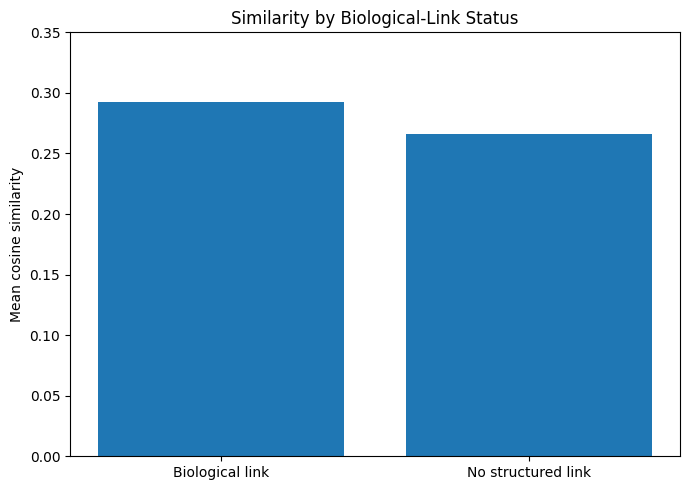

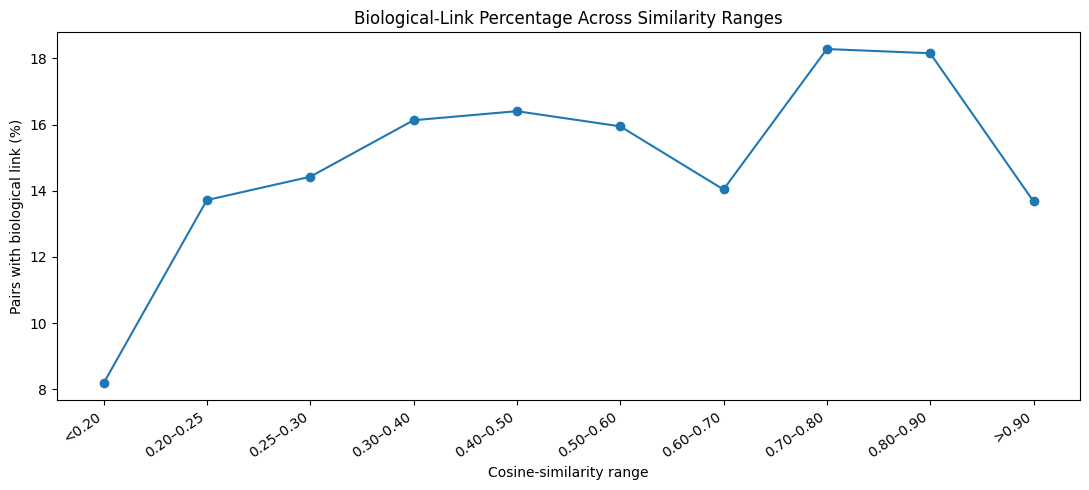

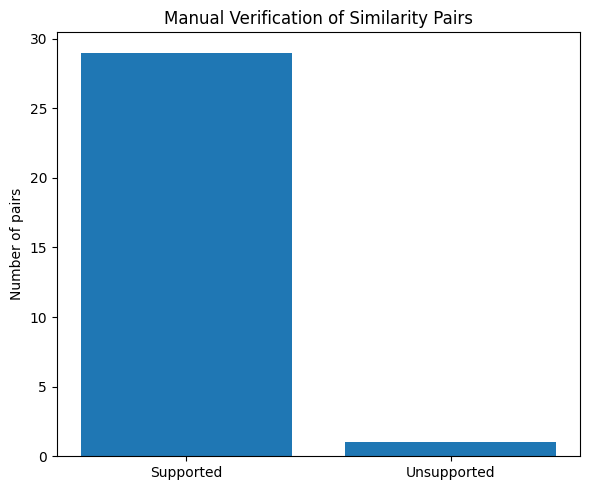

STEP 40 COMPLETE

Six report-ready figures have been generated:

1. Baseline vs ModiBERT anisotropy
2. ROC-AUC comparison
3. Bootstrap AUC confidence intervals
4. Biological-link vs no-link similarity
5. Biological-link percentage by similarity range
6. Manual verification results



In [43]:
# ============================================================
# STEP 40 — FINAL REPORT FIGURES
# ============================================================
# No new experiment.
# All figures use results that have already been calculated.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# FIGURE 1 — Baseline vs ModiBERT Anisotropy
# ============================================================

fig = plt.figure(figsize=(8, 5))

models = [
    "Baseline\nPubMedBERT",
    "ModiBERT"
]

means = [
    0.9766,
    0.9763
]

stds = [
    0.0089,
    0.0100
]

plt.bar(
    models,
    means,
    yerr=stds,
    capsize=5
)

plt.ylabel("Random-pair cosine similarity")
plt.title("Baseline vs ModiBERT: Random-Pair Similarity")
plt.ylim(0.94, 1.00)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2 — AUC Comparison Across Representations
# ============================================================

fig = plt.figure(figsize=(9, 5))

representations = [
    "Raw ModiBERT",
    "Mean-centered",
    "Standardized",
    "Whitened",
    "CLS ModiBERT"
]

auc_values = [
    0.6304,
    0.6820,
    0.7224,
    0.7472,
    0.6160
]

plt.bar(
    representations,
    auc_values
)

plt.ylabel("ROC-AUC")
plt.title("Similarity Validation: ROC-AUC by Representation")
plt.ylim(0.0, 0.85)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 3 — Bootstrap AUC with 95% Confidence Intervals
# ============================================================

fig = plt.figure(figsize=(9, 5))

bootstrap_representations = [
    "Raw ModiBERT",
    "Mean-centered",
    "Standardized",
    "Whitened"
]

bootstrap_means = np.array([
    0.630522,
    0.683083,
    0.723000,
    0.748043
])

lower = np.array([
    0.51760,
    0.57360,
    0.60100,
    0.64879
])

upper = np.array([
    0.73881,
    0.78401,
    0.80700,
    0.83600
])

yerr = np.vstack([
    bootstrap_means - lower,
    upper - bootstrap_means
])

x = np.arange(
    len(bootstrap_representations)
)

plt.errorbar(
    x,
    bootstrap_means,
    yerr=yerr,
    fmt="o",
    capsize=5
)

plt.xticks(
    x,
    bootstrap_representations,
    rotation=20,
    ha="right"
)

plt.ylabel("ROC-AUC")
plt.title("Bootstrap AUC with 95% Confidence Intervals")
plt.ylim(0.45, 0.90)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 4 — Biological Link vs No-Link Similarity
# ============================================================

fig = plt.figure(figsize=(7, 5))

groups = [
    "Biological link",
    "No structured link"
]

similarity_means = [
    0.292394,
    0.265668
]

plt.bar(
    groups,
    similarity_means
)

plt.ylabel("Mean cosine similarity")
plt.title("Similarity by Biological-Link Status")
plt.ylim(0.0, 0.35)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 5 — Biological-Link Percentage by Similarity Range
# ============================================================

similarity_ranges = [
    "<0.20",
    "0.20–0.25",
    "0.25–0.30",
    "0.30–0.40",
    "0.40–0.50",
    "0.50–0.60",
    "0.60–0.70",
    "0.70–0.80",
    "0.80–0.90",
    ">0.90"
]

biological_percentages = [
    8.180170,
    13.718268,
    14.423231,
    16.130901,
    16.404555,
    15.947181,
    14.037855,
    18.282548,
    18.155620,
    13.679245
]

fig = plt.figure(figsize=(11, 5))

plt.plot(
    similarity_ranges,
    biological_percentages,
    marker="o"
)

plt.xlabel("Cosine-similarity range")
plt.ylabel("Pairs with biological link (%)")
plt.title("Biological-Link Percentage Across Similarity Ranges")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 6 — Manual Verification
# ============================================================

fig = plt.figure(figsize=(6, 5))

verification_groups = [
    "Supported",
    "Unsupported"
]

verification_values = [
    29,
    1
]

plt.bar(
    verification_groups,
    verification_values
)

plt.ylabel("Number of pairs")
plt.title("Manual Verification of Similarity Pairs")

plt.tight_layout()
plt.show()


print("=" * 80)
print("STEP 40 COMPLETE")
print("=" * 80)

print("""
Six report-ready figures have been generated:

1. Baseline vs ModiBERT anisotropy
2. ROC-AUC comparison
3. Bootstrap AUC confidence intervals
4. Biological-link vs no-link similarity
5. Biological-link percentage by similarity range
6. Manual verification results
""")

In [45]:
# ============================================================
# STEP 41 — FINAL CONSOLIDATED RESULTS
# ============================================================
# No new experiment.
# Consolidates results already obtained.
# ============================================================

import pandas as pd

rows = [

    # --------------------------------------------------------
    # Representation
    # --------------------------------------------------------
    ("Representation", "Raw ModiBERT AUC", 0.6304),
    ("Representation", "Mean-centered AUC", 0.6820),
    ("Representation", "Standardized AUC", 0.7224),
    ("Representation", "Whitened AUC", 0.7472),
    ("Representation", "CLS ModiBERT AUC", 0.6160),

    # --------------------------------------------------------
    # Similarity Graph
    # --------------------------------------------------------
    ("Similarity Graph", "Original graph edges", 85476),
    ("Similarity Graph", "Edges after self-pair removal", 85392),
    ("Similarity Graph", "Top-K graph edges", 77035),
    ("Similarity Graph", "Drugs with neighbors", 12134),
    ("Similarity Graph", "Identical-text pairs removed", 1436),
    ("Similarity Graph", "Final clean graph edges", 75599),

    # --------------------------------------------------------
    # Biological Validation
    # --------------------------------------------------------
    ("Biological Validation", "Pairs analyzed", 75599),
    ("Biological Validation", "Pairs with biological link", 9560),
    ("Biological Validation", "Pairs without biological link", 66039),
    ("Biological Validation", "Biological-link percentage", 12.65),
    ("Biological Validation", "Biological-link mean similarity", 0.292394),
    ("Biological Validation", "No-link mean similarity", 0.265668),
    ("Biological Validation", "Mean difference", 0.026726),
    ("Biological Validation", "Mann-Whitney p-value", 6.253226819121403e-168),
    ("Biological Validation", "ROC-AUC", 0.5871733268302659),

    # --------------------------------------------------------
    # Manual Verification
    # --------------------------------------------------------
    ("Manual Verification", "Pairs manually verified", 30),
    ("Manual Verification", "Supported pairs", 29),
    ("Manual Verification", "Unsupported pairs", 1),
    ("Manual Verification", "Manual support percentage", 96.67)
]

final_results = pd.DataFrame(
    rows,
    columns=["Category", "Metric", "Value"]
)

print("=" * 90)
print("STEP 41 — FINAL CONSOLIDATED RESULTS")
print("=" * 90)

display(final_results)

STEP 41 — FINAL CONSOLIDATED RESULTS


,Category,Metric,Value
0,Representation,Raw ModiBERT AUC,6.304000e-01
1,Representation,Mean-centered AUC,6.820000e-01
2,Representation,Standardized AUC,7.224000e-01
3,Representation,Whitened AUC,7.472000e-01
4,Representation,CLS ModiBERT AUC,6.160000e-01
5,Similarity Graph,Original graph edges,8.547600e+04
6,Similarity Graph,Edges after self-pair removal,8.539200e+04
7,Similarity Graph,Top-K graph edges,7.703500e+04
8,Similarity Graph,Drugs with neighbors,1.213400e+04
9,Similarity Graph,Identical-text pairs removed,1.436000e+03


In [46]:
# ============================================================
# STEP 42 — FINAL PIPELINE & REPORT CHECKLIST
# ============================================================
# No new experiment.
# Documents the completed pipeline and final report components.
# ============================================================

final_pipeline_checklist = pd.DataFrame({

    "Stage": [
        "1. DrugBank text preparation",
        "2. PubMedBERT baseline embeddings",
        "3. ModiBERT MLM fine-tuning",
        "4. ModiBERT mean-pooled embeddings",
        "5. Baseline vs ModiBERT anisotropy diagnostic",
        "6. Embedding correction experiments",
        "7. CLS pooling comparison",
        "8. Target-grounded representation validation",
        "9. Bootstrap robustness analysis",
        "10. Similarity graph construction",
        "11. Identical-text pair filtering",
        "12. Similarity group discovery",
        "13. Biological investigation",
        "14. Statistical biological validation",
        "15. Manual verification",
        "16. Final figures and tables",
        "17. Experimental decision log"
    ],

    "Status": [
        "COMPLETED",
        "COMPLETED",
        "COMPLETED",
        "COMPLETED",
        "COMPLETED",
        "COMPLETED — exploratory",
        "COMPLETED",
        "COMPLETED",
        "COMPLETED",
        "COMPLETED",
        "COMPLETED",
        "COMPLETED",
        "COMPLETED",
        "COMPLETED",
        "COMPLETED",
        "COMPLETED",
        "COMPLETED"
    ],

    "Final_Report_Content": [
        "Dataset and text preprocessing",
        "Baseline representation",
        "MLM fine-tuning procedure",
        "Primary sentence representation",
        "Anisotropy finding",
        "Centering, standardization, whitening",
        "CLS vs mean pooling",
        "AUC and statistical comparison",
        "Bootstrap confidence intervals",
        "Top-K cosine-similarity graph",
        "Removal of identical-text pairs",
        "Connected components / similar groups",
        "Targets, enzymes, pathways, indications, mechanisms",
        "Mann-Whitney U and ROC-AUC",
        "29/30 manually supported pairs",
        "Figures and numerical tables",
        "Professor-unspecified decisions"
    ]
})

print("=" * 100)
print("STEP 42 — FINAL PIPELINE & REPORT CHECKLIST")
print("=" * 100)

display(final_pipeline_checklist)

print("\n" + "=" * 100)
print("FINAL STATUS")
print("=" * 100)

print("""
All computational stages required by the current project pipeline
have been completed and documented.

Remaining work:
1. Write the Methodology section.
2. Write the Results section.
3. Write the Discussion / Interpretation.
4. Write the Limitations and unresolved representation decision.
5. Write the Conclusion.
""")

STEP 42 — FINAL PIPELINE & REPORT CHECKLIST


,Stage,Status,Final_Report_Content
0,1. DrugBank text preparation,COMPLETED,Dataset and text preprocessing
1,2. PubMedBERT baseline embeddings,COMPLETED,Baseline representation
2,3. ModiBERT MLM fine-tuning,COMPLETED,MLM fine-tuning procedure
3,4. ModiBERT mean-pooled embeddings,COMPLETED,Primary sentence representation
4,5. Baseline vs ModiBERT anisotropy diagnostic,COMPLETED,Anisotropy finding
5,6. Embedding correction experiments,COMPLETED — exploratory,"Centering, standardization, whitening"
6,7. CLS pooling comparison,COMPLETED,CLS vs mean pooling
7,8. Target-grounded representation validation,COMPLETED,AUC and statistical comparison
8,9. Bootstrap robustness analysis,COMPLETED,Bootstrap confidence intervals
9,10. Similarity graph construction,COMPLETED,Top-K cosine-similarity graph



FINAL STATUS

All computational stages required by the current project pipeline
have been completed and documented.

Remaining work:
1. Write the Methodology section.
2. Write the Results section.
3. Write the Discussion / Interpretation.
4. Write the Limitations and unresolved representation decision.
5. Write the Conclusion.

